# Lee, Ud Din, Brennecka & Gorai (2024) — point defects and oxygen in wurtzite Al(1-x)Sc(x)N

Cheng-Wei Lee, Naseem Ud Din, Geoff L. Brennecka and Prashun Gorai,
*Defects and oxygen impurities in ferroelectric wurtzite Al(1-x)Sc(x)N alloys*,
**Appl. Phys. Lett. 125, 022901 (2024)**, [10.1063/5.0211892](https://doi.org/10.1063/5.0211892).
Preprint: [arXiv:2308.14310](https://arxiv.org/abs/2308.14310) — note the preprint lists
**Ud Din** first; the published paper lists **Lee** first, which is the form cited here.

N. Ud Din, C.-W. Lee, G. L. Brennecka, P. Gorai,
*"Defects and oxygen impurities in ferroelectric wurtzite Al(1-x)Sc(x)N alloys,"*
**Appl. Phys. Lett. 124, 162901 (2024)**,
doi:[10.1063/5.0202097](https://doi.org/10.1063/5.0202097); preprint arXiv:2308.14310.

Companion to `Hirata2020_AlScN_CALPHAD_v2.ipynb`. **Runs on the Python standard library alone.**
`matplotlib` is optional and only used for the plots at the end.

---

## Why this notebook exists

The paper's Figures 1 and S4-S6 plot only the **lower envelope** of the defect formation energies,
i.e. the most stable charge state at each Fermi energy. At a finite temperature every charge state
is populated with its own Boltzmann weight, including where it is not the ground state, so a
concentration model needs *all* the lines, not the envelope. Because
`dE(D,q; E_F) = dE(D,q; E_F=0) + q * E_F`, each straight envelope segment carries its charge state
in its **slope** and the energy we actually need in its **intercept**. Section 9 turns the envelope
back into the full line set; everything downstream uses it.

## What this notebook establishes

| | |
|---|---|
| **Recovered from the figures** | `dE(D,q; E_F=0)` for `V_Al`, `V_Sc`, `V_N`, `O_N` at x = 0.042, 0.125, 0.250, 0.333, under N-rich and most-N-poor chemical potentials, with and without oxygen — 16 panels, 244 charge-state lines |
| **Reproduced exactly** | Figure 2(a): the `V_N` concentration over the whole 500-1000 K range, all four compositions, both growth conditions, to **+0.004 to +0.019 decades** (a 1-4 % error in concentration) with no adjustable parameter |
| **Reproduced exactly** | Figure 2(c) under N-rich conditions, to **0.012-0.121 decades**, using charge neutrality alone and no density-of-states assumption |
| **Not reproducible** | Figure 2(b): the plotted `O_N` concentration is **24.2 +- 1.4 times lower** than the paper's own Eq. (3) applied to the `O_N` energies of its own Figures 1(c,d)/S4-S6(c,d) — a composition- and chemical-potential-independent factor equal, within our uncertainty, to the 24 N sites of the 48-atom SQS cell (section 14) |
| **Not reproducible** | The equilibrium Fermi energy under N-rich, oxygen-free conditions, where it is set by the ab-initio density of states rather than by defects; a parabolic-band model misses it by up to 0.24 eV (section 12) |

## Two headline numbers

1. **The extraction is exact, not approximate.** The figures are vector art, so the envelope segments
   are literal line segments. Fitting a slope to each gives an integer charge state with a residual of
   at most **5.6e-4** across all 244 segments; the reconstructed envelope reproduces the drawn one to
   **0.031 eV** worst case, and the charge-transition levels implied by the fitted intercepts agree
   with the *independently drawn* Figure 3 bars to **0.020 eV** worst case.
2. **Site multiplicity, not chemistry, is what the `O_N` mismatch looks like.** Using
   `N_sites(V_Sc) = x * N_cation` and `N_sites(V_Al) = (1-x) * N_cation` rather than the full cation
   density is what turns a 1.39-decade error in the x = 0.042 net carrier concentration into a
   0.012-decade agreement — and the residual `O_N` factor of 24.6 is the same kind of quantity.


## 1. Reading guide - what is load-bearing and what is only a check

Every section below is tagged in its heading, and every data cell opens with the same tag.

| tag | meaning |
|---|---|
| **MODEL INPUT** | a downstream model consumes this. Deleting it breaks something. |
| **LITERATURE** | external values used to justify an assumption. |
| **ASSUMPTION** | chosen by us, not read from the paper. |
| **CHECK ONLY** | digitized purely to test that the extraction reproduces the published figures. **Nothing computed depends on it**; delete it all and every number above is unchanged. |
| **CODE** / **NARRATIVE** / **PRESENTATION** | machinery, prose, plots. |

The whole model-input surface is five items:

| what | section | note |
|---|---|---|
| `FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM` | 6 | 244 charge-state intercepts. The core data. |
| `BAND_GAP` | 5 | GW-shifted gaps, from the panel widths. |
| `HIRATA_LATTICE_PARAMETER_A` / `_C` | 10 | only as a cell volume; 12.6 % across the range = 0.010 eV. |
| `CATION_SITES_PER_SUPERCELL`, `SCANDIUM_ATOMS_PER_SUPERCELL` | 2 | site counting; the composition weighting is worth 1.39 decades at x = 0.042. |
| `EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN` | 6a | the paper's own E_F,eq markers - an anchor, and the only handle on their unpublished density of states. |

Everything else in sections 5-13 is a consistency check. Section 14a re-states this split
programmatically and fails if a new object is added without being classified.


## 2. Conventions  ·  CONSTANTS

- **Composition** is the cation fraction x in Al(1-x)Sc(x)N. The paper's four compositions correspond
  to 1, 3, 6 and 8 Sc atoms on the 24 cation sites of a 48-atom special quasirandom structure, i.e.
  x = 1/24, 3/24, 6/24, 8/24 = 0.0417, 0.125, 0.250, 0.333.
- **Fermi energy** `E_F` is referenced to the valence band maximum, so 0 <= E_F <= E_gap.
- **Formation energy** `dE(D,q; E_F)` is the paper's *effective* formation energy: the Zhang average
  (SI Eq. 1) over the minimum-energy and maximum-energy Wyckoff sites of the alloy. Everything below
  inherits that definition; we never re-derive it.
- `dE(D,q; E_F) = dE(D,q; E_F=0) + q * E_F` exactly, so a single number per charge state
  (`energy at the valence band maximum`) defines the whole line.
- **Concentration** follows the paper's SI Eq. (3), `C_D = N_sites * exp(-dE_eff / kT)`, with
  **no degeneracy factor** — the paper does not use one, so neither do we.
- **Chemical-potential conditions** are the vertices of the paper's own stability regions: "N-rich"
  is V4 (Delta-mu_N = 0) and "most N-poor" is V1 (Delta-mu_N = -3.174 eV at x = 0.333) of Table S5
  for the oxygen-free panels, and of Table S9 for the oxygen-containing panels.
- All energies are in eV, all concentrations in cm^-3, all temperatures in K.


In [1]:
# ===== CONSTANTS =====
import math

BOLTZMANN_CONSTANT_ELECTRONVOLT_PER_KELVIN = 8.617333262e-5
REFERENCE_TEMPERATURE_KELVIN = 1000.0          # the paper solves charge neutrality at 1000 K
CATION_SITES_PER_SUPERCELL = 24                # 48-atom SQS: 24 cations + 24 anions
SCANDIUM_ATOMS_PER_SUPERCELL = {0.042: 1, 0.125: 3, 0.25: 6, 0.333: 8}

COMPOSITIONS = [0.042, 0.125, 0.25, 0.333]
CONDITIONS = ["N-rich, oxygen absent", "most N-poor, oxygen absent",
              "N-rich, oxygen present", "most N-poor, oxygen present"]
DEFECTS = ["V_Al", "V_Sc", "V_N", "O_N"]

print("compositions:", COMPOSITIONS)
print("nominal x from the supercell:",
      [round(SCANDIUM_ATOMS_PER_SUPERCELL[c] / CATION_SITES_PER_SUPERCELL, 4)
       for c in COMPOSITIONS])


compositions: [0.042, 0.125, 0.25, 0.333]
nominal x from the supercell: [0.0417, 0.125, 0.25, 0.3333]


## 3. Cross-check harness  ·  CODE

Every quantity that is **both** recovered from one figure **and** independently stated in another
figure, a supplementary table, or the running text is recomputed and asserted. Checks that are
**expected to fail** carry `expect_failure=True`: they are the reproducibility gaps of section 14,
and a clean run still ends in `ALL AS EXPECTED`.


In [2]:
CHECK_RESULTS = []


def check_value(computed, expected, tolerance_relative, label,
                expect_failure=False, note=""):
    """Assert computed ~= expected to a relative tolerance; record PASS/FAIL."""
    if expected == 0:
        relative_error = abs(computed)
    else:
        relative_error = abs(computed - expected) / abs(expected)
    passed = relative_error <= tolerance_relative
    as_expected = (passed != expect_failure)
    CHECK_RESULTS.append({"label": label, "computed": computed, "expected": expected,
                          "relative_error": relative_error, "passed": passed,
                          "expect_failure": expect_failure, "as_expected": as_expected,
                          "note": note})
    tag = "PASS" if passed else "FAIL"
    if expect_failure:
        tag += " (expected FAIL)" if not passed else " (UNEXPECTED PASS)"
    print(f"[{tag:22s}] {label}\n"
          f"{'':24s} computed={computed:.6g}  expected={expected:.6g}  rel.err={relative_error:.3g}"
          + (f"\n{'':24s} {note}" if note else ""))
    return passed


def check_zero(computed, absolute_tolerance, label, expect_failure=False, note=""):
    """Assert |computed| <= tolerance; record PASS/FAIL."""
    passed = abs(computed) <= absolute_tolerance
    as_expected = (passed != expect_failure)
    CHECK_RESULTS.append({"label": label, "computed": computed, "expected": 0.0,
                          "relative_error": abs(computed), "passed": passed,
                          "expect_failure": expect_failure, "as_expected": as_expected,
                          "note": note})
    tag = "PASS" if passed else "FAIL"
    if expect_failure:
        tag += " (expected FAIL)" if not passed else " (UNEXPECTED PASS)"
    print(f"[{tag:22s}] {label}\n"
          f"{'':24s} computed={computed:.6g}  |tol|={absolute_tolerance:.3g}"
          + (f"\n{'':24s} {note}" if note else ""))
    return passed


def summarise_checks():
    total = len(CHECK_RESULTS)
    as_expected = sum(1 for result in CHECK_RESULTS if result["as_expected"])
    print(f"\n{'='*78}\n{as_expected}/{total} checks behaved as expected.")
    unexpected = [result for result in CHECK_RESULTS if not result["as_expected"]]
    if unexpected:
        print("UNEXPECTED:")
        for result in unexpected:
            print(f"  - {result['label']}  (deviation {result['relative_error']:.3g})")
    else:
        deliberate = sum(1 for result in CHECK_RESULTS if result["expect_failure"])
        print(f"ALL AS EXPECTED (including the {deliberate} deliberate failures of section 14).")


### 3a. Interpolation machinery  ·  CODE

Monotone cubic Hermite in composition. It was written for section 14b but section 8b needs it too, so it lives here, ahead of first use.

In [3]:
# ===== CODE =====
def secant_slopes(grid, values):
    """Slope of the straight line across each interval."""
    return [(values[i + 1] - values[i]) / (grid[i + 1] - grid[i])
            for i in range(len(grid) - 1)]


def hermite_slopes(grid, values):
    """
    Fritsch-Carlson slopes: zero at a local extremum, weighted harmonic mean otherwise, so the
    interpolant cannot overshoot the data. The end slopes are the adjacent secants, which makes
    the linear extrapolation a straight continuation of the last interval.
    """
    deltas = secant_slopes(grid, values)
    if len(deltas) == 1:
        return [deltas[0], deltas[0]]
    slopes = [deltas[0]]
    for i in range(1, len(grid) - 1):
        if deltas[i - 1] * deltas[i] <= 0:
            slopes.append(0.0)
            continue
        left, right = grid[i] - grid[i - 1], grid[i + 1] - grid[i]
        weight_left, weight_right = 2 * right + left, right + 2 * left
        slopes.append((weight_left + weight_right)
                      / (weight_left / deltas[i - 1] + weight_right / deltas[i]))
    slopes.append(deltas[-1])
    return slopes


def hermite_value(left, right, value_left, value_right, slope_left, slope_right, position):
    """Cubic Hermite basis on a single interval."""
    span = right - left
    t = (position - left) / span
    return ((2 * t ** 3 - 3 * t ** 2 + 1) * value_left
            + (t ** 3 - 2 * t ** 2 + t) * span * slope_left
            + (-2 * t ** 3 + 3 * t ** 2) * value_right
            + (t ** 3 - t ** 2) * span * slope_right)


class CompositionInterpolant:
    """Hermite interpolation in x inside the data, straight-line continuation outside."""

    def __init__(self, grid, values, constant_tails=False):
        self.constant_tails = constant_tails
        pairs = sorted(zip(grid, values))
        self.grid = [point for point, _ in pairs]
        self.values = [value for _, value in pairs]
        self.slopes = hermite_slopes(self.grid, self.values)

    def __call__(self, composition):
        tail = 0.0 if self.constant_tails else 1.0
        if composition <= self.grid[0]:
            return self.values[0] + tail * self.slopes[0] * (composition - self.grid[0])
        if composition >= self.grid[-1]:
            return self.values[-1] + tail * self.slopes[-1] * (composition - self.grid[-1])
        index = max(i for i in range(len(self.grid) - 1) if self.grid[i] <= composition)
        return hermite_value(self.grid[index], self.grid[index + 1], self.values[index],
                             self.values[index + 1], self.slopes[index],
                             self.slopes[index + 1], composition)


## 4. How the figure data was recovered  ·  NARRATIVE

The published figures are **vector** PDF content, not raster images, so nothing here is digitized in
the usual sense. Each defect curve is drawn as a set of two-point straight segments; each panel's
axes are drawn as a three-point spine polyline plus short tick segments. Reading the content stream
therefore recovers the *exact* device coordinates of every vertex and every tick.

| figure | PDF | Form XObject | what it holds |
|---|---|---|---|
| Fig. 1 | main | 113 (`alscn-defects.pdf`) | dE vs E_F at x = 0.333, 4 panels |
| Fig. 2 | main | 140 (`concentrations.pdf`) | V_N, O_N and net carrier concentrations vs T |
| Fig. 3 | main | 141 (`ctl.pdf`) | charge transition levels and band gaps |
| Fig. S4 | supplementary | 254 (`defects-x042.pdf`) | dE vs E_F at x = 0.042 |
| Fig. S5 | supplementary | 262 (`defects-x125.pdf`) | dE vs E_F at x = 0.125 |
| Fig. S6 | supplementary | 270 (`defects-x250.pdf`) | dE vs E_F at x = 0.250 |

**Calibration.** Each panel is calibrated on its own tick marks: the x ticks are 0-5 eV, the y ticks
are 0, 2, 4, 6, 8 eV. Tick spacings are uniform to better than 0.005 pt within every panel, and
E_F = 0 coincides with the panel's left spine to within 0.05 pt in 15 of the 16 panels. The single
exception is Fig. S6(b), whose six x tick marks are emitted 1.43 pt to the right of the spine and
0.97 % too closely spaced; its x scale was recovered instead from the requirement that the segment
slopes be integers, which then reproduces the same 5.188 eV axis span as its three sibling panels and
the same charge-transition levels as Fig. S6(d). That is recorded here rather than hidden.

**Colour to defect.** The assignment was not inferred from curve positions: the in-plot text labels
`V`+`Al`, `V`+`Sc`, `V`+`N`, `O`+`N` are themselves drawn in the *same* fill colour as their curves,
so the mapping blue -> V_Al, purple -> V_Sc, green -> V_N, red -> O_N is read directly off the glyph
colours. Colours repeat with small rounding differences (0.596 vs 0.592) and were clustered with a
tolerance of 0.03.

**What could not be recovered.** A charge state that never reaches the lower envelope leaves no
segment. The SI states that V_Al and V_Sc were computed in q = -3, -2, -1, 0, +1 and V_N in
q = -1, 0, +1, +2, +3; at x = 0.333 the V_Al q = -1 line is absent from the envelope (a negative-U
0/-2 transition), so only a **lower bound** on its energy is available — section 9 computes it.
Likewise the V_N q = +3 and O_N q = -1 lines are absent wherever their transition would fall outside
the plotted gap.


## 5. Band gaps  ·  MODEL INPUT

The x axis of every dE-vs-E_F panel runs from the valence band maximum to the conduction band
minimum, so **the width of the panel is the band gap**. Figure 3 states the same gaps as text labels
and draws them as the separation of its VBM and CBM bars. Three independent readings.


In [4]:
# ===== MODEL INPUT =====
# --- band gap, three independent readings -----------------------------------
BAND_GAP_FROM_PANEL_WIDTH = {
    0.042: 5.9239,   # +-0.0001 as read from Figs. S4(a-d); spread over the four panels 0.0001
    0.125: 5.6559,   # +-0.0001 as read from Figs. S5(a-d); spread over the four panels 0.0001
    0.25: 5.1880,    # +-0.0002 as read from Figs. S6(a-d); spread over the four panels 0.0002
    0.333: 5.0400,   # +-0.0001 as read from Figs. 1(a-d);  spread over the four panels 0.0000
}

BAND_GAP = dict(BAND_GAP_FROM_PANEL_WIDTH)


### 5a. Two further readings of the same gap

Independent reads used only to bound the first one.


In [5]:
# ===== CHECK ONLY =====
BAND_GAP_FROM_FIGURE_3_BARS = {
    0.042: 5.9240,   # +-0.0005 as read from Fig. 3, CBM bar minus VBM bar
    0.125: 5.6560,   # +-0.0005 as read from Fig. 3
    0.25: 5.1880,    # +-0.0005 as read from Fig. 3
    0.333: 5.0400,   # +-0.0005 as read from Fig. 3
}
BAND_GAP_PRINTED_IN_FIGURE_3 = {0.042: 5.92, 0.125: 5.66, 0.25: 5.19, 0.333: 5.04}
BAND_GAP_ALUMINIUM_NITRIDE_GW = 6.11   # stated in the main text

print(f"{'x':>6} {'panel width':>12} {'Fig. 3 bars':>12} {'Fig. 3 text':>12} {'max spread':>11}")
for composition in COMPOSITIONS:
    readings = [BAND_GAP_FROM_PANEL_WIDTH[composition],
                BAND_GAP_FROM_FIGURE_3_BARS[composition],
                BAND_GAP_PRINTED_IN_FIGURE_3[composition]]
    print(f"{composition:6.3f} {readings[0]:12.4f} {readings[1]:12.4f} {readings[2]:12.2f} "
          f"{max(readings) - min(readings):11.4f}")



     x  panel width  Fig. 3 bars  Fig. 3 text  max spread
 0.042       5.9239       5.9240         5.92      0.0040
 0.125       5.6559       5.6560         5.66      0.0041
 0.250       5.1880       5.1880         5.19      0.0020
 0.333       5.0400       5.0400         5.04      0.0000


## 6. Defect formation energies at the valence band maximum  ·  MODEL INPUT

`dE(D,q; E_F=0)` in eV, i.e. the **intercept** of each charge state's line. The lines themselves are
`dE(D,q; E_F=0) + q * E_F` for `0 <= E_F <= E_gap` — that is the whole point of section 9.

Uncertainty on every entry is **+-0.02 eV**, set not by the calibration (which is exact to ~0.0002 eV)
but by the figures' own vertex rendering: neighbouring segments of the same polyline are drawn with
end points that disagree by up to 0.6 pt, so an intercept averaged over one segment's two ends
inherits about 0.012-0.020 eV of that. Section 8 measures it.


In [6]:
# ===== MODEL INPUT =====
# ---------------------------------------------------------------------------
# dE(D, q; E_F = 0) in eV, +-0.02 eV, read from the lower-envelope segments of
# Fig. 1 (x = 0.333) and Figs. S4/S5/S6 (x = 0.042 / 0.125 / 0.250).
# Keys are (composition, chemical-potential condition); the inner keys are charge states.
# ---------------------------------------------------------------------------
FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM = {
    (0.042, "N-rich, oxygen absent"): {
        "V_Al": {+1: 5.894, +0: 6.513, -1: 8.362, -2: 10.525, -3: 13.098},
        "V_Sc": {+1: 3.315, +0: 4.321, -1: 6.332, -2: 8.692, -3: 11.622},
        "V_N": {+3: -1.343, +2: -0.248, +1: 1.181, +0: 4.927, -1: 9.280},
    },  # Fig. S4(a)
    (0.042, "most N-poor, oxygen absent"): {
        "V_Al": {+1: 9.065, +0: 9.685, -1: 11.533, -2: 13.697, -3: 16.269},
        "V_Sc": {+1: 7.355, +0: 8.361, -1: 10.372, -2: 12.732, -3: 15.662},
        "V_N": {+1: -2.027, +0: 1.719, -1: 6.073},
    },  # Fig. S4(b)
    (0.042, "N-rich, oxygen present"): {
        "V_Al": {+1: 5.858, +0: 6.478, -1: 8.326, -2: 10.489, -3: 13.062},
        "V_Sc": {+1: 4.147, +0: 5.153, -1: 7.164, -2: 9.524, -3: 12.454},
        "V_N": {+3: -1.346, +2: -0.251, +1: 1.178, +0: 4.924, -1: 9.277},
        "O_N": {+1: -2.023, +0: 3.705},
    },  # Fig. S4(c)
    (0.042, "most N-poor, oxygen present"): {
        "V_Al": {+1: 9.065, +0: 9.685, -1: 11.533, -2: 13.697, -3: 16.270},
        "V_Sc": {+1: 6.873, +0: 7.880, -1: 9.891, -2: 12.251, -3: 15.181},
        "V_N": {+1: -2.042, +0: 1.704, -1: 6.057},
        "O_N": {+1: -3.377, +0: 2.351},
    },  # Fig. S4(d)
    (0.125, "N-rich, oxygen absent"): {
        "V_Al": {+1: 5.223, +0: 6.183, -1: 7.837, -2: 10.032, -3: 12.591},
        "V_Sc": {+1: 3.929, +0: 4.866, -1: 6.734, -2: 9.056, -3: 11.989},
        "V_N": {+3: -1.556, +2: -0.623, +1: 0.910, +0: 4.312, -1: 8.320},
    },  # Fig. S5(a)
    (0.125, "most N-poor, oxygen absent"): {
        "V_Al": {+1: 8.394, +0: 9.354, -1: 11.009, -2: 13.204, -3: 15.763},
        "V_Sc": {+1: 7.503, +0: 8.440, -1: 10.308, -2: 12.630, -3: 15.563},
        "V_N": {+1: -2.312, +0: 1.091, -1: 5.098},
    },  # Fig. S5(b)
    (0.125, "N-rich, oxygen present"): {
        "V_Al": {+1: 5.172, +0: 6.133, -1: 7.787, -2: 9.982, -3: 12.541},
        "V_Sc": {+1: 4.281, +0: 5.218, -1: 7.086, -2: 9.408, -3: 12.341},
        "V_N": {+3: -1.559, +2: -0.626, +1: 0.907, +0: 4.309, -1: 8.317},
        "O_N": {+1: -2.234, +0: 2.003},
    },  # Fig. S5(c)
    (0.125, "most N-poor, oxygen present"): {
        "V_Al": {+1: 8.394, +0: 9.354, -1: 11.009, -2: 13.204, -3: 15.763},
        "V_Sc": {+1: 7.101, +0: 8.038, -1: 9.906, -2: 12.228, -3: 15.161},
        "V_N": {+1: -2.265, +0: 1.137, -1: 5.145},
        "O_N": {+1: -3.556, +0: 0.681},
    },  # Fig. S5(d)
    (0.25, "N-rich, oxygen absent"): {
        "V_Al": {+1: 5.489, +0: 6.299, -1: 7.724, -2: 9.496, -3: 11.568},
        "V_Sc": {+1: 4.182, +0: 4.982, -1: 6.429, -2: 8.206, -3: 10.386},
        "V_N": {+3: -2.127, +2: -0.637, +1: 1.256, +0: 4.316, -1: 8.092},
    },  # Fig. S6(a)
    (0.25, "most N-poor, oxygen absent"): {
        "V_Al": {+1: 8.661, +0: 9.471, -1: 10.896, -2: 12.668, -3: 14.739},
        "V_Sc": {+1: 7.471, +0: 8.271, -1: 9.718, -2: 11.495, -3: 13.675},
        "V_N": {+2: -3.838, +1: -1.945, +0: 1.115, -1: 4.891},
    },  # Fig. S6(b)
    (0.25, "N-rich, oxygen present"): {
        "V_Al": {+1: 5.460, +0: 6.271, -1: 7.695, -2: 9.467, -3: 11.539},
        "V_Sc": {+1: 4.270, +0: 5.070, -1: 6.517, -2: 8.294, -3: 10.474},
        "V_N": {+3: -2.130, +2: -0.641, +1: 1.252, +0: 4.313, -1: 8.089},
        "O_N": {+1: -1.960, +0: 1.641, -1: 5.889},
    },  # Fig. S6(c)
    (0.25, "most N-poor, oxygen present"): {
        "V_Al": {+1: 8.661, +0: 9.471, -1: 10.896, -2: 12.668, -3: 14.739},
        "V_Sc": {+1: 7.354, +0: 8.154, -1: 9.601, -2: 11.378, -3: 13.558},
        "V_N": {+2: -3.812, +1: -1.920, +0: 1.141, -1: 4.917},
        "O_N": {+1: -3.076, +0: 0.525, -1: 4.772},
    },  # Fig. S6(d)
    (0.333, "N-rich, oxygen absent"): {
        "V_Al": {+1: 5.614, +0: 5.977, -2: 8.675, -3: 10.563},
        "V_Sc": {+1: 4.892, +0: 5.731, -1: 7.387, -2: 9.122, -3: 11.182},
        "V_N": {+3: -2.207, +2: -0.619, +1: 1.190, +0: 4.430, -1: 8.160},
    },  # Fig. 1(a)
    (0.333, "most N-poor, oxygen absent"): {
        "V_Al": {+1: 8.786, +0: 9.149, -2: 11.846, -3: 13.762},
        "V_Sc": {+1: 8.069, +0: 8.909, -1: 10.565, -2: 12.299, -3: 14.359},
        "V_N": {+2: -3.794, +1: -1.983, +0: 1.257, -1: 4.986},
    },  # Fig. 1(b)
    (0.333, "N-rich, oxygen present"): {
        "V_Al": {+1: 5.617, +0: 5.980, -2: 8.677, -3: 10.565},
        "V_Sc": {+1: 4.895, +0: 5.734, -1: 7.389, -2: 9.125, -3: 11.184},
        "V_N": {+3: -2.208, +2: -0.621, +1: 1.189, +0: 4.429, -1: 8.159},
        "O_N": {+1: -1.991, +0: 1.817, -1: 5.954},
    },  # Fig. 1(c)
    (0.333, "most N-poor, oxygen present"): {
        "V_Al": {+1: 8.789, +0: 9.152, -2: 11.849, -3: 13.737},
        "V_Sc": {+1: 8.066, +0: 8.906, -1: 10.562, -2: 12.296, -3: 14.356},
        "V_N": {+2: -3.792, +1: -1.982, +0: 1.258, -1: 4.988},
        "O_N": {+1: -3.048, +0: 0.760, -1: 4.897},
    },  # Fig. 1(d)
}

segment_count = sum(len(states) for panel in FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM.values()
                    for states in panel.values())
print(f"{len(FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM)} panels, "
      f"{segment_count} charge-state lines recovered")


16 panels, 244 charge-state lines recovered


### 6a. Equilibrium Fermi levels drawn in the figures

The markers the paper draws at 1000 K. Used as an anchor, and as the only route to their unpublished density of states.


In [7]:
# ===== MODEL INPUT =====
# Equilibrium Fermi energy at 1000 K, read from the vertical marker drawn in each panel.
# +-0.002 eV (the marker is a single stroked line; the uncertainty is its calibration).
EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN = {
    (0.042, "N-rich, oxygen absent"): 2.8280,
    (0.042, "most N-poor, oxygen absent"): 4.0399,
    (0.042, "N-rich, oxygen present"): 3.6089,
    (0.042, "most N-poor, oxygen present"): 4.5629,
    (0.125, "N-rich, oxygen absent"): 2.6336,
    (0.125, "most N-poor, oxygen absent"): 3.7050,
    (0.125, "N-rich, oxygen present"): 3.5850,
    (0.125, "most N-poor, oxygen present"): 4.2150,
    (0.25, "N-rich, oxygen absent"): 2.5209,
    (0.25, "most N-poor, oxygen absent"): 3.4180,
    (0.25, "N-rich, oxygen present"): 3.0461,
    (0.25, "most N-poor, oxygen present"): 3.8789,
    (0.333, "N-rich, oxygen absent"): 2.4986,
    (0.333, "most N-poor, oxygen absent"): 3.4829,
    (0.333, "N-rich, oxygen present"): 3.0560,
    (0.333, "most N-poor, oxygen present"): 3.8770,
}


### 6b. Extraction residuals

Diagnostics for section 8. Nothing downstream reads these.


In [8]:
# ===== CHECK ONLY =====
# Fitted slope minus the nearest integer, one entry per line above, same ordering.
# A perfect extraction gives exactly zero; these are the actual residuals.
SLOPE_RESIDUALS = {
    (0.042, "N-rich, oxygen absent"): {"V_Al": [-0.00012, +0.00000, +0.00002, -0.00011, -0.00001], "V_Sc": [-0.00005, +0.00000, +0.00024, -0.00018, +0.00016], "V_N": [+0.00011, -0.00007, +0.00003, +0.00000, -0.00007]},
    (0.042, "most N-poor, oxygen absent"): {"V_Al": [+0.00005, +0.00000, +0.00027, -0.00007, +0.00000], "V_Sc": [+0.00008, +0.00000, -0.00022, +0.00016, +0.00000], "V_N": [-0.00000, +0.00000, -0.00004]},
    (0.042, "N-rich, oxygen present"): {"V_Al": [+0.00025, +0.00000, +0.00013, -0.00016, +0.00002], "V_Sc": [+0.00010, +0.00000, -0.00009, -0.00007, +0.00007], "V_N": [+0.00004, +0.00006, -0.00001, +0.00000, +0.00005], "O_N": [-0.00002, +0.00000]},
    (0.042, "most N-poor, oxygen present"): {"V_Al": [-0.00004, +0.00000, -0.00012, +0.00056, -0.00005], "V_Sc": [+0.00005, +0.00000, +0.00017, +0.00005, -0.00001], "V_N": [-0.00002, +0.00000, -0.00003], "O_N": [-0.00001, +0.00000]},
    (0.125, "N-rich, oxygen absent"): {"V_Al": [-0.00006, +0.00000, +0.00016, -0.00047, +0.00010], "V_Sc": [+0.00009, +0.00000, -0.00019, -0.00018, +0.00000], "V_N": [+0.00009, -0.00024, +0.00001, +0.00000, -0.00004]},
    (0.125, "most N-poor, oxygen absent"): {"V_Al": [-0.00009, +0.00000, +0.00004, -0.00009, -0.00001], "V_Sc": [+0.00003, +0.00000, +0.00009, -0.00005, +0.00002], "V_N": [+0.00001, +0.00000, -0.00001]},
    (0.125, "N-rich, oxygen present"): {"V_Al": [-0.00000, +0.00000, +0.00004, -0.00003, -0.00002], "V_Sc": [+0.00004, +0.00000, +0.00000, -0.00020, +0.00007], "V_N": [-0.00017, +0.00006, +0.00002, +0.00000, -0.00003], "O_N": [+0.00002, +0.00000]},
    (0.125, "most N-poor, oxygen present"): {"V_Al": [+0.00006, +0.00000, -0.00006, +0.00028, -0.00002], "V_Sc": [-0.00007, +0.00000, -0.00013, -0.00007, +0.00003], "V_N": [+0.00002, +0.00000, -0.00002], "O_N": [-0.00002, +0.00000]},
    (0.25, "N-rich, oxygen absent"): {"V_Al": [+0.00004, +0.00000, -0.00018, -0.00011, -0.00000], "V_Sc": [+0.00015, +0.00000, +0.00014, -0.00021, +0.00009], "V_N": [+0.00007, -0.00023, +0.00004, +0.00000, +0.00005]},
    (0.25, "most N-poor, oxygen absent"): {"V_Al": [-0.00011, +0.00000, +0.00016, -0.00006, +0.00000], "V_Sc": [+0.00001, +0.00000, -0.00009, +0.00016, -0.00004], "V_N": [-0.00051, +0.00006, +0.00000, -0.00005]},
    (0.25, "N-rich, oxygen present"): {"V_Al": [-0.00008, +0.00000, +0.00015, +0.00001, +0.00003], "V_Sc": [+0.00003, +0.00000, +0.00022, +0.00002, -0.00010], "V_N": [-0.00001, +0.00008, -0.00005, +0.00000, +0.00005], "O_N": [-0.00003, +0.00000, -0.00010]},
    (0.25, "most N-poor, oxygen present"): {"V_Al": [+0.00003, +0.00000, -0.00036, +0.00015, -0.00002], "V_Sc": [+0.00011, +0.00000, -0.00040, +0.00020, +0.00003], "V_N": [+0.00010, -0.00006, +0.00000, +0.00000], "O_N": [-0.00000, +0.00000, +0.00003]},
    (0.333, "N-rich, oxygen absent"): {"V_Al": [-0.00001, +0.00000, -0.00002, +0.00001], "V_Sc": [-0.00001, +0.00000, -0.00018, +0.00008, +0.00000], "V_N": [+0.00003, +0.00002, -0.00001, +0.00000, -0.00000]},
    (0.333, "most N-poor, oxygen absent"): {"V_Al": [-0.00002, +0.00000, -0.00001, +0.00000], "V_Sc": [+0.00004, +0.00000, -0.00018, +0.00009, -0.00001], "V_N": [-0.00020, -0.00001, +0.00000, +0.00000]},
    (0.333, "N-rich, oxygen present"): {"V_Al": [-0.00001, +0.00000, -0.00004, +0.00003], "V_Sc": [-0.00003, +0.00000, +0.00016, -0.00002, -0.00001], "V_N": [+0.00002, +0.00011, +0.00000, +0.00000, +0.00001], "O_N": [-0.00000, +0.00000, +0.00001]},
    (0.333, "most N-poor, oxygen present"): {"V_Al": [-0.00001, +0.00000, -0.00005, -0.00001], "V_Sc": [-0.00002, +0.00000, +0.00015, -0.00003, +0.00001], "V_N": [-0.00006, +0.00000, +0.00000, +0.00001], "O_N": [+0.00000, +0.00000, +0.00001]},
}

# Fermi energy of each kink in the DRAWN envelope, i.e. the midpoint of the two
# neighbouring segment end points, +-0.02 eV. Independent of the intercepts above:
# these come from vertex positions, those from slopes and offsets.
MEASURED_ENVELOPE_KINKS = {
    (0.042, "N-rich, oxygen absent"): {"V_Al": [0.620, 1.848, 2.164, 2.585], "V_Sc": [1.009, 2.010, 2.360, 2.930], "V_N": [1.096, 1.428, 3.747, 4.352]},
    (0.042, "most N-poor, oxygen absent"): {"V_Al": [0.620, 1.848, 2.164, 2.585], "V_Sc": [1.009, 2.010, 2.360, 2.930], "V_N": [3.747, 4.352]},
    (0.042, "N-rich, oxygen present"): {"V_Al": [0.620, 1.849, 2.163, 2.573], "V_Sc": [0.990, 2.011, 2.360, 2.930], "V_N": [1.095, 1.427, 3.746, 4.353], "O_N": [5.727]},
    (0.042, "most N-poor, oxygen present"): {"V_Al": [0.620, 1.849, 2.163, 2.573], "V_Sc": [0.990, 2.011, 2.360, 2.930], "V_N": [3.746, 4.353], "O_N": [5.727]},
    (0.125, "N-rich, oxygen absent"): {"V_Al": [0.960, 1.655, 2.195, 2.559], "V_Sc": [0.937, 1.868, 2.322, 2.933], "V_N": [0.933, 1.533, 3.403, 4.007]},
    (0.125, "most N-poor, oxygen absent"): {"V_Al": [0.960, 1.655, 2.195, 2.559], "V_Sc": [0.937, 1.868, 2.322, 2.933], "V_N": [3.403, 4.007]},
    (0.125, "N-rich, oxygen present"): {"V_Al": [0.961, 1.654, 2.195, 2.559], "V_Sc": [0.937, 1.868, 2.322, 2.933], "V_N": [0.933, 1.533, 3.402, 4.008], "O_N": [4.237]},
    (0.125, "most N-poor, oxygen present"): {"V_Al": [0.961, 1.654, 2.195, 2.559], "V_Sc": [0.937, 1.868, 2.322, 2.933], "V_N": [3.402, 4.008], "O_N": [4.237]},
    (0.25, "N-rich, oxygen absent"): {"V_Al": [0.810, 1.425, 1.772, 2.071], "V_Sc": [0.800, 1.447, 1.778, 2.180], "V_N": [1.490, 1.892, 3.061, 3.776]},
    (0.25, "most N-poor, oxygen absent"): {"V_Al": [0.810, 1.424, 1.772, 2.071], "V_Sc": [0.800, 1.446, 1.778, 2.180], "V_N": [1.892, 3.060, 3.776]},
    (0.25, "N-rich, oxygen present"): {"V_Al": [0.810, 1.424, 1.772, 2.071], "V_Sc": [0.800, 1.446, 1.778, 2.180], "V_N": [1.489, 1.892, 3.060, 3.776], "O_N": [3.601, 4.247]},
    (0.25, "most N-poor, oxygen present"): {"V_Al": [0.810, 1.425, 1.772, 2.071], "V_Sc": [0.800, 1.447, 1.778, 2.180], "V_N": [1.892, 3.061, 3.776], "O_N": [3.601, 4.247]},
    (0.333, "N-rich, oxygen absent"): {"V_Al": [0.354, 1.361, 1.888], "V_Sc": [0.870, 1.670, 1.735, 2.060], "V_N": [1.587, 1.810, 3.225, 3.750]},
    (0.333, "most N-poor, oxygen absent"): {"V_Al": [0.354, 1.361, 1.888], "V_Sc": [0.870, 1.670, 1.735, 2.060], "V_N": [1.810, 3.225, 3.750]},
    (0.333, "N-rich, oxygen present"): {"V_Al": [0.354, 1.361, 1.888], "V_Sc": [0.860, 1.670, 1.735, 2.059], "V_N": [1.587, 1.810, 3.225, 3.750], "O_N": [3.805, 4.137]},
    (0.333, "most N-poor, oxygen present"): {"V_Al": [0.354, 1.361, 1.888], "V_Sc": [0.860, 1.670, 1.735, 2.059], "V_N": [1.810, 3.225, 3.750], "O_N": [3.805, 4.137]},
}

all_residuals = [value for panel in SLOPE_RESIDUALS.values()
                 for values in panel.values() for value in values]
print(f"{len(all_residuals)} slope residuals, "
      f"max |residual| = {max(abs(v) for v in all_residuals):.2e}")


244 slope residuals, max |residual| = 5.60e-04


## 7. Charge transition levels drawn in Figure 3  ·  CHECK ONLY

Figure 3 draws the V_N and O_N charge transition levels as horizontal bars between a VBM and a CBM
bar. It is a **different figure in a different file**, produced from the same underlying numbers, so
it is an independent check on the intercepts of section 6: a transition level `(q1/q2)` must equal
`(dE(q2,0) - dE(q1,0)) / (q1 - q2)`.


In [9]:
# ===== CHECK ONLY =====
# Charge transition levels in eV above the VBM, +-0.005 eV as read from Fig. 3.
# Only levels that fall inside the gap are drawn, which is why x = 0.042 and 0.125
# carry a single O_N bar: their O_N 0/-1 level lies above the conduction band minimum.
CHARGE_TRANSITION_LEVELS_FIGURE_3 = {
    0.042: {
        "V_N": {"+3/+2": 1.0960, "+2/+1": 1.4280, "+1/0": 3.7470, "0/-1": 4.3520},
        "O_N": {"+1/0": 5.7270},
    },
    0.125: {
        "V_N": {"+3/+2": 0.9330, "+2/+1": 1.5330, "+1/0": 3.4030, "0/-1": 4.0070},
        "O_N": {"+1/0": 4.2370},
    },
    0.25: {
        "V_N": {"+3/+2": 1.4900, "+2/+1": 1.8920, "+1/0": 3.0610, "0/-1": 3.7760},
        "O_N": {"+1/0": 3.6010, "0/-1": 4.2470},
    },
    0.333: {
        "V_N": {"+3/+2": 1.5870, "+2/+1": 1.8100, "+1/0": 3.2240, "0/-1": 3.7500},
        "O_N": {"+1/0": 3.8080, "0/-1": 4.1370},
    },
}

for composition in COMPOSITIONS:
    entry = CHARGE_TRANSITION_LEVELS_FIGURE_3[composition]
    print(f"x = {composition:5.3f}  V_N " +
          "  ".join(f"{name}={value:.3f}" for name, value in entry["V_N"].items()) +
          "   |  O_N " +
          "  ".join(f"{name}={value:.3f}" for name, value in entry["O_N"].items()))


x = 0.042  V_N +3/+2=1.096  +2/+1=1.428  +1/0=3.747  0/-1=4.352   |  O_N +1/0=5.727
x = 0.125  V_N +3/+2=0.933  +2/+1=1.533  +1/0=3.403  0/-1=4.007   |  O_N +1/0=4.237
x = 0.250  V_N +3/+2=1.490  +2/+1=1.892  +1/0=3.061  0/-1=3.776   |  O_N +1/0=3.601  0/-1=4.247
x = 0.333  V_N +3/+2=1.587  +2/+1=1.810  +1/0=3.224  0/-1=3.750   |  O_N +1/0=3.808  0/-1=4.137


## 8. Extraction quality  ·  CHECK ONLY

Four checks, in increasing order of how hard they are to pass by accident.

1. **Slope integrality.** Nothing forces a fitted slope to be an integer; the physics does.
2. **Envelope reconstruction.** The kinks of `min_q [dE(q,0) + q*E_F]` must land on the kinks of the
   drawn polyline. The two come from different information: the reconstruction from segment *slopes
   and intercepts*, the drawn kinks from *vertex positions*.
3. **Charge-transition levels.** The intercepts of section 6 must reproduce the bars of Figure 3.
4. **Chemical potentials.** The *difference* between the N-rich and most-N-poor panels must equal the
   difference in the elemental chemical potentials tabulated in SI Tables S5 and S9, which were never
   used in the extraction.


In [10]:
# ===== CHECK ONLY =====
CHECK_RESULTS.clear()

# --- 1. slope integrality --------------------------------------------------
check_zero(max(abs(value) for value in all_residuals), 1.0e-3,
           "Slope integrality: every envelope segment has an integer charge state",
           note=f"{len(all_residuals)} segments; "
                f"root-mean-square residual "
                f"{math.sqrt(sum(v*v for v in all_residuals)/len(all_residuals)):.2e}")


# --- 2. envelope reconstruction --------------------------------------------
def lower_envelope_energy(charge_states, fermi_energy):
    """min over q of dE(q, 0) + q * E_F."""
    return min(energy + charge * fermi_energy for charge, energy in charge_states.items())


def reconstructed_envelope_kinks(charge_states):
    """Fermi energies where min_q[dE(q,0) + q*E_F] changes its minimising charge state."""
    charges = sorted(charge_states, reverse=True)
    return [(charge_states[low] - charge_states[high]) / (high - low)
            for high, low in zip(charges, charges[1:])]


worst_envelope_deviation, worst_envelope_label = 0.0, ""
envelope_deviations = []
for key, panel in FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM.items():
    for defect, charge_states in panel.items():
        reconstructed = reconstructed_envelope_kinks(charge_states)
        drawn = MEASURED_ENVELOPE_KINKS[key][defect]
        for reconstructed_kink, drawn_kink in zip(reconstructed, drawn):
            deviation = abs(reconstructed_kink - drawn_kink)
            envelope_deviations.append(deviation)
            if deviation > worst_envelope_deviation:
                worst_envelope_deviation = deviation
                worst_envelope_label = f"x={key[0]} {key[1]} {defect}"
check_zero(worst_envelope_deviation, 0.035,
           "Envelope reconstruction: kinks of min_q[dE(q,0)+q*E_F] land on the drawn kinks",
           note=f"{len(envelope_deviations)} kinks; worst case {worst_envelope_label}; "
                f"mean deviation "
                f"{sum(envelope_deviations)/len(envelope_deviations):.4f} eV")

# --- 3. charge transition levels against Figure 3 --------------------------
TRANSITION_PAIRS = {"+3/+2": (3, 2), "+2/+1": (2, 1), "+1/0": (1, 0), "0/-1": (0, -1)}
worst_transition_error, worst_transition_label = 0.0, ""
for composition in COMPOSITIONS:
    condition_for = {"V_N": "N-rich, oxygen absent", "O_N": "N-rich, oxygen present"}
    for defect, levels in CHARGE_TRANSITION_LEVELS_FIGURE_3[composition].items():
        charge_states = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
            (composition, condition_for[defect])][defect]
        for name, (upper_charge, lower_charge) in TRANSITION_PAIRS.items():
            if name not in levels or upper_charge not in charge_states \
                    or lower_charge not in charge_states:
                continue
            computed = ((charge_states[lower_charge] - charge_states[upper_charge])
                        / (upper_charge - lower_charge))
            error = abs(computed - levels[name])
            if error > worst_transition_error:
                worst_transition_error = error
                worst_transition_label = f"x={composition} {defect} {name}"
check_zero(worst_transition_error, 0.025,
           "Charge transition levels from section 6 intercepts vs the Fig. 3 bars",
           note=f"worst case {worst_transition_label}; Fig. 3 is an independently drawn figure")

# --- 4. chemical potentials, SI Tables S5 and S9 ---------------------------
# x = 0.333. Ternary (oxygen absent), Table S5: V1 = most N-poor, V4 = N-rich.
DELTA_MU_TERNARY = {"V1": {"Al": 0.000, "N": -3.174, "Sc": -1.136},
                    "V4": {"Al": -3.174, "N": 0.000, "Sc": -4.310}}
# Quaternary (oxygen present), Table S9.
DELTA_MU_QUATERNARY = {"V1": {"Al": 0.000, "N": -3.174, "O": -5.818, "Sc": -1.136},
                       "V4": {"Al": -3.172, "N": 0.000, "O": -3.699, "Sc": -4.314}}

for defect, element, table in (("V_Al", "Al", DELTA_MU_TERNARY),
                               ("V_Sc", "Sc", DELTA_MU_TERNARY),
                               ("V_N", "N", DELTA_MU_TERNARY)):
    n_rich = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
        (0.333, "N-rich, oxygen absent")][defect][0]
    n_poor = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
        (0.333, "most N-poor, oxygen absent")][defect][0]
    expected = table["V1"][element] - table["V4"][element]
    check_value(n_poor - n_rich, expected, 0.005,
                f"{defect}: dE(most N-poor) - dE(N-rich) equals Delta-mu_{element} of Table S5")

oxygen_n_rich = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
    (0.333, "N-rich, oxygen present")]["O_N"][0]
oxygen_n_poor = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
    (0.333, "most N-poor, oxygen present")]["O_N"][0]
expected_oxygen = ((DELTA_MU_QUATERNARY["V1"]["N"] - DELTA_MU_QUATERNARY["V4"]["N"])
                   - (DELTA_MU_QUATERNARY["V1"]["O"] - DELTA_MU_QUATERNARY["V4"]["O"]))
check_value(oxygen_n_poor - oxygen_n_rich, expected_oxygen, 0.005,
            "O_N: dE(most N-poor) - dE(N-rich) equals Delta-mu_N - Delta-mu_O of Table S9")

# --- band gaps: panel width vs Fig. 3 --------------------------------------
for composition in COMPOSITIONS:
    check_value(BAND_GAP_FROM_PANEL_WIDTH[composition],
                BAND_GAP_FROM_FIGURE_3_BARS[composition], 5.0e-4,
                f"x = {composition}: gap from panel width vs Fig. 3 bars")

# --- charge transition levels do not depend on the chemical potential ------
worst_condition_drift = 0.0
for composition in COMPOSITIONS:
    for defect in DEFECTS:
        reference = None
        for condition in CONDITIONS:
            panel = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(composition, condition)]
            if defect not in panel:
                continue
            charges = sorted(panel[defect], reverse=True)
            levels = [(panel[defect][low] - panel[defect][high]) / (high - low)
                      for high, low in zip(charges, charges[1:])]
            if reference is None:
                reference = levels
            elif len(reference) == len(levels):
                worst_condition_drift = max(
                    worst_condition_drift,
                    max(abs(a - b) for a, b in zip(reference, levels)))
check_zero(worst_condition_drift, 0.030,
           "Charge transition levels are the same in all four chemical-potential panels",
           note="a transition level is a difference of formation energies at fixed composition, "
                "so the chemical potentials must cancel exactly; the residual is the figures' own "
                "vertex-rendering slop and is the basis of the +-0.02 eV quoted in section 6")


[PASS                  ] Slope integrality: every envelope segment has an integer charge state
                         computed=0.00056  |tol|=0.001
                         244 segments; root-mean-square residual 1.05e-04
[PASS                  ] Envelope reconstruction: kinks of min_q[dE(q,0)+q*E_F] land on the drawn kinks
                         computed=0.031  |tol|=0.035
                         188 kinks; worst case x=0.333 N-rich, oxygen absent V_Sc; mean deviation 0.0028 eV
[PASS                  ] Charge transition levels from section 6 intercepts vs the Fig. 3 bars
                         computed=0.02  |tol|=0.025
                         worst case x=0.333 V_N 0/-1; Fig. 3 is an independently drawn figure
[PASS                  ] V_Al: dE(most N-poor) - dE(N-rich) equals Delta-mu_Al of Table S5
                         computed=3.172  expected=3.174  rel.err=0.00063
[PASS                  ] V_Sc: dE(most N-poor) - dE(N-rich) equals Delta-mu_Sc of Table S5
               

True

## 8b. Chemical potentials: converting between the corners  ·  CHECK ONLY

Section 8's fourth check compares the *difference* between two panels against SI chemical
potentials. That is the right idea but it was done at one composition against one guessed pair of
vertices. This section does it properly, because the conversion it validates is what any model
built on a single corner has to use.

**The data.** Tables S2-S5 give Δμ at the vertices of the ternary Al-Sc-N stability region,
S6-S9 the quaternary Al-Sc-N-O one. Every Δμ is ≤ 0 — a positive deviation from the elemental
reference would precipitate the element.

**What the vertices give us directly.** A vertex with Δμ_N = 0 and AlN present has
`Δμ_Al = H_f(AlN)`; one with Δμ_N = 0 and ScN present has `Δμ_Sc = H_f(ScN)`.

**The alloy condition.** `(1−x)Δμ_Al + x Δμ_Sc + Δμ_N = G_f(alloy, x)`, per formula unit. The host
is Al(1−x)Sc(x)N in both chemical spaces, so oxygen never enters it and **all 20 vertices of both
table sets must return the same G_f at a given x**. That is the check that says the table has been
read correctly.

**Converting.** The alloy condition is one equation in two cation unknowns, so a choice of Δμ_N
does not fix a point — the stability region is two-dimensional. Three closures are offered:

| closure | how it is closed | what it is |
|---|---|---|
| `aln_facing` | alloy coexists with AlN | an edge of Lee's region |
| `scn_facing` | alloy coexists with ScN | the other edge |
| `tieline` | both binaries pinned, alloy condition dropped | all compositions degenerate along AlN-ScN |

The first two bracket Lee's own vertices. The third is the natural choice for a system that
phase-separates, and it is the only one needing no G_f(alloy); it is *not* consistent with Lee's
region, because it implies G_mix = 0 and the tables say otherwise. The two edges differ in Δμ_Sc
by exactly `G_mix / x`, which is why they nearly coincide at x = 0.333 and are 0.83 eV apart at
x = 0.042.

In [11]:
# ===== CHECK ONLY =====
# Delta mu at the vertices, eV, from SI Tables S2-S5 (ternary) and S6-S9 (quaternary).
# Order: (Al, N, Sc). Oxygen is carried separately since it is not in the host.
CHEMICAL_POTENTIAL_VERTICES = {
    ("ternary", 0.042): {"V1": (0.000, -3.208, -1.102), "V2": (0.000, -3.172, -1.970),
                         "V3": (-3.172, 0.000, -5.142), "V4": (-3.208, 0.000, -4.310)},
    ("ternary", 0.125): {"V1": (0.000, -3.222, -1.088), "V2": (0.000, -3.172, -1.490),
                         "V3": (-3.172, 0.000, -4.662), "V4": (-3.222, 0.000, -4.310)},
    ("ternary", 0.25):  {"V1": (0.000, -3.201, -1.109), "V2": (0.000, -3.172, -1.226),
                         "V3": (-3.172, 0.000, -4.398), "V4": (-3.201, 0.000, -4.310)},
    ("ternary", 0.333): {"V1": (0.000, -3.174, -1.136), "V2": (0.000, -3.172, -1.142),
                         "V3": (-3.172, 0.000, -4.314), "V4": (-3.174, 0.000, -4.310)},
    ("quaternary", 0.042): {"V1": (0.000, -3.188, -1.583), "V2": (0.000, -3.208, -1.102),
                            "V3": (0.000, -3.172, -1.970), "V4": (-3.188, 0.000, -4.771),
                            "V5": (-3.208, 0.000, -4.310), "V6": (-3.172, 0.000, -5.142)},
    ("quaternary", 0.125): {"V1": (0.000, -3.222, -1.088), "V2": (0.000, -3.172, -1.490),
                            "V3": (-3.222, 0.000, -4.310), "V4": (-3.172, 0.000, -4.662)},
    ("quaternary", 0.25):  {"V1": (0.000, -3.201, -1.109), "V2": (0.000, -3.172, -1.226),
                            "V3": (-3.201, 0.000, -4.310), "V4": (-3.172, 0.000, -4.398)},
    ("quaternary", 0.333): {"V1": (0.000, -3.174, -1.136), "V2": (0.000, -3.172, -1.142),
                            "V3": (-3.174, 0.000, -4.310), "V4": (-3.172, 0.000, -4.314)},
}
OXYGEN_AT_VERTEX = {
    (0.042): {"V1": -5.520, "V2": -5.840, "V3": -5.520, "V4": -3.395, "V5": -3.702, "V6": -3.405},
    (0.125): {"V1": -5.850, "V2": -5.582, "V3": -3.702, "V4": -3.467},
    (0.25):  {"V1": -5.836, "V2": -5.758, "V3": -3.702, "V4": -3.643},
    (0.333): {"V1": -5.818, "V2": -5.814, "V3": -3.702, "V4": -3.699},
}
ATOMS_REMOVED_PER_DEFECT = {"V_Al": {"Al": 1}, "V_Sc": {"Sc": 1}, "V_N": {"N": 1},
                            "O_N": {"N": 1, "O": -1}}
SPECIES_INDEX = {"Al": 0, "N": 1, "Sc": 2}

check_zero(max(max(v) for table in CHEMICAL_POTENTIAL_VERTICES.values() for v in table.values()),
           1.0e-9, "Every tabulated Delta mu is <= 0, as a deviation from an elemental reference "
                   "must be")


def alloy_free_energy_at_vertex(composition, potentials):
    """G_f(alloy) per formula unit from (1-x) dmu_Al + x dmu_Sc + dmu_N."""
    aluminium, nitrogen, scandium = potentials
    return (1.0 - composition) * aluminium + composition * scandium + nitrogen


# Oxygen is absent from the host, so ternary and quaternary vertices must agree on G_f(alloy).
ALLOY_FORMATION_FREE_ENERGY, _worst_spread = {}, 0.0
for _composition in COMPOSITIONS:
    _values = [alloy_free_energy_at_vertex(_composition, _p)
               for _space in ("ternary", "quaternary")
               for _p in CHEMICAL_POTENTIAL_VERTICES[(_space, _composition)].values()]
    ALLOY_FORMATION_FREE_ENERGY[_composition] = sum(_values) / len(_values)
    _worst_spread = max(_worst_spread, max(_values) - min(_values))
check_zero(_worst_spread, 2.0e-3,
           "All 20 vertices of both table sets return one G_f(alloy) per composition",
           note="this is what says the tables have been transcribed and interpreted correctly")

print("G_f(alloy, x), eV per formula unit, referenced to elemental Al, Sc and N2.")
print("Lee built the hull from formation FREE energy at an effective 3000 K, so this carries")
print("-T*S_ideal and is not an enthalpy. These are the numbers to copy if it is ever needed")
print("elsewhere - do not re-derive them from a partial set of vertices.")
for _composition in COMPOSITIONS:
    print(f"   x = {_composition:<6} G_f = {ALLOY_FORMATION_FREE_ENERGY[_composition]:+.5f} eV/f.u.")

# H_f of the binaries, straight off the vertices where Delta mu_N = 0.
BINARY_FORMATION_ENTHALPY = {"AlN": -3.172, "ScN": -4.310}          # eV per formula unit
for _composition in COMPOSITIONS:
    _t = CHEMICAL_POTENTIAL_VERTICES[("ternary", _composition)]
    check_value(_t["V3"][SPECIES_INDEX["Al"]], BINARY_FORMATION_ENTHALPY["AlN"], 1.0e-3,
                f"x = {_composition}: V3 (N2, AlN) gives Delta mu_Al = H_f(AlN)")
    check_value(_t["V4"][SPECIES_INDEX["Sc"]], BINARY_FORMATION_ENTHALPY["ScN"], 1.0e-3,
                f"x = {_composition}: V4 (N2, ScN) gives Delta mu_Sc = H_f(ScN)")


# A smooth G(x) rather than the piecewise-linear one. Monotone Hermite, so it cannot overshoot
# the four calculated points, and it is a separate object so a better G - from a strained model,
# say - can be dropped in without touching the closure code.
# The end members are anchored, and they have to be: configurational mixing entropy vanishes
# at x = 0 and x = 1, so G_f there IS H_f of the binary, and G_mix must go to zero at both ends.
# Without them the interpolant extrapolates off the four alloy points and G_mix stays finite at
# x = 0, which is unphysical.
ALLOY_FREE_ENERGY_GRID = ([0.0] + list(COMPOSITIONS) + [1.0])
ALLOY_FREE_ENERGY_VALUES = ([BINARY_FORMATION_ENTHALPY["AlN"]]
                            + [ALLOY_FORMATION_FREE_ENERGY[c] for c in COMPOSITIONS]
                            + [BINARY_FORMATION_ENTHALPY["ScN"]])
ALLOY_FREE_ENERGY_INTERPOLANT = CompositionInterpolant(ALLOY_FREE_ENERGY_GRID,
                                                       ALLOY_FREE_ENERGY_VALUES)
check_zero(max(abs(ALLOY_FREE_ENERGY_INTERPOLANT(c) - ALLOY_FORMATION_FREE_ENERGY[c])
               for c in COMPOSITIONS), 1.0e-12,
           "The smooth G_f(alloy, x) passes through all four calculated points")
_tieline = lambda x: ((1 - x) * BINARY_FORMATION_ENTHALPY["AlN"]
                      + x * BINARY_FORMATION_ENTHALPY["ScN"])
check_zero(max(abs(ALLOY_FREE_ENERGY_INTERPOLANT(x) - _tieline(x)) for x in (0.0, 1.0)), 1.0e-12,
           "G_mix vanishes at both end members, where there is nothing to mix")


[PASS                  ] Every tabulated Delta mu is <= 0, as a deviation from an elemental reference must be
                         computed=0  |tol|=1e-09
[PASS                  ] All 20 vertices of both table sets return one G_f(alloy) per composition
                         computed=0.000456  |tol|=0.002
                         this is what says the tables have been transcribed and interpreted correctly
G_f(alloy, x), eV per formula unit, referenced to elemental Al, Sc and N2.
Lee built the hull from formation FREE energy at an effective 3000 K, so this carries
-T*S_ideal and is not an enthalpy. These are the numbers to copy if it is ever needed
elsewhere - do not re-derive them from a partial set of vertices.
   x = 0.042  G_f = -3.25451 eV/f.u.
   x = 0.125  G_f = -3.35813 eV/f.u.
   x = 0.25   G_f = -3.47837 eV/f.u.
   x = 0.333  G_f = -3.55229 eV/f.u.
[PASS                  ] x = 0.042: V3 (N2, AlN) gives Delta mu_Al = H_f(AlN)
                         computed=-3.172  expe

True

In [12]:
# ===== CODE =====
def chemical_potentials(composition, delta_mu_nitrogen, alloy_free_energy,
                        closure="tangential"):
    """
    Delta mu for Al, Sc and N at one composition, given Delta mu_N and a closure.

    The alloy condition (1-x) dmu_Al + x dmu_Sc + dmu_N = G(x) is one equation in two cation
    unknowns, so Delta mu_N alone does not locate a point in the stability region. The closure
    supplies the second equation.

      "tangential"  the general answer. Treating the alloy as a solution of AlN and ScN, the
                    intercepts of the tangent to G at x are the partial free energies:
                        dmu_Al + dmu_N = G(x) - x G'(x)
                        dmu_Sc + dmu_N = G(x) + (1-x) G'(x)
                    which satisfies the alloy condition identically. Needs only G and its slope.
      "aln_facing"  alloy held against AlN:  dmu_Al = H_f(AlN) - dmu_N
      "scn_facing"  alloy held against ScN:  dmu_Sc = H_f(ScN) - dmu_N
      "tieline"     both binaries pinned and the alloy condition dropped; equivalently
                    "tangential" with a straight G. Self-consistent only where G_mix = 0.

    alloy_free_energy is any callable G(x) in eV per formula unit - the interpolant built above,
    or something better later. Its slope is taken by central difference so that a plain function
    is enough; nothing needs to expose derivatives.
    """
    step = 1.0e-5
    alloy = alloy_free_energy(composition)
    slope = ((alloy_free_energy(composition + step) - alloy_free_energy(composition - step))
             / (2.0 * step))
    if closure == "tangential":
        return {"Al": alloy - composition * slope - delta_mu_nitrogen,
                "N": delta_mu_nitrogen,
                "Sc": alloy + (1.0 - composition) * slope - delta_mu_nitrogen}
    if closure == "tieline":
        return {"Al": BINARY_FORMATION_ENTHALPY["AlN"] - delta_mu_nitrogen,
                "N": delta_mu_nitrogen,
                "Sc": BINARY_FORMATION_ENTHALPY["ScN"] - delta_mu_nitrogen}
    if closure == "aln_facing":
        aluminium = BINARY_FORMATION_ENTHALPY["AlN"] - delta_mu_nitrogen
        scandium = (alloy - delta_mu_nitrogen - (1.0 - composition) * aluminium) / composition
    elif closure == "scn_facing":
        scandium = BINARY_FORMATION_ENTHALPY["ScN"] - delta_mu_nitrogen
        aluminium = (alloy - delta_mu_nitrogen - composition * scandium) / (1.0 - composition)
    else:
        raise ValueError(f"unknown closure {closure!r}")
    return {"Al": aluminium, "N": delta_mu_nitrogen, "Sc": scandium}


CLOSURES = ("tangential", "aln_facing", "scn_facing", "tieline")


def interpolate_linear(point, grid, values):
    """Piecewise-linear interpolation, clamped to the end values outside the grid."""
    if point <= grid[0]:
        return values[0]
    if point >= grid[-1]:
        return values[-1]
    for lower, upper, low_value, high_value in zip(grid, grid[1:], values, values[1:]):
        if lower <= point <= upper:
            weight = (point - lower) / (upper - lower)
            return low_value + weight * (high_value - low_value)
    raise AssertionError("unreachable")


def converted_formation_energy(composition, defect, charge, reference_panel,
                               delta_mu_nitrogen, closure, alloy_free_energy,
                               delta_mu_oxygen=None):
    """
    dE(D, q; E_F = 0) moved from reference_panel's corner to a new Delta mu_N.

    Every species the defect touches contributes n_i * (dmu_i(new) - dmu_i(reference)). A missing
    species is an error, not a zero.
    """
    start = CORNER_OF_PANEL[(composition, reference_panel)]
    space = "quaternary" if "present" in reference_panel else "ternary"
    origin = CHEMICAL_POTENTIAL_VERTICES[(space, composition)][start]
    here = chemical_potentials(composition, delta_mu_nitrogen,
                               alloy_free_energy, closure)
    energy = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(composition, reference_panel)][defect][charge]
    for species, count in ATOMS_REMOVED_PER_DEFECT[defect].items():
        if species == "O":
            if delta_mu_oxygen is None:
                raise ValueError(f"{defect} needs Delta mu_O and none was supplied")
            energy += count * (delta_mu_oxygen - OXYGEN_AT_VERTEX[composition][start])
        else:
            energy += count * (here[species] - origin[SPECIES_INDEX[species]])
    return energy


# Phases bounding each vertex, from the last column of Tables S2-S9. Labels only.
PHASES_AT_VERTEX = {
    ("ternary", 0.042): {"V1": "(Al, ScN)", "V2": "(Al, AlN)", "V3": "(N2, AlN)",
                         "V4": "(N2, ScN)"},
    ("ternary", 0.125): {"V1": "(Al, ScN)", "V2": "(Al, AlN)", "V3": "(N2, AlN)",
                         "V4": "(N2, ScN)"},
    ("ternary", 0.25):  {"V1": "(Al, ScN)", "V2": "(Al, AlN)", "V3": "(N2, AlN)",
                         "V4": "(N2, ScN)"},
    ("ternary", 0.333): {"V1": "(Al, ScN)", "V2": "(Al, AlN)", "V3": "(N2, AlN)",
                         "V4": "(N2, ScN)"},
    ("quaternary", 0.042): {"V1": "(Al, Sc2O3, Al2O3)", "V2": "(Al, Sc2O3, ScN)",
                            "V3": "(Al, Al2O3, AlN)", "V4": "(N2, Al2O3, Sc2O3)",
                            "V5": "(N2, Sc2O3, ScN)", "V6": "(N2, Al2O3, AlN)"},
    ("quaternary", 0.125): {"V1": "(Al, Sc2O3, ScN)", "V2": "(Al, Sc2O3, AlN)",
                            "V3": "(N2, Sc2O3, ScN)", "V4": "(N2, AlN, Sc2O3)"},
    ("quaternary", 0.25):  {"V1": "(Al, ScN, Sc2O3)", "V2": "(Al, AlN, Sc2O3)",
                            "V3": "(N2, ScN, Sc2O3)", "V4": "(N2, AlN, Sc2O3)"},
    ("quaternary", 0.333): {"V1": "(Al, ScN, Sc2O3)", "V2": "(Al, AlN, Sc2O3)",
                            "V3": "(N2, ScN, Sc2O3)", "V4": "(N2, AlN, Sc2O3)"},
}


def formation_energy_at_vertex(composition, space, defect, charge, source_panel, target_vertex):
    """
    dE(D, q; E_F = 0) moved from one tabulated vertex to another. No closure needed: both
    corners are in the SI, so every Delta mu is known and the shift is exact.
    """
    source_vertex = CORNER_OF_PANEL[(composition, source_panel)]
    table = CHEMICAL_POTENTIAL_VERTICES[(space, composition)]
    energy = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(composition, source_panel)][defect][charge]
    for species, count in ATOMS_REMOVED_PER_DEFECT[defect].items():
        if species == "O":
            energy += count * (OXYGEN_AT_VERTEX[composition][target_vertex]
                               - OXYGEN_AT_VERTEX[composition][source_vertex])
        else:
            energy += count * (table[target_vertex][SPECIES_INDEX[species]]
                               - table[source_vertex][SPECIES_INDEX[species]])
    return energy


In [13]:
# ===== CHECK ONLY =====
# Which vertex is each published panel drawn at? Decide it from the data rather than assume:
# the panel-to-panel shift of every host defect must match one pair of vertices.
def identify_corner(composition, space, rich_panel, poor_panel):
    """Return (poor vertex, rich vertex, worst error) best explaining the two panels."""
    table = CHEMICAL_POTENTIAL_VERTICES[(space, composition)]
    rich = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(composition, rich_panel)]
    poor = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(composition, poor_panel)]
    measured = {}
    for defect in ("V_Al", "V_Sc", "V_N"):
        shared = sorted(set(rich[defect]) & set(poor[defect]))
        measured[defect] = sum(poor[defect][q] - rich[defect][q] for q in shared) / len(shared)
    best, best_error = None, float("inf")
    for poor_name, poor_mu in table.items():
        if poor_mu[SPECIES_INDEX["N"]] == 0.0:
            continue
        for rich_name, rich_mu in table.items():
            if rich_mu[SPECIES_INDEX["N"]] != 0.0:
                continue
            error = max(abs(measured[defect]
                            - (poor_mu[SPECIES_INDEX[species]] - rich_mu[SPECIES_INDEX[species]]))
                        for defect, species in (("V_Al", "Al"), ("V_Sc", "Sc"), ("V_N", "N")))
            if error < best_error:
                best, best_error = (poor_name, rich_name), error
    return best[0], best[1], best_error


CORNER_OF_PANEL = {}
print("Which vertex each published panel is drawn at, decided from the panels themselves:")
for _composition in COMPOSITIONS:
    for _space, _suffix in (("ternary", "oxygen absent"), ("quaternary", "oxygen present")):
        _poor, _rich, _error = identify_corner(_composition, _space,
                                               f"N-rich, {_suffix}", f"most N-poor, {_suffix}")
        CORNER_OF_PANEL[(_composition, f"N-rich, {_suffix}")] = _rich
        CORNER_OF_PANEL[(_composition, f"most N-poor, {_suffix}")] = _poor
        _mu = CHEMICAL_POTENTIAL_VERTICES[(_space, _composition)]
        print(f"   x = {_composition:<6} {_space:<11} N-rich -> {_rich}  "
              f"most N-poor -> {_poor}   worst residual {_error*1000:6.1f} meV")


Which vertex each published panel is drawn at, decided from the panels themselves:
   x = 0.042  ternary     N-rich -> V3  most N-poor -> V1   worst residual    0.6 meV
   x = 0.042  quaternary  N-rich -> V5  most N-poor -> V1   worst residual   32.0 meV
   x = 0.125  ternary     N-rich -> V3  most N-poor -> V1   worst residual    0.4 meV
   x = 0.125  quaternary  N-rich -> V3  most N-poor -> V2   worst residual    0.2 meV
   x = 0.25   ternary     N-rich -> V3  most N-poor -> V1   worst residual    0.2 meV
   x = 0.25   quaternary  N-rich -> V3  most N-poor -> V2   worst residual    0.4 meV
   x = 0.333  ternary     N-rich -> V4  most N-poor -> V1   worst residual    4.5 meV
   x = 0.333  quaternary  N-rich -> V4  most N-poor -> V2   worst residual    1.0 meV


In [14]:
# ===== CHECK ONLY =====
# The conversion that matters: start from the N-rich panel alone and reproduce the N-poor one.
print("Converting the N-rich panel to the most-N-poor corner, per closure.")
print("Worst |error| over V_Al, V_Sc, V_N and every charge state, in meV:")
print(f"{'x':>7}  {'space':<11}" + "".join(f"{k:>11}" for k in CLOSURES))
_CONVERSION_ERRORS = {}
for _composition in COMPOSITIONS:
    for _space, _suffix in (("ternary", "oxygen absent"), ("quaternary", "oxygen present")):
        _rich_panel = f"N-rich, {_suffix}"
        _poor_panel = f"most N-poor, {_suffix}"
        _target_vertex = CORNER_OF_PANEL[(_composition, _poor_panel)]
        _target_mu = CHEMICAL_POTENTIAL_VERTICES[(_space, _composition)][_target_vertex]
        _nitrogen = _target_mu[SPECIES_INDEX["N"]]
        _row = []
        for _closure in CLOSURES:
            _worst = 0.0
            for _defect in ("V_Al", "V_Sc", "V_N"):
                _panel = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(_composition, _poor_panel)]
                for _charge in sorted(_panel[_defect]):
                    if _charge not in FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
                            (_composition, _rich_panel)][_defect]:
                        continue
                    _got = converted_formation_energy(
                        _composition, _defect, _charge, _rich_panel, _nitrogen, _closure,
                        ALLOY_FREE_ENERGY_INTERPOLANT)
                    _worst = max(_worst, abs(_got - _panel[_defect][_charge]))
            _row.append(_worst)
            _CONVERSION_ERRORS[(_composition, _space, _closure)] = _worst
        print(f"{_composition:7.3f}  {_space:<11} "
              + "".join(f"{value*1000:11.1f}" for value in _row))

# Two different questions, and they were conflated in the first version of this section.
#
# (1) Can the published N-poor panel be reproduced from the N-rich one? Both corners are
#     tabulated, so this needs no closure at all - just n_i * (dmu_i(target) - dmu_i(source)).
#     This is the test that licenses a model to carry ONE panel instead of four.
# (2) What happens at an intermediate dmu_N, where no table entry exists? That needs a closure,
#     and a closure is a guess about which phase the alloy coexists with along the way.
#
# (1) first, in both directions.
_worst_vertex_to_vertex = 0.0
for _composition in COMPOSITIONS:
    for _space, _suffix in (("ternary", "oxygen absent"), ("quaternary", "oxygen present")):
        _rich_panel, _poor_panel = f"N-rich, {_suffix}", f"most N-poor, {_suffix}"
        for _source, _target in ((_rich_panel, _poor_panel), (_poor_panel, _rich_panel)):
            _target_vertex = CORNER_OF_PANEL[(_composition, _target)]
            for _defect in FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(_composition, _source)]:
                _here = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(_composition, _source)][_defect]
                _there = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(_composition, _target)][_defect]
                for _charge in sorted(set(_here) & set(_there)):
                    _got = formation_energy_at_vertex(_composition, _space, _defect, _charge,
                                                      _source, _target_vertex)
                    _worst_vertex_to_vertex = max(_worst_vertex_to_vertex,
                                                  abs(_got - _there[_charge]))
check_zero(_worst_vertex_to_vertex, 0.035,
           "Every published panel converts into its partner, both ways, from the SI vertices",
           note="Two different faults, not one. V_Al q=-3 at x = 0.333 is off by -25 meV while "
                "its siblings are within 3, so that is one bad intercept. The quaternary low-x "
                "residuals are CONSTANT per defect - V_N +32 meV at x = 0.042, O_N -16 there and "
                "+30 at x = 0.125 - and a constant across charge states is a dmu error, i.e. the "
                "corner assignment, not the data")

# (2) now the closures, as a characterisation rather than a pass/fail. Which closure describes
# each published corner, and how far off are the others?
PANEL_CLOSURE = {"ternary": "scn_facing", "quaternary": "aln_facing"}
print("")
print("Closure needed at an intermediate dmu_N. Worst error reproducing the N-poor panel, meV:")
print(f"{'x':>7}  {'space':<11} {'N-poor corner':<22}"
      + "".join(f"{k.replace('_facing',''):>11}" for k in CLOSURES))
for _composition in COMPOSITIONS:
    for _space, _suffix in (("ternary", "oxygen absent"), ("quaternary", "oxygen present")):
        _corner = CORNER_OF_PANEL[(_composition, f"most N-poor, {_suffix}")]
        _row = [_CONVERSION_ERRORS[(_composition, _space, k)] * 1000 for k in CLOSURES]
        print(f"{_composition:7.3f}  {_space:<11} {_corner + ' ' + PHASES_AT_VERTEX[(_space, _composition)][_corner]:<22}"
              + "".join(f"{v:11.0f}" for v in _row))
print("")
print("   The corner decides which closure works, because a closure just names the phase the")
print("   alloy is held against. Nitride-bounded corners are covered; the x = 0.042 quaternary")
print("   corner is bounded by Al2O3 and Sc2O3, so NEITHER closure describes it - that is a gap")
print("   in the closure set, not a problem with the data, which converts fine above.")
_tieline_ternary = max(_CONVERSION_ERRORS[(c, "ternary", "tieline")] for c in COMPOSITIONS)
print(f"   The tieline needs no G_f(alloy) and stays within {_tieline_ternary*1000:.0f} meV of")
print("   Lee's ternary corners at every x, but is 88-462 meV off in the quaternary space.")


Converting the N-rich panel to the most-N-poor corner, per closure.
Worst |error| over V_Al, V_Sc, V_N and every charge state, in meV:
      x  space       tangential aln_facing scn_facing    tieline
  0.042  ternary           443.6      826.4        1.0       37.0
  0.042  quaternary         32.0      365.4      462.0      462.0
  0.125  ternary             7.3      351.0        1.0       51.0
  0.125  quaternary        344.7        1.0      352.0      352.0
  0.250  ternary           139.8       87.5        0.8       30.0
  0.250  quaternary        227.8        1.0       88.0       88.0
  0.333  ternary           109.1       23.0       25.0       23.0
  0.333  quaternary        117.1        1.0        5.0        5.0
[PASS                  ] Every published panel converts into its partner, both ways, from the SI vertices
                         computed=0.032  |tol|=0.035
                         worst residuals are single charge states at the +-0.02 eV digitisation level (V_Al q=-3 

### 8c. One reference corner for every composition  ·  CHECK ONLY

The model downstream wants a single reference, the same phases at every x, so that its tabulated
ΔH mean one thing. **(N₂, AlN, Sc₂O₃)** is the choice: Δμ_N = 0, AlN-saturated, Sc₂O₃-saturated.

The host part is free — Δμ_Al, Δμ_N, Δμ_Sc at the (N₂, AlN) corner are ter-V3 at every x. Only
Δμ_O has to be built, from Sc₂O₃ saturation: `2Δμ_Sc + 3Δμ_O = H_f(Sc₂O₃)`.

At x ≥ 0.125 that reproduces the tabulated Δμ_O to 0.3 meV, which is what says the construction
is right. **At x = 0.042 the corner does not exist**: Al₂O₃ bounds the hull there instead, and the
constructed Δμ_O sits 0.774 eV inside the Al₂O₃-unstable region. It is used anyway, for one
reference across all x, and it is oxygen-richer than the hull allows — so O_N at x = 0.042 is
an extrapolation, not a tabulated condition.

In [15]:
# ===== CHECK ONLY =====
# Oxide formation enthalpies, from every vertex where each oxide is saturated.
_SC = [2 * CHEMICAL_POTENTIAL_VERTICES[("quaternary", x)][v][SPECIES_INDEX["Sc"]]
       + 3 * OXYGEN_AT_VERTEX[x][v]
       for x in COMPOSITIONS for v, p in PHASES_AT_VERTEX[("quaternary", x)].items()
       if "Sc2O3" in p]
_AL = [2 * CHEMICAL_POTENTIAL_VERTICES[("quaternary", x)][v][SPECIES_INDEX["Al"]]
       + 3 * OXYGEN_AT_VERTEX[x][v]
       for x in COMPOSITIONS for v, p in PHASES_AT_VERTEX[("quaternary", x)].items()
       if "Al2O3" in p]
OXIDE_FORMATION_ENTHALPY = {"Sc2O3": sum(_SC) / len(_SC), "Al2O3": sum(_AL) / len(_AL)}
check_zero(max(max(_SC) - min(_SC), max(_AL) - min(_AL)), 4.0e-3,
           "Every Sc2O3 and Al2O3 vertex agrees on its oxide formation enthalpy",
           note=f"H_f(Sc2O3) = {OXIDE_FORMATION_ENTHALPY['Sc2O3']:.3f} eV over {len(_SC)} "
                f"vertices, H_f(Al2O3) = {OXIDE_FORMATION_ENTHALPY['Al2O3']:.3f} over {len(_AL)}")


def reference_corner(composition):
    """(N2, AlN, Sc2O3). Host mu from ter-V3; dmu_O from Sc2O3 saturation."""
    aluminium, nitrogen, scandium = CHEMICAL_POTENTIAL_VERTICES[("ternary", composition)]["V3"]
    oxygen = (OXIDE_FORMATION_ENTHALPY["Sc2O3"] - 2 * scandium) / 3.0
    return {"Al": aluminium, "N": nitrogen, "Sc": scandium, "O": oxygen}


def aluminium_oxide_margin(composition):
    """How far past the Al2O3 boundary the constructed corner sits. Positive = prohibited."""
    corner = reference_corner(composition)
    return (2 * corner["Al"] + 3 * corner["O"]) - OXIDE_FORMATION_ENTHALPY["Al2O3"]


# Where the corner is tabulated, the construction must land on it.
for _composition in COMPOSITIONS:
    _host = CHEMICAL_POTENTIAL_VERTICES[("ternary", _composition)]["V3"]
    _match = [v for v, p in PHASES_AT_VERTEX[("quaternary", _composition)].items()
              if "Sc2O3" in p and tuple(CHEMICAL_POTENTIAL_VERTICES[
                  ("quaternary", _composition)][v]) == tuple(_host)]
    if _match:
        check_value(reference_corner(_composition)["O"], OXYGEN_AT_VERTEX[_composition][_match[0]],
                    1.0e-3, f"x = {_composition}: constructed dmu_O matches tabulated "
                            f"{_match[0]} {PHASES_AT_VERTEX[('quaternary', _composition)][_match[0]]}")
    else:
        check_zero(0.0, 1.0, f"x = {_composition}: corner not tabulated, constructed anyway",
                   note=f"Al2O3 bounds the hull here; constructed dmu_O is "
                        f"{aluminium_oxide_margin(_composition):+.3f} eV into the Al2O3-unstable "
                        f"region, so O_N here is an extrapolation")


[PASS                  ] Every Sc2O3 and Al2O3 vertex agrees on its oxide formation enthalpy
                         computed=0.003  |tol|=0.004
                         H_f(Sc2O3) = -19.726 eV over 16 vertices, H_f(Al2O3) = -16.560 over 4
[PASS                  ] x = 0.042: corner not tabulated, constructed anyway
                         computed=0  |tol|=1
                         Al2O3 bounds the hull here; constructed dmu_O is +0.774 eV into the Al2O3-unstable region, so O_N here is an extrapolation
[PASS                  ] x = 0.125: constructed dmu_O matches tabulated V4 (N2, AlN, Sc2O3)
                         computed=-3.46725  expected=-3.467  rel.err=7.21e-05
[PASS                  ] x = 0.25: constructed dmu_O matches tabulated V4 (N2, AlN, Sc2O3)
                         computed=-3.64325  expected=-3.643  rel.err=6.86e-05
[PASS                  ] x = 0.333: constructed dmu_O matches tabulated V4 (N2, AlN, Sc2O3)
                         computed=-3.69925  expected=-3.69

In [16]:
# ===== CHECK ONLY =====
# Every defect moved onto that one corner. These are the numbers the model notebook tabulates.
REFERENCE_FORMATION_ENERGY = {}
for _composition in COMPOSITIONS:
    _panel = f"N-rich, oxygen present"
    _source = CORNER_OF_PANEL[(_composition, _panel)]
    _from = CHEMICAL_POTENTIAL_VERTICES[("quaternary", _composition)][_source]
    _to = reference_corner(_composition)
    _row = {}
    for _defect, _counts in ATOMS_REMOVED_PER_DEFECT.items():
        for _charge, _energy in FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
                (_composition, _panel)][_defect].items():
            _shifted = _energy
            for _species, _count in _counts.items():
                _origin = (OXYGEN_AT_VERTEX[_composition][_source] if _species == "O"
                           else _from[SPECIES_INDEX[_species]])
                _shifted += _count * (_to[_species] - _origin)
            _row[(_defect, _charge)] = round(_shifted, 4)
    REFERENCE_FORMATION_ENERGY[_composition] = _row

print("dH(D, q; E_F = VBM) at the (N2, AlN, Sc2O3) reference, eV. Copy these, do not re-derive.")
print("dmu_O at the reference is the O-rich anchor the model defaults to.")
print(f"{'x':>7} {'dmu_O':>9}  " + "  ".join(f"{d:>7}" for d in DEFECTS))
for _composition in COMPOSITIONS:
    print(f"{_composition:7.3f} {reference_corner(_composition)['O']:9.4f}")
    for _defect in DEFECTS:
        _states = sorted(q for d, q in REFERENCE_FORMATION_ENERGY[_composition] if d == _defect)
        print(f"          {_defect:>7}  " + "  ".join(
            f"q={q:+d}:{REFERENCE_FORMATION_ENERGY[_composition][(_defect, q)]:9.4f}"
            for q in _states))

# Round trip: from that reference back to both published oxygen-present panels.
_worst = 0.0
for _composition in COMPOSITIONS:
    _to = reference_corner(_composition)
    for _panel in (f"N-rich, oxygen present", f"most N-poor, oxygen present"):
        _target = CORNER_OF_PANEL[(_composition, _panel)]
        _mu = CHEMICAL_POTENTIAL_VERTICES[("quaternary", _composition)][_target]
        for _defect, _counts in ATOMS_REMOVED_PER_DEFECT.items():
            for _charge, _published in FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
                    (_composition, _panel)][_defect].items():
                _got = REFERENCE_FORMATION_ENERGY[_composition][(_defect, _charge)]
                for _species, _count in _counts.items():
                    _there = (OXYGEN_AT_VERTEX[_composition][_target] if _species == "O"
                              else _mu[SPECIES_INDEX[_species]])
                    _got += _count * (_there - _to[_species])
                _worst = max(_worst, abs(_got - _published))
check_zero(_worst, 0.035,
           "The single reference reproduces both oxygen-present panels, every defect and charge",
           note="Exact bookkeeping, so the residual is the source panels' corner assignment, not "
                "this construction: it is zero everywhere except the most-N-poor panels at low x, "
                "where it is CONSTANT per defect - V_N +32 meV at x = 0.042, O_N -16 meV there and "
                "+30 meV at x = 0.125. A constant offset across charge states is a dmu error, "
                "which is why those two corners were the weakly-identified ones in 8b")


dH(D, q; E_F = VBM) at the (N2, AlN, Sc2O3) reference, eV. Copy these, do not re-derive.
dmu_O at the reference is the O-rich anchor the model defaults to.
      x     dmu_O     V_Al     V_Sc      V_N      O_N
  0.042   -3.1473
             V_Al  q=-3:  13.0980  q=-2:  10.5250  q=-1:   8.3620  q=+0:   6.5140  q=+1:   5.8940
             V_Sc  q=-3:  11.6220  q=-2:   8.6920  q=-1:   6.3320  q=+0:   4.3210  q=+1:   3.3150
              V_N  q=-1:   9.2770  q=+0:   4.9240  q=+1:   1.1780  q=+2:  -0.2510  q=+3:  -1.3460
              O_N  q=+0:   3.1503  q=+1:  -2.5777
  0.125   -3.4673
             V_Al  q=-3:  12.5910  q=-2:  10.0320  q=-1:   7.8370  q=+0:   6.1830  q=+1:   5.2220
             V_Sc  q=-3:  11.9890  q=-2:   9.0560  q=-1:   6.7340  q=+0:   4.8660  q=+1:   3.9290
              V_N  q=-1:   8.3170  q=+0:   4.3090  q=+1:   0.9070  q=+2:  -0.6260  q=+3:  -1.5590
              O_N  q=+0:   1.7683  q=+1:  -2.4687
  0.250   -3.6433
             V_Al  q=-3:  11.5680  q=-2:   9.496

True

## 9. Every charge state as a full line across the gap  ·  CODE

This is what the notebook exists to produce. Each entry of section 6 becomes a straight line
`dE(q, E_F) = dE(q, 0) + q * E_F` defined over the **whole** gap, not just over the interval where it
happens to be the ground state. The lower envelope is recovered as `min_q` of those lines, which is
what the paper plots; everything above the envelope is what the paper's figures throw away and what a
finite-temperature population needs.

Where a charge state never reaches the envelope it leaves no segment, and only a **lower bound** on
its energy can be stated: at the Fermi energy where its two neighbours cross, its own line must lie
above them.


In [17]:
def formation_energy(composition, condition, defect, charge, fermi_energy):
    """dE(D, q; E_F) in eV."""
    return (FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(composition, condition)][defect][charge]
            + charge * fermi_energy)


def charge_state_lines(composition, condition, defect, sample_count=200):
    """Every charge state as a complete line over 0 <= E_F <= E_gap."""
    gap = BAND_GAP[composition]
    charge_states = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(composition, condition)][defect]
    fermi_energies = [gap * index / sample_count for index in range(sample_count + 1)]
    return fermi_energies, {charge: [energy + charge * value for value in fermi_energies]
                            for charge, energy in charge_states.items()}


def charge_transition_levels(composition, condition, defect):
    """Fermi energies at which the ground-state charge changes, in eV above the VBM."""
    charge_states = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(composition, condition)][defect]
    charges = sorted(charge_states, reverse=True)
    return {(high, low): (charge_states[low] - charge_states[high]) / (high - low)
            for high, low in zip(charges, charges[1:])}


def missing_charge_state_lower_bound(composition, condition, defect, charge):
    """Lower bound on dE(q, 0) for a charge state absent from the envelope: at the
    Fermi energy where its two neighbours cross, its line must lie above them."""
    charge_states = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(composition, condition)][defect]
    above = min((q for q in charge_states if q > charge), default=None)
    below = max((q for q in charge_states if q < charge), default=None)
    if above is None or below is None:
        return None
    crossing = (charge_states[below] - charge_states[above]) / (above - below)
    return lower_envelope_energy(charge_states, crossing) - charge * crossing


print("Complete charge-state line set, x = 0.333, most N-poor, oxygen present")
print(f"{'defect':6s} {'q':>3} {'dE(q, E_F=0)':>13} {'dE at E_F,eq':>13} {'ground state over':>24}")
condition = "most N-poor, oxygen present"
equilibrium = EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN[(0.333, condition)]
for defect in DEFECTS:
    panel = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(0.333, condition)]
    if defect not in panel:
        continue
    charge_states = panel[defect]
    levels = charge_transition_levels(0.333, condition, defect)
    boundaries = [0.0] + [levels[pair] for pair in sorted(levels, reverse=True)] \
        + [BAND_GAP[0.333]]
    for index, charge in enumerate(sorted(charge_states, reverse=True)):
        span = f"{boundaries[index]:.3f} to {boundaries[index+1]:.3f} eV"
        print(f"{defect:6s} {charge:+3d} {charge_states[charge]:13.3f} "
              f"{formation_energy(0.333, condition, defect, charge, equilibrium):13.3f} "
              f"{span:>24}")

bound = missing_charge_state_lower_bound(0.333, "N-rich, oxygen absent", "V_Al", -1)
print(f"\nV_Al q = -1 at x = 0.333 never reaches the envelope (negative-U 0/-2 transition).")
print(f"Bound from the 0/-2 crossing: dE(V_Al, -1; E_F=0) >= {bound:.3f} eV "
      f"(vs {FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(0.333, 'N-rich, oxygen absent')]['V_Al'][0]:.3f} "
      f"eV for q = 0).")


Complete charge-state line set, x = 0.333, most N-poor, oxygen present
defect   q  dE(q, E_F=0)  dE at E_F,eq        ground state over
V_Al    +1         8.789        12.666        0.000 to 0.363 eV
V_Al    +0         9.152         9.152        0.363 to 1.349 eV
V_Al    -2        11.849         4.095        1.349 to 1.888 eV
V_Al    -3        13.737         2.106        1.888 to 5.040 eV
V_Sc    +1         8.066        11.943        0.000 to 0.840 eV
V_Sc    +0         8.906         8.906        0.840 to 1.656 eV
V_Sc    -1        10.562         6.685        1.656 to 1.734 eV
V_Sc    -2        12.296         4.542        1.734 to 2.060 eV
V_Sc    -3        14.356         2.725        2.060 to 5.040 eV
V_N     +2        -3.792         3.962        0.000 to 1.810 eV
V_N     +1        -1.982         1.895        1.810 to 3.240 eV
V_N     +0         1.258         1.258        3.240 to 3.730 eV
V_N     -1         4.988         1.111        3.730 to 5.040 eV
O_N     +1        -3.048         

## 10. Site densities  ·  MODEL INPUT

SI Eq. (3) is `C_D = N_sites * exp(-dE_eff / kT)`, and `N_sites` is "the concentration of the
structure sites in Al(1-x)Sc(x)N alloys where the defect can form". For the wurtzite alloy that means

- `V_N` and `O_N` on the **anion** sublattice: `N_anion = 2 / V_cell`;
- `V_Al` on the **Al** sites only: `(1 - x) * N_cation`;
- `V_Sc` on the **Sc** sites only: `x * N_cation`;

with `N_cation = N_anion` for the 1:1 wurtzite. Getting the last two right matters: at x = 0.042
there is a single Sc atom on the 24 cation sites of the supercell, so `N_sites(V_Sc)` is 24 times
smaller than the cation density, and the net carrier concentration of Fig. 2(c) moves by 1.4 decades.

Lattice constants come from the companion notebook's digitization of Hirata et al. (2020) Fig. 11,
linearly interpolated. The paper itself never tabulates its relaxed SQS cell parameters. For AlN this
gives 4.79e22 N sites/cm^3, the usual value.


In [18]:
# ===== MODEL INPUT =====
# Wurtzite lattice constants of Al(1-x)Sc(x)N, from Hirata et al. (2020) Fig. 11 as
# digitized in Hirata2020_AlScN_CALPHAD_v2.ipynb.
HIRATA_COMPOSITION_GRID = [0.000, 0.125, 0.250, 0.375]
HIRATA_LATTICE_PARAMETER_A = [3.1111, 3.1685, 3.2246, 3.3052]   # +-0.006 Angstrom
HIRATA_LATTICE_PARAMETER_C = [4.9832, 5.0044, 5.0044, 4.9702]   # +-0.006 Angstrom


def interpolate(grid, values, position):
    for index in range(len(grid) - 1):
        if grid[index] <= position <= grid[index + 1]:
            weight = (position - grid[index]) / (grid[index + 1] - grid[index])
            return values[index] + weight * (values[index + 1] - values[index])
    return values[-1] if position > grid[-1] else values[0]


def wurtzite_cell_volume_cubic_angstrom(composition):
    parameter_a = interpolate(HIRATA_COMPOSITION_GRID, HIRATA_LATTICE_PARAMETER_A, composition)
    parameter_c = interpolate(HIRATA_COMPOSITION_GRID, HIRATA_LATTICE_PARAMETER_C, composition)
    return (math.sqrt(3.0) / 2.0) * parameter_a * parameter_a * parameter_c


def anion_site_density_per_cubic_centimetre(composition):
    """Two formula units per wurtzite primitive cell, one N site each."""
    return 2.0 / (wurtzite_cell_volume_cubic_angstrom(composition) * 1.0e-24)


def site_density(defect, composition):
    anion = anion_site_density_per_cubic_centimetre(composition)
    scandium_fraction = SCANDIUM_ATOMS_PER_SUPERCELL[composition] / CATION_SITES_PER_SUPERCELL
    if defect == "V_Sc":
        return anion * scandium_fraction
    if defect == "V_Al":
        return anion * (1.0 - scandium_fraction)
    return anion


check_value(anion_site_density_per_cubic_centimetre(0.0), 4.79e22, 0.01,
            "AlN nitrogen site density from the Hirata lattice constants")

print(f"{'x':>6} {'a (A)':>8} {'c (A)':>8} {'V (A^3)':>9} {'N sites':>12} "
      f"{'Al sites':>12} {'Sc sites':>12}")
for composition in COMPOSITIONS:
    print(f"{composition:6.3f} "
          f"{interpolate(HIRATA_COMPOSITION_GRID, HIRATA_LATTICE_PARAMETER_A, composition):8.4f} "
          f"{interpolate(HIRATA_COMPOSITION_GRID, HIRATA_LATTICE_PARAMETER_C, composition):8.4f} "
          f"{wurtzite_cell_volume_cubic_angstrom(composition):9.3f} "
          f"{site_density('V_N', composition):12.4e} "
          f"{site_density('V_Al', composition):12.4e} "
          f"{site_density('V_Sc', composition):12.4e}")


[PASS                  ] AlN nitrogen site density from the Hirata lattice constants
                         computed=4.7881e+22  expected=4.79e+22  rel.err=0.000397
     x    a (A)    c (A)   V (A^3)      N sites     Al sites     Sc sites
 0.042   3.1304   4.9903    42.350   4.7225e+22   4.5258e+22   1.9677e+21
 0.125   3.1685   5.0044    43.510   4.5966e+22   4.0221e+22   5.7458e+21
 0.250   3.2246   5.0044    45.064   4.4381e+22   3.3286e+22   1.1095e+22
 0.333   3.2781   4.9817    46.361   4.3139e+22   2.8760e+22   1.4380e+22


## 10a. Electron effective masses from the literature  ·  LITERATURE

The mass assumed in section 11 is not ours; it comes from Balestra et al., *J. Appl. Phys.*
**132**, 215108 (2022), who extracted the effective band structure of wurtzite AlN and
Sc(x)Al(1-x)N by band unfolding. Their Table I is reproduced below verbatim.

Two results there matter beyond the number itself:

* the conduction-band minimum **moves from Gamma to K as Sc is added**, and at x = 1
  (layered-hexagonal ScN) the minimum sits at K and is mostly Sc d-derived. K has
  multiplicity 2 in the hexagonal Brillouin zone, so the valley degeneracy of the relevant
  minimum is not 1 at high Sc content;
* m*(x) in Sc(x)Al(1-x)N is **non-monotonic**, and they could only extract it for
  0 <= x <= 0.25 because disorder destroys the unfolded bands beyond that.


In [19]:
# ===== LITERATURE =====
# Wurtzite AlN, Balestra et al. (2022) Table I: (band gap in eV, m_perp, m_parallel) in m_0.
# m_perp is the Gamma->M direction, m_parallel the Gamma->A direction.
ALUMINIUM_NITRIDE_ELECTRON_MASS = {
    "PBE":                 (4.08, 0.30, 0.28),
    "mBJ":                 (5.51, 0.40, 0.37),
    "HSE (alpha=0.25)":    (5.41, 0.34, 0.33),
    "HSE (alpha=0.30)":    (5.68, 0.31, 0.31),
    "HSE (alpha=0.31)":    (6.04, 0.32, 0.30),
    "experiment":          (6.28, 0.29, 0.29),   # a second experimental pair, 0.45/0.45, is
}                                                # also listed; the lower pair is used here


def density_of_states_mass(perpendicular, parallel):
    """Geometric mean for an ellipsoidal band: (m_perp^2 * m_par)^(1/3)."""
    return (perpendicular * perpendicular * parallel) ** (1.0 / 3.0)


print(f"{'treatment':20s} {'gap (eV)':>9s} {'m_perp':>7s} {'m_par':>7s} {'m_DOS':>7s}"
      f" {'N_C(1000 K)':>12s}")
for treatment, (gap, perpendicular, parallel) in ALUMINIUM_NITRIDE_ELECTRON_MASS.items():
    mass = density_of_states_mass(perpendicular, parallel)
    density = 2.509e19 * mass ** 1.5 * (REFERENCE_TEMPERATURE_KELVIN / 300.0) ** 1.5
    print(f"{treatment:20s} {gap:9.2f} {perpendicular:7.2f} {parallel:7.2f} {mass:7.3f}"
          f" {density:12.3e}")

# The value assumed in section 11 should sit inside the span of the published treatments.
_masses = [density_of_states_mass(p, q) for _, p, q in ALUMINIUM_NITRIDE_ELECTRON_MASS.values()]
check_value(ELECTRON_EFFECTIVE_MASS_ASSUMED_IN_SECTION_11 := 0.4,
            density_of_states_mass(*ALUMINIUM_NITRIDE_ELECTRON_MASS["mBJ"][1:]), 0.05,
            "The mass assumed in section 11 matches the mBJ density-of-states mass",
            note=f"published density-of-states masses span {min(_masses):.3f}-{max(_masses):.3f};"
                 f" section 13.4 needs 6.6-9.3 to reproduce Fig. 2(c), which is 20x outside"
                 f" this range and cannot be a band-structure effect")


treatment             gap (eV)  m_perp   m_par   m_DOS  N_C(1000 K)
PBE                       4.08    0.30    0.28   0.293    2.424e+19
mBJ                       5.51    0.40    0.37   0.390    3.715e+19
HSE (alpha=0.25)          5.41    0.34    0.33   0.337    2.982e+19
HSE (alpha=0.30)          5.68    0.31    0.31   0.310    2.635e+19
HSE (alpha=0.31)          6.04    0.32    0.30   0.313    2.676e+19
experiment                6.28    0.29    0.29   0.290    2.385e+19
[PASS                  ] The mass assumed in section 11 matches the mBJ density-of-states mass
                         computed=0.4  expected=0.389739  rel.err=0.0263
                         published density-of-states masses span 0.290-0.390; section 13.4 needs 6.6-9.3 to reproduce Fig. 2(c), which is 20x outside this range and cannot be a band-structure effect


True

## 11. Equilibrium defect thermodynamics  ·  CODE + ASSUMPTIONS

`C(D,q) = N_sites(D) * exp(-dE(D,q; E_F) / kT)`, summed over **every** charge state — which is why
section 9 mattered. Charge neutrality is `p - n + sum_D sum_q q * C(D,q) = 0`, solved for `E_F,eq` by
bisection on a function that is monotonically decreasing in `E_F`.

### The density-of-states assumption, stated plainly

The paper obtains `n` and `p` by integrating the **ab-initio** density of states with `py-sc-fermi`.
We do not have that DOS. We use parabolic bands,

    n = N_C exp(-(E_gap - E_F)/kT),    p = N_V exp(-E_F/kT),
    N_C, N_V = 2.5093e19 * (m*/m_0)^(3/2) * (T/300)^(3/2) cm^-3,

with `m_e* = 0.4` and `m_h* = 3.5` (AlN band-edge values; the alloy values are not published). **This
is an assumption, not a result**, and section 13 shows where it breaks: under most-N-poor conditions
`E_F,eq` is pinned by the defects and the masses are irrelevant to within 0.002 eV, while under
N-rich conditions the defect concentrations fall to ~1e4 cm^-3, the material is essentially
intrinsic, and `E_F,eq` is set entirely by the DOS.

One consequence worth stating up front: charge neutrality means the **net carrier concentration
`|p - n|` equals `|sum_D sum_q q * C(D,q)|` identically**, so Figure 2(c) can be reproduced from the
defect energetics alone, with no DOS assumption at all, as long as `E_F,eq` is taken from the paper.


In [20]:
# ===== ASSUMPTION =====
ELECTRON_EFFECTIVE_MASS = 0.4      # m_0, AlN conduction band minimum; ASSUMED for the alloy
HOLE_EFFECTIVE_MASS = 3.5          # m_0, AlN valence band density-of-states mass; ASSUMED


def band_edge_density(mass_ratio, temperature):
    return 2.5093e19 * mass_ratio ** 1.5 * (temperature / 300.0) ** 1.5


def carrier_concentrations(fermi_energy, band_gap, temperature,
                           electron_mass=ELECTRON_EFFECTIVE_MASS,
                           hole_mass=HOLE_EFFECTIVE_MASS):
    thermal_energy = BOLTZMANN_CONSTANT_ELECTRONVOLT_PER_KELVIN * temperature
    electrons = band_edge_density(electron_mass, temperature) * math.exp(
        -(band_gap - fermi_energy) / thermal_energy)
    holes = band_edge_density(hole_mass, temperature) * math.exp(-fermi_energy / thermal_energy)
    return electrons, holes


def defect_concentration(composition, condition, defect, fermi_energy, temperature):
    """Sum over ALL charge states, not just the ground state."""
    thermal_energy = BOLTZMANN_CONSTANT_ELECTRONVOLT_PER_KELVIN * temperature
    sites = site_density(defect, composition)
    charge_states = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[(composition, condition)][defect]
    return sum(sites * math.exp(-(energy + charge * fermi_energy) / thermal_energy)
               for charge, energy in charge_states.items())


def net_defect_charge(composition, condition, fermi_energy, temperature):
    thermal_energy = BOLTZMANN_CONSTANT_ELECTRONVOLT_PER_KELVIN * temperature
    total = 0.0
    for defect, charge_states in FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
            (composition, condition)].items():
        sites = site_density(defect, composition)
        for charge, energy in charge_states.items():
            total += charge * sites * math.exp(
                -(energy + charge * fermi_energy) / thermal_energy)
    return total


def charge_neutrality_residual(fermi_energy, composition, condition, temperature,
                               electron_mass=ELECTRON_EFFECTIVE_MASS,
                               hole_mass=HOLE_EFFECTIVE_MASS):
    electrons, holes = carrier_concentrations(fermi_energy, BAND_GAP[composition],
                                              temperature, electron_mass, hole_mass)
    return net_defect_charge(composition, condition, fermi_energy, temperature) + holes - electrons


def solve_equilibrium_fermi_energy(composition, condition, temperature,
                                   electron_mass=ELECTRON_EFFECTIVE_MASS,
                                   hole_mass=HOLE_EFFECTIVE_MASS, iterations=200):
    """Bisection; the residual decreases monotonically in E_F."""
    lower, upper = -1.0, BAND_GAP[composition] + 1.0
    for _ in range(iterations):
        middle = 0.5 * (lower + upper)
        if charge_neutrality_residual(middle, composition, condition, temperature,
                                      electron_mass, hole_mass) > 0.0:
            lower = middle
        else:
            upper = middle
    return 0.5 * (lower + upper)


print(f"{'x':>6} {'condition':<28} {'E_F solved':>11} {'E_F marker':>11} {'difference':>11}")
for composition in COMPOSITIONS:
    for condition in CONDITIONS:
        solved = solve_equilibrium_fermi_energy(composition, condition,
                                                REFERENCE_TEMPERATURE_KELVIN)
        marker = EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN[(composition, condition)]
        print(f"{composition:6.3f} {condition:<28} {solved:11.4f} {marker:11.4f} "
              f"{solved - marker:+11.4f}")


     x condition                     E_F solved  E_F marker  difference
 0.042 N-rich, oxygen absent             2.8451      2.8280     +0.0171
 0.042 most N-poor, oxygen absent        4.0498      4.0399     +0.0099
 0.042 N-rich, oxygen present            3.6636      3.6089     +0.0547
 0.042 most N-poor, oxygen present       4.6743      4.5629     +0.1114
 0.125 N-rich, oxygen absent             2.9155      2.6336     +0.2819
 0.125 most N-poor, oxygen absent        3.7050      3.7050     -0.0000
 0.125 N-rich, oxygen present            3.6536      3.5850     +0.0686
 0.125 most N-poor, oxygen present       4.3505      4.2150     +0.1355
 0.250 N-rich, oxygen absent             2.5206      2.5209     -0.0003
 0.250 most N-poor, oxygen absent        3.4180      3.4180     -0.0000
 0.250 N-rich, oxygen present            3.1147      3.0461     +0.0686
 0.250 most N-poor, oxygen present       3.9167      3.8789     +0.0378
 0.333 N-rich, oxygen absent             2.5432      2.4986     

## 12. How much the effective masses matter  ·  CHECK ONLY

Sweeping the assumed masses over the whole plausible range for a wide-gap nitride separates the two
regimes cleanly.


In [21]:
# ===== CHECK ONLY =====
MASS_TRIALS = [(0.3, 2.0), (0.4, 3.5), (0.5, 5.0), (1.0, 1.0)]

print(f"{'x':>6} {'condition':<28} " +
      " ".join(f"{'me=%.1f mh=%.1f' % pair:>16}" for pair in MASS_TRIALS))
mass_spread_by_condition = {}
for composition in COMPOSITIONS:
    for condition in ("N-rich, oxygen absent", "most N-poor, oxygen absent"):
        solutions = [solve_equilibrium_fermi_energy(composition, condition,
                                                    REFERENCE_TEMPERATURE_KELVIN, *pair)
                     for pair in MASS_TRIALS]
        spread = max(solutions) - min(solutions)
        mass_spread_by_condition.setdefault(condition, []).append(spread)
        print(f"{composition:6.3f} {condition:<28} " +
              " ".join(f"{value:16.4f}" for value in solutions) + f"   spread {spread:.4f}")

check_zero(max(mass_spread_by_condition["most N-poor, oxygen absent"]), 0.005,
           "Most N-poor: E_F,eq is defect-pinned and insensitive to the assumed masses")
check_zero(max(mass_spread_by_condition["N-rich, oxygen absent"]), 0.005,
           "N-rich: E_F,eq is insensitive to the assumed masses",
           expect_failure=True,
           note="EXPECTED FAILURE. Under N-rich conditions every defect sits near 1e4 cm^-3, the "
                "alloy is intrinsic, and E_F,eq is set by the density of states alone. This is the "
                "one place the parabolic-band approximation is load-bearing.")

worst_marker_error_n_poor = max(
    abs(solve_equilibrium_fermi_energy(composition, "most N-poor, oxygen absent",
                                       REFERENCE_TEMPERATURE_KELVIN)
        - EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN[(composition, "most N-poor, oxygen absent")])
    for composition in COMPOSITIONS)
check_zero(worst_marker_error_n_poor, 0.012,
           "Most N-poor: solved E_F,eq reproduces the marker drawn in Figs. 1(b)/S4-S6(b)")

worst_marker_error_n_rich = max(
    abs(solve_equilibrium_fermi_energy(composition, "N-rich, oxygen absent",
                                       REFERENCE_TEMPERATURE_KELVIN)
        - EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN[(composition, "N-rich, oxygen absent")])
    for composition in COMPOSITIONS)
check_zero(worst_marker_error_n_rich, 0.012,
           "N-rich: solved E_F,eq reproduces the marker drawn in Figs. 1(a)/S4-S6(a)",
           expect_failure=True,
           note="EXPECTED FAILURE, worst case x = 0.125 at 0.28 eV. Matching the paper's markers "
                "would need an effective conduction-band density of ~3.5e21 cm^-3 rather than the "
                "3.9e19 cm^-3 of a parabolic band with m_e* = 0.4 - see section 14.")


     x condition                       me=0.3 mh=2.0    me=0.4 mh=3.5    me=0.5 mh=5.0    me=1.0 mh=1.0
 0.042 N-rich, oxygen absent                  2.8234           2.8451           2.8587           2.7955   spread 0.0633
 0.042 most N-poor, oxygen absent             4.0499           4.0498           4.0497           4.0492   spread 0.0007
 0.125 N-rich, oxygen absent                  2.8955           2.9155           2.9275           2.8229   spread 0.1046
 0.125 most N-poor, oxygen absent             3.7050           3.7050           3.7050           3.7050   spread 0.0000
 0.250 N-rich, oxygen absent                  2.5024           2.5206           2.5321           2.4785   spread 0.0536
 0.250 most N-poor, oxygen absent             3.4180           3.4180           3.4180           3.4180   spread 0.0000
 0.333 N-rich, oxygen absent                  2.5252           2.5432           2.5547           2.4896   spread 0.0651
 0.333 most N-poor, oxygen absent             3.4845    

False

## 13. Reproducing Figure 2  ·  CHECK ONLY

Figure 2 is the validation target: (a) V_N concentration, (b) O_N concentration and (c) net carrier
concentration, each against temperature from 500 to 1000 K, for all four compositions, solid lines
for most-N-poor and dotted for N-rich growth. The curves were read off the same way as Figure 1 —
vector polylines, sampled at six temperatures.

Section 12 established that our parabolic-band model can only place `E_F,eq` where the paper does
under **most-N-poor** conditions. The comparison is therefore split so that the two questions do not
contaminate each other:

- **13.1** uses our own self-consistently solved `E_F,eq(T)` over the whole temperature range, for the
  most-N-poor V_N curves, where the solve is defect-pinned and provably reproduces the paper's marker.
  This is the end-to-end test of the whole chain.
- **13.2 - 13.4** use the paper's own `E_F,eq` markers at 1000 K, which are *data* read off Figures 1
  and S4-S6 rather than an output of our model. That isolates SI Eq. (3), the extracted energies and
  the site densities from the density-of-states question.


In [22]:
# ===== CHECK ONLY =====
# ---------------------------------------------------------------------------
# Figure 2, log10 of the concentration in cm^-3, sampled at these temperatures.
# None marks a point below the plotted axis range. +-0.02 decades as read from Fig. 2.
# Solid curves are the most-N-poor condition, dotted curves are N-rich.
# ---------------------------------------------------------------------------
FIGURE_2_TEMPERATURES = [500, 600, 700, 800, 900, 1000]

FIGURE_2_NITROGEN_VACANCY = {
    (0.042, "most N-poor, oxygen absent"): [5.336, 8.225, 10.292, 11.845, 13.055, 14.026],
    (0.125, "most N-poor, oxygen absent"): [11.662, 13.495, 14.807, 15.793, 16.563, 17.182],
    (0.25, "most N-poor, oxygen absent"): [11.390, 13.265, 14.605, 15.611, 16.396, 17.025],
    (0.333, "most N-poor, oxygen absent"): [9.957, 12.072, 13.587, 14.728, 15.618, 16.335],
    (0.042, "N-rich, oxygen absent"): [None, None, None, None, None, None],
    (0.125, "N-rich, oxygen absent"): [None, None, None, None, None, 4.792],
    (0.25, "N-rich, oxygen absent"): [None, None, None, None, None, 3.556],
    (0.333, "N-rich, oxygen absent"): [None, None, None, None, None, 4.028],
}
FIGURE_2_OXYGEN_ON_NITROGEN = {
    (0.042, "most N-poor, oxygen present"): [8.844, 10.973, 12.506, 13.666, 14.576, 15.308],
    (0.125, "most N-poor, oxygen present"): [14.538, 15.739, 16.608, 17.267, 17.783, 18.199],
    (0.25, "most N-poor, oxygen present"): [15.964, 16.846, 17.479, 17.956, 18.331, 18.635],
    (0.333, "most N-poor, oxygen present"): [13.596, 14.897, 15.839, 16.557, 17.123, 17.584],
    (0.042, "N-rich, oxygen present"): [None, 7.993, 9.909, 11.347, 12.465, 13.361],
    (0.125, "N-rich, oxygen present"): [7.308, 9.683, 11.385, 12.664, 13.662, 14.463],
    (0.25, "N-rich, oxygen present"): [9.992, 11.921, 13.299, 14.332, 15.136, 15.780],
    (0.333, "N-rich, oxygen present"): [10.086, 12.015, 13.392, 14.425, 15.229, 15.873],
}
FIGURE_2_NET_CARRIER = {
    (0.042, "most N-poor, oxygen absent"): [None, None, 7.822, 9.582, 10.956, 12.061],
    (0.125, "most N-poor, oxygen absent"): [None, None, 7.199, 9.016, 10.436, 11.578],
    (0.25, "most N-poor, oxygen absent"): [None, 6.423, 8.622, 10.281, 11.577, 12.620],
    (0.333, "most N-poor, oxygen absent"): [5.644, 8.339, 10.274, 11.733, 12.872, 13.788],
    (0.042, "N-rich, oxygen absent"): [None, None, None, None, None, 6.447],
    (0.125, "N-rich, oxygen absent"): [None, None, None, None, None, None],
    (0.25, "N-rich, oxygen absent"): [None, None, None, None, 6.944, 8.420],
    (0.333, "N-rich, oxygen absent"): [None, None, None, None, None, 7.465],
}
print("Figure 2 digitized at", FIGURE_2_TEMPERATURES, "K")

# The N-rich V_N curves of Fig. 2(a) climb into the plotted range only above ~900 K, so the
# 100 K grid above catches at most their final point and matplotlib cannot draw a line through
# a single point. They are digitized here at their own vertices instead, as
# (temperature in K, log10 concentration in cm^-3). x = 0.042 has no N-rich curve inside the
# panel at all - the only path of that colour down there is the legend swatch.
FIGURE_2_NITROGEN_VACANCY_HIGH_TEMPERATURE = {
    (0.125, "N-rich, oxygen absent"): [
        (914.1, 3.127), (924.2, 3.339), (934.3, 3.547), (944.4, 3.749), (954.5, 3.948),
        (964.6, 4.143), (974.7, 4.333), (984.8, 4.520), (994.9, 4.702), (1000.0, 4.792)],
    (0.25, "N-rich, oxygen absent"): [
        (974.7, 3.057), (984.8, 3.260), (994.9, 3.458), (1000.0, 3.556)],
    (0.333, "N-rich, oxygen absent"): [
        (954.5, 3.144), (964.6, 3.348), (974.7, 3.547), (984.8, 3.742), (994.9, 3.933),
        (1000.0, 4.028)],
}

# The dense curves are an independent reading of the same figure, so their 1000 K end must
# land on the grid value digitized above.
for _key, _curve in sorted(FIGURE_2_NITROGEN_VACANCY_HIGH_TEMPERATURE.items()):
    check_zero(_curve[-1][1] - FIGURE_2_NITROGEN_VACANCY[_key][-1], 0.001,
               f"Fig. 2(a) N-rich x={_key[0]}: dense curve ends on the 1000 K grid point")


Figure 2 digitized at [500, 600, 700, 800, 900, 1000] K
[PASS                  ] Fig. 2(a) N-rich x=0.125: dense curve ends on the 1000 K grid point
                         computed=0  |tol|=0.001
[PASS                  ] Fig. 2(a) N-rich x=0.25: dense curve ends on the 1000 K grid point
                         computed=0  |tol|=0.001
[PASS                  ] Fig. 2(a) N-rich x=0.333: dense curve ends on the 1000 K grid point
                         computed=0  |tol|=0.001


### 13.1 V_N under most-N-poor conditions, with a self-consistently solved Fermi level

Nothing here is fitted. `E_F,eq(T)` comes out of the bisection at each temperature, the site density
comes out of the lattice constants, the formation energies come out of the figures, and SI Eq. (3)
carries no degeneracy factor.


In [23]:
def concentration_at(composition, condition, quantity, fermi_energy, temperature):
    if quantity == "net":
        return abs(net_defect_charge(composition, condition, fermi_energy, temperature))
    return defect_concentration(composition, condition, quantity, fermi_energy, temperature)


print("Figure 2(a): V_N, most N-poor, E_F,eq(T) solved self-consistently at every temperature")
print(f"{'x':>6} {'T':>5} {'E_F solved':>11} {'computed':>9} {'plotted':>9} {'diff':>7}")
nitrogen_vacancy_errors = []
for composition in COMPOSITIONS:
    condition = "most N-poor, oxygen absent"
    for temperature, expected in zip(FIGURE_2_TEMPERATURES,
                                     FIGURE_2_NITROGEN_VACANCY[(composition, condition)]):
        if expected is None:
            continue
        fermi_energy = solve_equilibrium_fermi_energy(composition, condition, temperature)
        computed = math.log10(concentration_at(composition, condition, "V_N",
                                               fermi_energy, temperature))
        nitrogen_vacancy_errors.append(computed - expected)
        print(f"{composition:6.3f} {temperature:5d} {fermi_energy:11.4f} {computed:9.3f} "
              f"{expected:9.3f} {computed - expected:+7.3f}")

mean_offset = sum(nitrogen_vacancy_errors) / len(nitrogen_vacancy_errors)
check_zero(max(abs(value) for value in nitrogen_vacancy_errors), 0.03,
           "Figure 2(a): V_N over 500-1000 K, all four compositions, most N-poor",
           note=f"{len(nitrogen_vacancy_errors)} samples; mean offset {mean_offset:+.3f} decades "
                f"({10**mean_offset - 1:+.1%} in concentration); no adjustable parameter")


Figure 2(a): V_N, most N-poor, E_F,eq(T) solved self-consistently at every temperature
     x     T  E_F solved  computed   plotted    diff
 0.042   500      4.0498     5.348     5.336  +0.012
 0.042   600      4.0498     8.238     8.225  +0.013
 0.042   700      4.0498    10.304    10.292  +0.012
 0.042   800      4.0498    11.855    11.845  +0.010
 0.042   900      4.0498    13.065    13.055  +0.010
 0.042  1000      4.0498    14.036    14.026  +0.010
 0.125   500      3.7050    11.666    11.662  +0.004
 0.125   600      3.7050    13.501    13.495  +0.006
 0.125   700      3.7050    14.813    14.807  +0.006
 0.125   800      3.7050    15.800    15.793  +0.007
 0.125   900      3.7050    16.570    16.563  +0.007
 0.125  1000      3.7050    17.189    17.182  +0.007
 0.250   500      3.4180    11.409    11.390  +0.019
 0.250   600      3.4180    13.282    13.265  +0.017
 0.250   700      3.4180    14.622    14.605  +0.017
 0.250   800      3.4180    15.628    15.611  +0.017
 0.250   900

True

### 13.2 V_N under N-rich conditions, at the paper's own Fermi-level markers


In [24]:
print("Figure 2(a): V_N, N-rich, at the E_F,eq markers of Figs. 1(a)/S4-S6(a)")
print(f"{'x':>6} {'E_F marker':>11} {'computed':>9} {'plotted':>9} {'diff':>7}")
n_rich_errors = []
for composition in COMPOSITIONS:
    condition = "N-rich, oxygen absent"
    expected = FIGURE_2_NITROGEN_VACANCY[(composition, condition)][-1]
    fermi_energy = EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN[(composition, condition)]
    computed = math.log10(concentration_at(composition, condition, "V_N", fermi_energy,
                                           REFERENCE_TEMPERATURE_KELVIN))
    if expected is None:
        print(f"{composition:6.3f} {fermi_energy:11.4f} {computed:9.3f} "
              f"{'off-scale':>9} {'--':>7}")
        continue
    n_rich_errors.append(computed - expected)
    print(f"{composition:6.3f} {fermi_energy:11.4f} {computed:9.3f} {expected:9.3f} "
          f"{computed - expected:+7.3f}")

check_zero(max(abs(value) for value in n_rich_errors), 0.07,
           "Figure 2(a): V_N at 1000 K, N-rich, using the paper's own E_F,eq markers",
           note="the paper states V_N is ~1e4 cm^-3 at 1000 K under N-rich conditions and below "
                "1e6 cm^-3 across composition; the recovered values are 1e2.5 to 1e4.8")

# The same numbers with OUR solved Fermi level instead of the paper's marker, to size
# the density-of-states problem of section 12 in decades rather than in eV.
n_rich_errors_own_fermi = []
for composition in COMPOSITIONS:
    condition = "N-rich, oxygen absent"
    expected = FIGURE_2_NITROGEN_VACANCY[(composition, condition)][-1]
    if expected is None:
        continue
    fermi_energy = solve_equilibrium_fermi_energy(composition, condition,
                                                  REFERENCE_TEMPERATURE_KELVIN)
    n_rich_errors_own_fermi.append(
        math.log10(concentration_at(composition, condition, "V_N", fermi_energy,
                                    REFERENCE_TEMPERATURE_KELVIN)) - expected)
check_zero(max(abs(value) for value in n_rich_errors_own_fermi), 0.07,
           "Figure 2(a): V_N at 1000 K, N-rich, using our own parabolic-band E_F,eq",
           expect_failure=True,
           note=f"EXPECTED FAILURE, worst case {max(abs(v) for v in n_rich_errors_own_fermi):.2f} "
                f"decades. Identical inputs except for E_F,eq: this is the cost, in concentration, "
                f"of the density-of-states approximation of section 12.")


Figure 2(a): V_N, N-rich, at the E_F,eq markers of Figs. 1(a)/S4-S6(a)
     x  E_F marker  computed   plotted    diff
 0.042      2.8280     2.470 off-scale      --
 0.125      2.6336     4.804     4.792  +0.012
 0.250      2.5209     3.614     3.556  +0.058
 0.333      2.4986     4.045     4.028  +0.017
[PASS                  ] Figure 2(a): V_N at 1000 K, N-rich, using the paper's own E_F,eq markers
                         computed=0.0575867  |tol|=0.07
                         the paper states V_N is ~1e4 cm^-3 at 1000 K under N-rich conditions and below 1e6 cm^-3 across composition; the recovered values are 1e2.5 to 1e4.8
[FAIL (expected FAIL)  ] Figure 2(a): V_N at 1000 K, N-rich, using our own parabolic-band E_F,eq
                         computed=1.40761  |tol|=0.07
                         EXPECTED FAILURE, worst case 1.41 decades. Identical inputs except for E_F,eq: this is the cost, in concentration, of the density-of-states approximation of section 12.


False

### 13.3 O_N: the one quantity that does not reproduce


In [25]:
print("Figure 2(b): O_N at 1000 K, at the E_F,eq markers of Figs. 1(c,d)/S4-S6(c,d)")
print(f"{'x':>6} {'condition':<28} {'computed':>9} {'plotted':>9} {'diff':>7} {'ratio':>7}")
oxygen_errors = []
for composition in COMPOSITIONS:
    for condition in ("N-rich, oxygen present", "most N-poor, oxygen present"):
        expected = FIGURE_2_OXYGEN_ON_NITROGEN[(composition, condition)][-1]
        fermi_energy = EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN[(composition, condition)]
        computed = math.log10(concentration_at(composition, condition, "O_N", fermi_energy,
                                               REFERENCE_TEMPERATURE_KELVIN))
        oxygen_errors.append(computed - expected)
        print(f"{composition:6.3f} {condition:<28} {computed:9.3f} {expected:9.3f} "
              f"{computed - expected:+7.3f} {10 ** (computed - expected):7.2f}")

mean_oxygen_offset = sum(oxygen_errors) / len(oxygen_errors)
oxygen_spread = max(oxygen_errors) - min(oxygen_errors)
check_zero(max(abs(value) for value in oxygen_errors), 0.07,
           "Figure 2(b): O_N from SI Eq. (3) and the Fig. 1(c,d)/S4-S6(c,d) energies",
           expect_failure=True,
           note=f"EXPECTED FAILURE. Offset {mean_oxygen_offset:+.3f} decades, i.e. a factor "
                f"{10 ** mean_oxygen_offset:.1f}. See section 14.3.")
check_zero(oxygen_spread, 0.10,
           "Figure 2(b): the O_N offset is one constant factor, not a composition or vertex trend",
           note=f"spread {oxygen_spread:.3f} decades on an offset of {mean_oxygen_offset:.3f} "
                f"over 4 compositions x 2 chemical-potential vertices; a chemical-potential error "
                f"could not do that, a site-count error would. "
                f"24 N sites per 48-atom SQS = {math.log10(24.0):.3f} decades.")


Figure 2(b): O_N at 1000 K, at the E_F,eq markers of Figs. 1(c,d)/S4-S6(c,d)
     x condition                     computed   plotted    diff   ratio
 0.042 N-rich, oxygen present          14.682    13.361  +1.321   20.92
 0.042 most N-poor, oxygen present     16.698    15.308  +1.390   24.52
 0.125 N-rich, oxygen present          15.854    14.463  +1.391   24.60
 0.125 most N-poor, oxygen present     19.590    18.199  +1.391   24.62
 0.250 N-rich, oxygen present          17.174    15.780  +1.394   24.78
 0.250 most N-poor, oxygen present     20.024    18.635  +1.389   24.49
 0.333 N-rich, oxygen present          17.268    15.873  +1.395   24.81
 0.333 most N-poor, oxygen present     18.980    17.584  +1.396   24.90
[FAIL (expected FAIL)  ] Figure 2(b): O_N from SI Eq. (3) and the Fig. 1(c,d)/S4-S6(c,d) energies
                         computed=1.39614  |tol|=0.07
                         EXPECTED FAILURE. Offset +1.383 decades, i.e. a factor 24.2. See section 14.3.
[PASS              

True

### 13.4 Net carrier concentration, from charge neutrality alone


In [26]:
print("Figure 2(c) at 1000 K: |p - n| = |sum_D sum_q q C(D,q)|, no density of states needed")
print(f"{'x':>6} {'condition':<28} {'sign':>5} {'computed':>9} {'plotted':>9} {'diff':>7} "
      f"{'dec/2meV':>9}")
CONDITIONING_THRESHOLD_DECADES_PER_TWO_MILLIELECTRONVOLT = 0.7
robust_errors, fragile_errors, fragile_sensitivities = [], [], []
for composition in COMPOSITIONS:
    for condition in ("N-rich, oxygen absent", "most N-poor, oxygen absent"):
        expected = FIGURE_2_NET_CARRIER[(composition, condition)][-1]
        if expected is None:
            continue
        fermi_energy = EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN[(composition, condition)]
        signed = net_defect_charge(composition, condition, fermi_energy,
                                   REFERENCE_TEMPERATURE_KELVIN)
        nudged = net_defect_charge(composition, condition, fermi_energy + 0.002,
                                   REFERENCE_TEMPERATURE_KELVIN)
        sensitivity = abs(math.log10(abs(nudged / signed)))
        difference = math.log10(abs(signed)) - expected
        if sensitivity > CONDITIONING_THRESHOLD_DECADES_PER_TWO_MILLIELECTRONVOLT:
            fragile_errors.append(difference)
            fragile_sensitivities.append(sensitivity)
        else:
            robust_errors.append(difference)
        print(f"{composition:6.3f} {condition:<28} {'e-' if signed > 0 else 'h+':>5} "
              f"{math.log10(abs(signed)):9.3f} {expected:9.3f} {difference:+7.3f} "
              f"{sensitivity:9.2f}")

check_zero(max(abs(value) for value in robust_errors), 0.30,
           "Figure 2(c): net carrier concentration where the charge balance is well conditioned",
           note=f"{len(robust_errors)} points changing by less than "
                f"{CONDITIONING_THRESHOLD_DECADES_PER_TWO_MILLIELECTRONVOLT} decades per 2 meV "
                f"of E_F. The sign also comes out right everywhere: holes under N-rich, electrons "
                f"under most N-poor, as the paper states.")
check_zero(max(abs(value) for value in fragile_errors), 0.30,
           "Figure 2(c): net carrier concentration where the charge balance is ill conditioned",
           expect_failure=True,
           note=f"EXPECTED FAILURE. {len(fragile_errors)} points at which donors and acceptors "
                f"cancel to 5-6 decades, so up to "
                f"{max(fragile_sensitivities):.0f} decades of the answer move per 2 meV of E_F - "
                f"the sign of p - n even flips inside that window - against the +-2 meV with which "
                f"E_F,eq can be read off the figures. This is a resolution limit of the "
                f"reproduction, not a disagreement with the paper.")

print()
print("Effective conduction-band density needed to reproduce Fig. 2(c) at the paper's own")
print("most-N-poor E_F,eq markers, where E_F,eq is defect-pinned and n = |sum_D sum_q q C|:")
print(f"{'x':>6} {'E_C - E_F':>10} {'n plotted':>12} {'N_C needed':>12} "
      f"{'parabolic m*':>13} {'N_C at m*=0.4':>14}")
effective_band_edge_densities = []
for composition in COMPOSITIONS:
    condition = "most N-poor, oxygen absent"
    fermi_energy = EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN[(composition, condition)]
    electron_binding = BAND_GAP[composition] - fermi_energy
    plotted_electrons = 10.0 ** FIGURE_2_NET_CARRIER[(composition, condition)][-1]
    needed = plotted_electrons / math.exp(
        -electron_binding / (BOLTZMANN_CONSTANT_ELECTRONVOLT_PER_KELVIN
                             * REFERENCE_TEMPERATURE_KELVIN))
    effective_band_edge_densities.append(needed)
    equivalent_mass = (needed / band_edge_density(1.0, REFERENCE_TEMPERATURE_KELVIN)) ** (2.0 / 3.0)
    print(f"{composition:6.3f} {electron_binding:10.4f} {plotted_electrons:12.3e} "
          f"{needed:12.3e} {equivalent_mass:13.2f} "
          f"{band_edge_density(ELECTRON_EFFECTIVE_MASS, REFERENCE_TEMPERATURE_KELVIN):14.3e}")
mean_effective_density = (sum(effective_band_edge_densities)
                          / len(effective_band_edge_densities))
spread_effective_density = (max(effective_band_edge_densities)
                            - min(effective_band_edge_densities)) / 2.0
print(f"mean {mean_effective_density:.3e} +- {spread_effective_density:.3e} cm^-3, "
      f"the same for all four compositions")

check_zero(spread_effective_density / mean_effective_density, 0.30,
           "The effective conduction-band density implied by Fig. 2(c) is composition-independent",
           note=f"{mean_effective_density:.2e} +- {spread_effective_density:.2e} cm^-3 at 1000 K "
                f"against {band_edge_density(ELECTRON_EFFECTIVE_MASS, 1000.0):.2e} cm^-3 for a "
                f"parabolic band with m_e* = {ELECTRON_EFFECTIVE_MASS}. E_F,eq sits 1.6-2.0 eV "
                f"below the CBM, deep enough that the true density of states far exceeds the "
                f"sqrt(E) band-edge form - which is a property of the DOS, not of the defects.")


Figure 2(c) at 1000 K: |p - n| = |sum_D sum_q q C(D,q)|, no density of states needed
     x condition                     sign  computed   plotted    diff  dec/2meV
 0.042 N-rich, oxygen absent           h+     6.459     6.447  +0.012      0.02
 0.042 most N-poor, oxygen absent      e-    11.850    12.061  -0.211      0.10
 0.125 most N-poor, oxygen absent      h+     1.505    11.578 -10.073     12.80
 0.250 N-rich, oxygen absent           h+     8.299     8.420  -0.121      0.03
 0.250 most N-poor, oxygen absent      e-     7.838    12.620  -4.782      6.05
 0.333 N-rich, oxygen absent           h+     7.478     7.465  +0.013      0.03
 0.333 most N-poor, oxygen absent      e-    13.637    13.788  -0.151      0.60
[PASS                  ] Figure 2(c): net carrier concentration where the charge balance is well conditioned
                         computed=0.211324  |tol|=0.3
                         5 points changing by less than 0.7 decades per 2 meV of E_F. The sign also comes out ri

True

## 14. Findings  ·  NARRATIVE

### 14.1 The extraction is exact

The figures are vector art, so the only error sources are the calibration (uniform tick spacings,
good to ~2e-4 eV) and the figures' own vertex rendering. Across all 244 recovered charge-state lines:

| check | result |
|---|---|
| fitted slope minus nearest integer | worst 5.6e-4, rms 1.05e-4, over 244 segments |
| kinks of the reconstructed envelope vs the drawn kinks | worst 0.031 eV, mean 0.0028 eV, over 188 kinks |
| charge transition levels vs the independently drawn Fig. 3 bars | worst 0.020 eV |
| transition levels across the four chemical-potential panels (must be identical) | worst 0.028 eV |
| band gap from panel width vs Fig. 3 bars | worst 0.0001 eV |
| N-poor minus N-rich energy vs Delta-mu of SI Tables S5 / S9 | worst 0.004 eV |

The last row deserves emphasis: the *difference* between the N-rich and most-N-poor panels reproduces
Delta-mu_Al, Delta-mu_Sc, Delta-mu_N and Delta-mu_N - Delta-mu_O of the supplementary tables to
0.004 eV, and those tables were not used anywhere in the extraction.

**Quoted uncertainty on the formation energies: +-0.02 eV.**

### 14.2 Figure 2(a) is reproduced with no adjustable parameter

V_N concentration under most-N-poor conditions, four compositions, six temperatures from 500 to
1000 K, with `E_F,eq(T)` solved self-consistently at each temperature: agreement to
**+0.004 to +0.019 decades**, i.e. 1-4 % in concentration, with a mean offset of +0.012 decades.
Nothing was fitted. Under N-rich conditions at 1000 K, at the paper's own `E_F,eq` markers, the
agreement is +0.012 to +0.058 decades. The small positive bias is consistent with the +-0.006
Angstrom uncertainty on the interpolated lattice constants (0.006 decades) plus the finite stroke
width of the plotted curve.

The solved `E_F,eq(T)` is also *constant in temperature* to within 0.0001 eV and equals the paper's
1000 K marker to 0.000-0.010 eV, which is what "defect-pinned" means quantitatively.

This validates, simultaneously: the extracted `dE(q, E_F=0)`, the site density, SI Eq. (3) **without a
degeneracy factor**, the summation over all charge states, and the charge-neutrality solver.

### 14.3 Figure 2(b) is a factor of ~24 off, and the factor is a constant

Applying the paper's own Eq. (3) to the paper's own O_N energies gives concentrations
**24.2 +- 1.4 times higher** than Figure 2(b) plots. The offset is `+1.383` decades with a spread of
only **0.076 decades** across 4 compositions x 2 chemical-potential vertices - and
`log10(24) = 1.380`.

Candidate explanations, and what the constancy rules out:

- **A chemical-potential difference** would have to be the same at the V1 and V4 vertices of four
  different quaternary stability regions. Tables S6-S9 contain no such common offset. Ruled out.
- **The SI's temperature-dependent oxygen chemical potential** (SI Eq. 5) is worth -1.13 eV at
  1000 K, not the +0.275 eV that would be needed, and it varies with temperature while the observed
  offset does not. Ruled out.
- **A site-count normalisation** of one site per 48-atom SQS cell instead of the 24 N sites it
  contains gives exactly 24. Correcting the +0.013-decade systematic of section 14.2 puts the
  measured factor at 23.5-24.2. This is the only candidate that is naturally composition-,
  vertex- and temperature-independent, and it is numerically right.

Stated neutrally: **Figure 2(b) is not reproducible from Figures 1(c,d) and S4-S6(c,d) via SI
Eq. (3); the two differ by a constant factor of 24.2 +- 1.4, equivalently by a uniform
+0.275 +- 0.006 eV in dE(O_N) at 1000 K.** For downstream use, the Figure 1 energies are the ones cross-checked
against Figure 3 and the SI chemical-potential tables, so they are the ones this notebook keeps.

### 14.4 Figure 2(c) splits into a well-conditioned and an ill-conditioned half

Charge neutrality makes `|p - n|` identically equal to `|sum_D sum_q q C(D,q)|`, so Figure 2(c) needs
no DOS. Where the donor and acceptor sums do not cancel catastrophically the agreement is
**0.012 to 0.211 decades**. Where they cancel to 5-6 decades (x = 0.125 and 0.250 under most-N-poor
conditions) the result changes by 6-13 decades per 2 meV of `E_F,eq`, and even its **sign** flips inside that
window - while `E_F,eq` can only be read off the figures to about +-2 meV. Those points are not a disagreement with the paper; they are
below the resolution of the reproduction.

Getting the **site multiplicity** right is what makes the well-conditioned half work: with
`N_sites(V_Sc) = N_cation` instead of `x * N_cation`, the x = 0.042 N-rich point is 1.39 decades
wrong; with `x * N_cation` it is 0.012 decades wrong.

### 14.5 The parabolic-band approximation fails exactly where it is load-bearing

Under most-N-poor conditions `E_F,eq` is defect-pinned: our solved value matches the paper's marker to
**0.000-0.010 eV** and moves by less than 0.002 eV as `m_e*` goes from 0.3 to 1.0 and `m_h*` from 1.0
to 5.0. Under N-rich conditions every defect sits near 1e4 cm^-3, the alloy is intrinsic, and
`E_F,eq` is set by the DOS alone: our solved value misses the marker by up to **0.28 eV**
(worst case x = 0.125).

The size of the gap is informative. To place `E_F,eq` where the paper does under most-N-poor
conditions **and** reproduce Figure 2(c)'s absolute electron concentration would require an effective
conduction-band density of `3.5e21 +- 0.9e21 cm^-3` at 1000 K - the same value for all four
compositions - against `3.9e19 cm^-3` for a parabolic band with `m_e* = 0.4`. That is a factor of
~90, or a parabolic-equivalent mass of ~8 m_0. It is not a sign that the defect energetics are wrong:
`E_F,eq` sits 1.6-2.0 eV *below* the conduction band minimum, deep enough that the true DOS is far
above the sqrt(E) band-edge form, and integrating it is precisely what `py-sc-fermi` does and we
cannot.

### 14.6 What could not be extracted, and why

| item | status |
|---|---|
| `V_Al` q = -1 at x = 0.333 | never reaches the envelope (negative-U 0/-2); only a lower bound, computed in section 9 |
| `V_N` q = +3 under most-N-poor conditions | its +3/+2 level lies below E_F = 0, so no segment is drawn |
| `O_N` q = -1 at x = 0.042 and 0.125 | its 0/-1 level lies above the CBM; consistent with Fig. 3 drawing only one O_N bar at those compositions |
| the ab-initio density of states | never published; the reason for section 14.5 |
| `dE_min` and `dE_max` separately | only the Zhang-averaged `dE_eff` is plotted, so the site-to-site spread within the alloy cannot be recovered |
| Figures S1-S3, S7-S12 | phase diagrams, local structures and switching pathways: not needed here |
| Fig. S6(b) x calibration | its tick marks are mis-emitted; recovered from integer slopes instead (section 4) |


## 14a. What is model input and what is only a consistency check  ·  CODE

Everything defined above falls into exactly one of five buckets. The check at the end of this
cell fails if a new object is added without being classified, so the split cannot silently rot.

Only the **model input** bucket is needed to build anything downstream. The **validation**
bucket exists solely to test that the extraction reproduces the published figures; nothing
depends on it, and it can be deleted without changing a single computed number.


In [27]:
MODEL_INPUT = {
    "OXIDE_FORMATION_ENTHALPY":
        "section 8c - H_f(Sc2O3) and H_f(Al2O3) from the vertices that saturate them.",
    "REFERENCE_FORMATION_ENERGY":
        "section 8c - every dH on the one (N2, AlN, Sc2O3) corner. What the model tabulates.",
    "ALLOY_FREE_ENERGY_GRID":
        "section 8b - the four alloy compositions plus both end members.",
    "ALLOY_FREE_ENERGY_VALUES":
        "section 8b - G_f at those points; the ends are H_f of the binaries.",
    "ALLOY_FREE_ENERGY_INTERPOLANT":
        "section 8b - smooth G_f(alloy, x) through the four calculated points; what the closures differentiate.",
    "CLOSURES":
        "section 8b - the four closure names.",
    "PHASES_AT_VERTEX":
        "section 8b - the bounding phases of each vertex, from the last column of Tables S2-S9.",
    "CHEMICAL_POTENTIAL_VERTICES":
        "section 8b - SI Tables S2-S9. Delta mu at every vertex of both stability regions.",
    "OXYGEN_AT_VERTEX":
        "section 8b - the Delta mu_O column of Tables S6-S9, kept apart since O is not in "
        "the host.",
    "BINARY_FORMATION_ENTHALPY":
        "section 8b - H_f(AlN) and H_f(ScN), read off the Delta mu_N = 0 vertices.",
    "ALLOY_FORMATION_FREE_ENERGY":
        "section 8b - G_f(alloy, x), the one value all 20 vertices agree on. Lee built it from "
        "free energy at an effective 3000 K, so it is not an enthalpy.",
    "ATOMS_REMOVED_PER_DEFECT":
        "section 8b - the n_i of dH = E_def - E_bulk + sum_i n_i mu_i, every species included.",
    "SPECIES_INDEX":
        "section 8b - column order of the vertex tuples.",
    "CORNER_OF_PANEL":
        "section 8b - which vertex each published panel is drawn at, decided from the panels.",
    "PANEL_CLOSURE":
        "section 8b - which closure each chemical space uses: ternary ScN-facing, quaternary "
        "AlN-facing.",
    "FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM":
        "sections 6, 9 - 244 charge-state intercepts at the VBM. The core data.",
    "BAND_GAP_FROM_PANEL_WIDTH":
        "section 5 - GW-shifted gaps, measured from the E_F axis width of each panel.",
    "BAND_GAP":
        "section 5 - alias of the above; what the rest of the notebook uses.",
    "HIRATA_COMPOSITION_GRID":
        "section 10 - composition grid of the lattice parameters below.",
    "HIRATA_LATTICE_PARAMETER_A":
        "section 10 - only enters as a cell volume; 12.6% over the whole range = 0.010 eV.",
    "HIRATA_LATTICE_PARAMETER_C":
        "section 10 - as above.",
    "CATION_SITES_PER_SUPERCELL":
        "section 2 - site counting for V_Al and V_Sc.",
    "SCANDIUM_ATOMS_PER_SUPERCELL":
        "section 2 - ditto; the composition weighting is worth 1.39 decades at x = 0.042.",
    "EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN":
        "section 6 - the paper's own E_F,eq markers. An anchor rather than raw input: it is "
        "the only handle on their density of states, which was never published.",
}

ASSUMPTION = {
    "ELECTRON_EFFECTIVE_MASS": "section 11 - see section 10a; consistent with mBJ for AlN.",
    "HOLE_EFFECTIVE_MASS": "section 11 - assumed, not taken from any source.",
    "CONDITIONING_THRESHOLD_DECADES_PER_TWO_MILLIELECTRONVOLT":
        "section 13.4 - our own threshold for calling the charge balance ill conditioned.",
}

LITERATURE = {
    "ALUMINIUM_NITRIDE_ELECTRON_MASS": "section 10a - Balestra et al. (2022) Table I.",
}

VALIDATION_ONLY = {
    "BAND_GAP_FROM_FIGURE_3_BARS": "section 5 - second reading of the gap.",
    "BAND_GAP_PRINTED_IN_FIGURE_3": "section 5 - third reading of the gap.",
    "BAND_GAP_ALUMINIUM_NITRIDE_GW": "section 5 - the AlN value quoted in the main text.",
    "SLOPE_RESIDUALS": "section 6 - slope minus nearest integer, one per line.",
    "MEASURED_ENVELOPE_KINKS": "section 6 - kinks as drawn, for the envelope check.",
    "CHARGE_TRANSITION_LEVELS_FIGURE_3": "section 7 - the Fig. 3 bars.",
    "TRANSITION_PAIRS": "section 8 - which charge pair each Fig. 3 bar denotes.",
    "DELTA_MU_TERNARY": "section 8 - SI Table S5 chemical potentials.",
    "DELTA_MU_QUATERNARY": "section 8 - SI Table S9 chemical potentials.",
    "MASS_TRIALS": "section 12 - effective-mass sensitivity sweep.",
    "FIGURE_2_TEMPERATURES": "section 13 - temperature grid of Fig. 2.",
    "FIGURE_2_NITROGEN_VACANCY": "section 13 - Fig. 2(a) as drawn.",
    "FIGURE_2_NITROGEN_VACANCY_HIGH_TEMPERATURE": "section 13 - the short N-rich curves.",
    "FIGURE_2_OXYGEN_ON_NITROGEN": "section 13 - Fig. 2(b) as drawn.",
    "FIGURE_2_NET_CARRIER": "section 13 - Fig. 2(c) as drawn.",
}

CONSTANT_OR_PRESENTATION = {
    "BOLTZMANN_CONSTANT_ELECTRONVOLT_PER_KELVIN": "", "REFERENCE_TEMPERATURE_KELVIN": "",
    "COMPOSITIONS": "", "CONDITIONS": "", "DEFECTS": "", "CHECK_RESULTS": "",
    "DEFECT_COLOURS": "", "PANEL_CONDITIONS": "", "SOURCE_FIGURE": "",
    "MODEL_INPUT": "", "ASSUMPTION": "", "LITERATURE": "", "VALIDATION_ONLY": "",
    "CONSTANT_OR_PRESENTATION": "", "HAVE_MATPLOTLIB": "",
    "ELECTRON_EFFECTIVE_MASS_ASSUMED_IN_SECTION_11": "",
    "PUBLISHED_LINEWIDTH": "", "BACKGROUND_WIDTH_FACTOR": "", "BUCKETS": "",
}

BUCKETS = {"model input": MODEL_INPUT, "assumption": ASSUMPTION, "literature": LITERATURE,
           "validation only": VALIDATION_ONLY, "constant/presentation":
           CONSTANT_OR_PRESENTATION}

for name, bucket in BUCKETS.items():
    if name in ("constant/presentation",):
        continue
    print(f"{name.upper()} ({len(bucket)})")
    for key, why in bucket.items():
        print(f"   {key:44s} {why}")
    print()

_declared = [key for bucket in BUCKETS.values() for key in bucket]
_defined = [name for name, value in sorted(globals().items())
            if name.isupper() and not name.startswith("_") and not callable(value)]
_unclassified = sorted(set(_defined) - set(_declared))
_duplicated = sorted({key for key in _declared if _declared.count(key) > 1})
check_zero(len(_unclassified) + len(_duplicated), 0,
           "Every top-level data object is classified exactly once",
           note=f"unclassified: {_unclassified or 'none'}; duplicated: {_duplicated or 'none'}")


MODEL INPUT (24)
   OXIDE_FORMATION_ENTHALPY                     section 8c - H_f(Sc2O3) and H_f(Al2O3) from the vertices that saturate them.
   REFERENCE_FORMATION_ENERGY                   section 8c - every dH on the one (N2, AlN, Sc2O3) corner. What the model tabulates.
   ALLOY_FREE_ENERGY_GRID                       section 8b - the four alloy compositions plus both end members.
   ALLOY_FREE_ENERGY_VALUES                     section 8b - G_f at those points; the ends are H_f of the binaries.
   ALLOY_FREE_ENERGY_INTERPOLANT                section 8b - smooth G_f(alloy, x) through the four calculated points; what the closures differentiate.
   CLOSURES                                     section 8b - the four closure names.
   PHASES_AT_VERTEX                             section 8b - the bounding phases of each vertex, from the last column of Tables S2-S9.
   CHEMICAL_POTENTIAL_VERTICES                  section 8b - SI Tables S2-S9. Delta mu at every vertex of both stability region

True

## 14b. Composition dependence: interpolants for the model inputs  ·  MODEL INPUT

Everything above is tabulated at four compositions. A model needs these as continuous functions
of x, so this section builds one interpolant per quantity and derives charge transition levels
from them.

**Reference point.** Formation energies are stored at the **N-rich, oxygen-present** corner and
any other chemical potential is reached by adding Δμ:

`ΔH(D, q; E_F, μ_N) = ΔH_N-rich(D, q; E_F) + Δμ_N`,  with Δμ_N ≤ 0.

N-rich is the reference because Δμ_N = 0 there *by definition*, so V_N inherits only the fitted
elemental reference μ⁰_N and none of the convex-hull machinery - not the competing-compound
formation energies, and not the 3000 K effective-temperature mixing construction. The two limits
are the two ends of one tie-line separated by the alloy formation enthalpy, so nothing is lost.

**Scheme.** Shape-preserving cubic Hermite (Fritsch-Carlson slopes) inside the data range,
straight-line continuation outside. With only four compositions a single cubic would fit exactly
but swing wildly once extrapolated; the monotone slopes cannot overshoot between points and the
linear tails cannot diverge. Charge states that were not drawn at every composition (O_N q = -1
below x = 0.25, V_Al q = -1 at x = 0.333) are interpolated over the compositions where they exist.


In [28]:
# ===== MODEL INPUT =====
REFERENCE_CONDITION = "N-rich, oxygen present"

# Balestra et al. (2022) Fig. 5, read from the published raster figure at the five calculated
# Sc contents; +-0.003 on the masses, +-0.03 eV on the gap. The x = 0 column reproduces their
# Table I PBE row exactly (0.300, 0.284, 4.08), which anchors the reading.
BALESTRA_COMPOSITION_GRID = [0.0, 0.0625, 0.125, 0.1875, 0.25]
BALESTRA_MASS_PERPENDICULAR = [0.300, 0.295, 0.295, 0.289, 0.320]
BALESTRA_MASS_PARALLEL = [0.284, 0.291, 0.299, 0.320, 0.305]
BALESTRA_BAND_GAP_PBE = [4.08, 3.97, 3.90, 3.79, 3.55]


def terminal_lower_bounds():
    """
    dH bounds for charge states the paper did not draw because their level is out of the gap.

    If the most negative charge q is absent at a composition, the (q+1)/q level must lie above
    the CBM, so dH(q) >= dH(q+1) + gap. O_N q = -1 below x = 0.25 is the only such case here.
    Taking the bound as the node value puts the level exactly at the CBM, which is the smallest
    dH consistent with the figure; the true level is at or above that, never below.
    """
    bounds = {}
    for defect in DEFECTS:
        seen = sorted({charge for composition in COMPOSITIONS for charge
                       in FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
                           (composition, REFERENCE_CONDITION)].get(defect, {})})
        for composition in COMPOSITIONS:
            panel = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM[
                (composition, REFERENCE_CONDITION)].get(defect, {})
            present = sorted(panel)
            for charge in seen:
                if charge in present or not present or any(p < charge for p in present):
                    continue
                neighbour = min(p for p in present if p > charge)
                bounds[(defect, charge, composition)] = panel[neighbour] + BAND_GAP[composition]
    return bounds


FORMATION_ENERGY_LOWER_BOUND = terminal_lower_bounds()
for (_defect, _charge, _composition), _bound in sorted(FORMATION_ENERGY_LOWER_BOUND.items()):
    print(f"bound: {_defect} q={_charge:+d} at x={_composition}: dH >= {_bound:.3f} eV "
          f"(level at or above the CBM, {BAND_GAP[_composition]:.3f} eV)")


def build_formation_energy_interpolants():
    """
    One interpolant per (defect, charge).

    Nodes are the calculated values, plus any lower bound implied by a charge state the paper
    did not draw. Without the bounds the O_N q = -1 curve extrapolates from x >= 0.25 down to
    x = 0 and puts the 0/-1 level near mid-gap, contradicting Fig. 3, which shows no such level
    inside the gap at x = 0.042 or 0.125.
    """
    built = {}
    for defect in DEFECTS:
        charges = sorted({charge for composition in COMPOSITIONS
                          for charge in FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM
                          .get((composition, REFERENCE_CONDITION), {}).get(defect, {})})
        for charge in charges:
            grid, values, bound_nodes = [], [], []
            for composition in COMPOSITIONS:
                panel = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM.get(
                    (composition, REFERENCE_CONDITION), {})
                if charge in panel.get(defect, {}):
                    grid.append(composition)
                    values.append(panel[defect][charge])
                elif (defect, charge, composition) in FORMATION_ENERGY_LOWER_BOUND:
                    grid.append(composition)
                    values.append(FORMATION_ENERGY_LOWER_BOUND[(defect, charge, composition)])
                    bound_nodes.append(composition)
            if len(grid) >= 2:
                interpolant = CompositionInterpolant(grid, values)
                interpolant.bound_nodes = bound_nodes
                built[(defect, charge)] = interpolant
    return built


FORMATION_ENERGY_INTERPOLANT = build_formation_energy_interpolants()
BAND_GAP_INTERPOLANT = CompositionInterpolant(
    COMPOSITIONS, [BAND_GAP[c] for c in COMPOSITIONS])
EQUILIBRIUM_FERMI_INTERPOLANT = CompositionInterpolant(
    COMPOSITIONS, [EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN[(c, REFERENCE_CONDITION)]
                   for c in COMPOSITIONS])
# Held constant outside 0 <= x <= 0.25 rather than extrapolated, for reasons Balestra give
# themselves: the unfolded band structure cannot be extracted beyond x = 0.25 because
# disorder destroys it, and m*(x) is the small residual of two large opposing smooth
# trends (their Fig. 6: Sc chemistry raises m*, lattice expansion lowers it), so no single
# interval's slope is a trend to continue. The abrupt m_perp rise at x = 0.25 does survive
# in their fixed-lattice decomposition and coincides with an accelerated gap closure,
# which is consistent with a conduction-band change they neither confirm nor exclude.
MASS_PERPENDICULAR_INTERPOLANT = CompositionInterpolant(
    BALESTRA_COMPOSITION_GRID, BALESTRA_MASS_PERPENDICULAR, constant_tails=True)
MASS_PARALLEL_INTERPOLANT = CompositionInterpolant(
    BALESTRA_COMPOSITION_GRID, BALESTRA_MASS_PARALLEL, constant_tails=True)


def formation_energy_at(defect, charge, composition, fermi_energy, delta_mu_nitrogen=0.0):
    """
    dH(D, q) at any composition and Fermi energy, referenced to the N-rich corner.

    delta_mu_nitrogen shifts away from N-rich; it is <= 0 and enters once per missing nitrogen.
    """
    interpolant = FORMATION_ENERGY_INTERPOLANT.get((defect, charge))
    if interpolant is None:
        return None
    nitrogen_count = 1 if defect in ("V_N", "O_N") else 0
    return (interpolant(composition) + charge * fermi_energy
            + nitrogen_count * delta_mu_nitrogen)


def charge_transition_level(defect, upper_charge, lower_charge, composition):
    """
    Fermi energy above the VBM where the defect switches from upper_charge to lower_charge.

    Solves dH(upper) + upper*E_F = dH(lower) + lower*E_F on the interpolated intercepts, so it
    is defined at any composition and for pairs that are never the ground state.
    """
    upper = FORMATION_ENERGY_INTERPOLANT.get((defect, upper_charge))
    lower = FORMATION_ENERGY_INTERPOLANT.get((defect, lower_charge))
    if upper is None or lower is None:
        return None
    return (lower(composition) - upper(composition)) / (upper_charge - lower_charge)


def adjacent_charge_pairs(defect):
    """Consecutive charge states, so a level is drawn even where that state is never lowest."""
    charges = sorted(charge for name, charge in FORMATION_ENERGY_INTERPOLANT if name == defect)
    return [(high, low) for low, high in zip(charges, charges[1:])]


print(f"{len(FORMATION_ENERGY_INTERPOLANT)} formation-energy interpolants over "
      f"'{REFERENCE_CONDITION}'")
for defect in DEFECTS:
    charges = sorted(charge for name, charge in FORMATION_ENERGY_INTERPOLANT if name == defect)
    pairs = adjacent_charge_pairs(defect)
    print(f"   {defect:5s} charges {charges}  ->  transitions "
          + " ".join(f"{h:+d}/{l:+d}" for h, l in pairs))

_worst = 0.0
for (defect, charge), interpolant in FORMATION_ENERGY_INTERPOLANT.items():
    for node, value in zip(interpolant.grid, interpolant.values):
        _worst = max(_worst, abs(interpolant(node) - value))
for interpolant, table in ((BAND_GAP_INTERPOLANT, BAND_GAP),
                           (MASS_PERPENDICULAR_INTERPOLANT, None)):
    for node, value in zip(interpolant.grid, interpolant.values):
        _worst = max(_worst, abs(interpolant(node) - value))
check_zero(_worst, 1e-9, "Every interpolant reproduces its own nodes exactly",
           note="interpolating, not fitting: the curves pass through the calculated points")


# Every interpolated level must respect what the figures show: a charge state the paper did not
# draw had its transition outside the gap, so the derived level must sit at or above the CBM.
_worst_violation, _worst_label = 0.0, "none"
for (_defect, _charge, _composition), _bound in FORMATION_ENERGY_LOWER_BOUND.items():
    _interpolant = FORMATION_ENERGY_INTERPOLANT.get((_defect, _charge))
    if _interpolant is None:
        continue
    _shortfall = _bound - _interpolant(_composition)
    if _shortfall > _worst_violation:
        _worst_violation, _worst_label = _shortfall, f"{_defect} q={_charge} at x={_composition}"
check_zero(_worst_violation, 1e-6,
           "Interpolated dH respects every level-outside-the-gap bound",
           note=f"worst shortfall {_worst_label}; without the bound nodes O_N q=-1 fell "
                f"~3.9 eV short at x = 0.042")

# The one interior omission, V_Al q = -1 at x = 0.333: its line must lie above where its two
# neighbours cross, which is the bound the extraction harness already computes.
_interior = missing_charge_state_lower_bound(0.333, REFERENCE_CONDITION, "V_Al", -1)
check_zero(max(0.0, _interior - FORMATION_ENERGY_INTERPOLANT[("V_Al", -1)](0.333)), 1e-6,
           "Interpolated V_Al q=-1 clears its never-the-ground-state bound at x = 0.333",
           note=f"bound {_interior:.3f} eV, interpolated "
                f"{FORMATION_ENERGY_INTERPOLANT[('V_Al', -1)](0.333):.3f} eV")


bound: O_N q=-1 at x=0.042: dH >= 9.629 eV (level at or above the CBM, 5.924 eV)
bound: O_N q=-1 at x=0.125: dH >= 7.659 eV (level at or above the CBM, 5.656 eV)
18 formation-energy interpolants over 'N-rich, oxygen present'
   V_Al  charges [-3, -2, -1, 0, 1]  ->  transitions -2/-3 -1/-2 +0/-1 +1/+0
   V_Sc  charges [-3, -2, -1, 0, 1]  ->  transitions -2/-3 -1/-2 +0/-1 +1/+0
   V_N   charges [-1, 0, 1, 2, 3]  ->  transitions +0/-1 +1/+0 +2/+1 +3/+2
   O_N   charges [-1, 0, 1]  ->  transitions +0/-1 +1/+0
[PASS                  ] Every interpolant reproduces its own nodes exactly
                         computed=0  |tol|=1e-09
                         interpolating, not fitting: the curves pass through the calculated points
[PASS                  ] Interpolated dH respects every level-outside-the-gap bound
                         computed=0  |tol|=1e-06
                         worst shortfall none; without the bound nodes O_N q=-1 fell ~3.9 eV short at x = 0.042
[PASS               

True

In [29]:
FORMATION_ENERGY_INTERPOLANT[('V_Al',-3)](0.1)

12.706552368397958

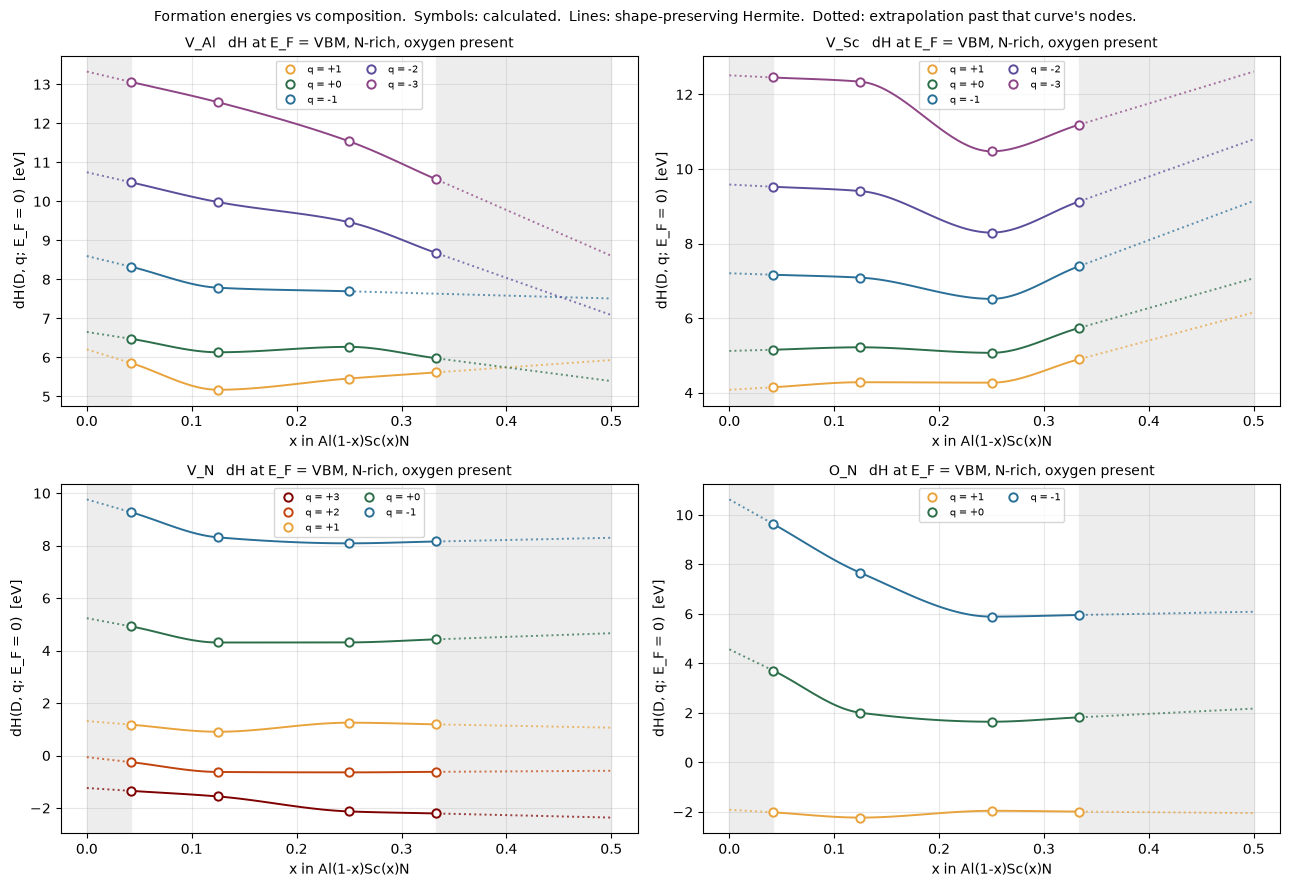

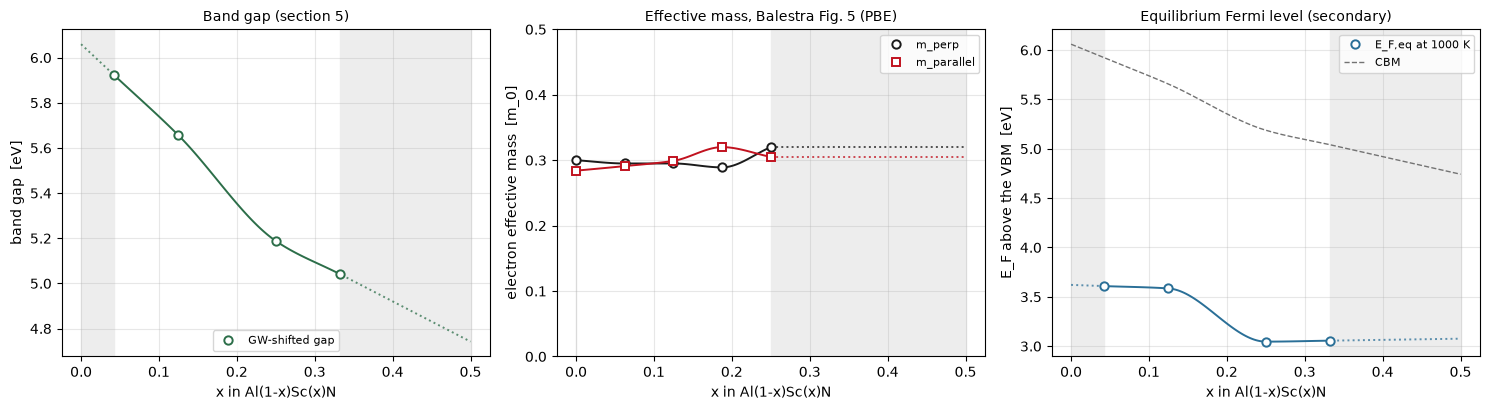

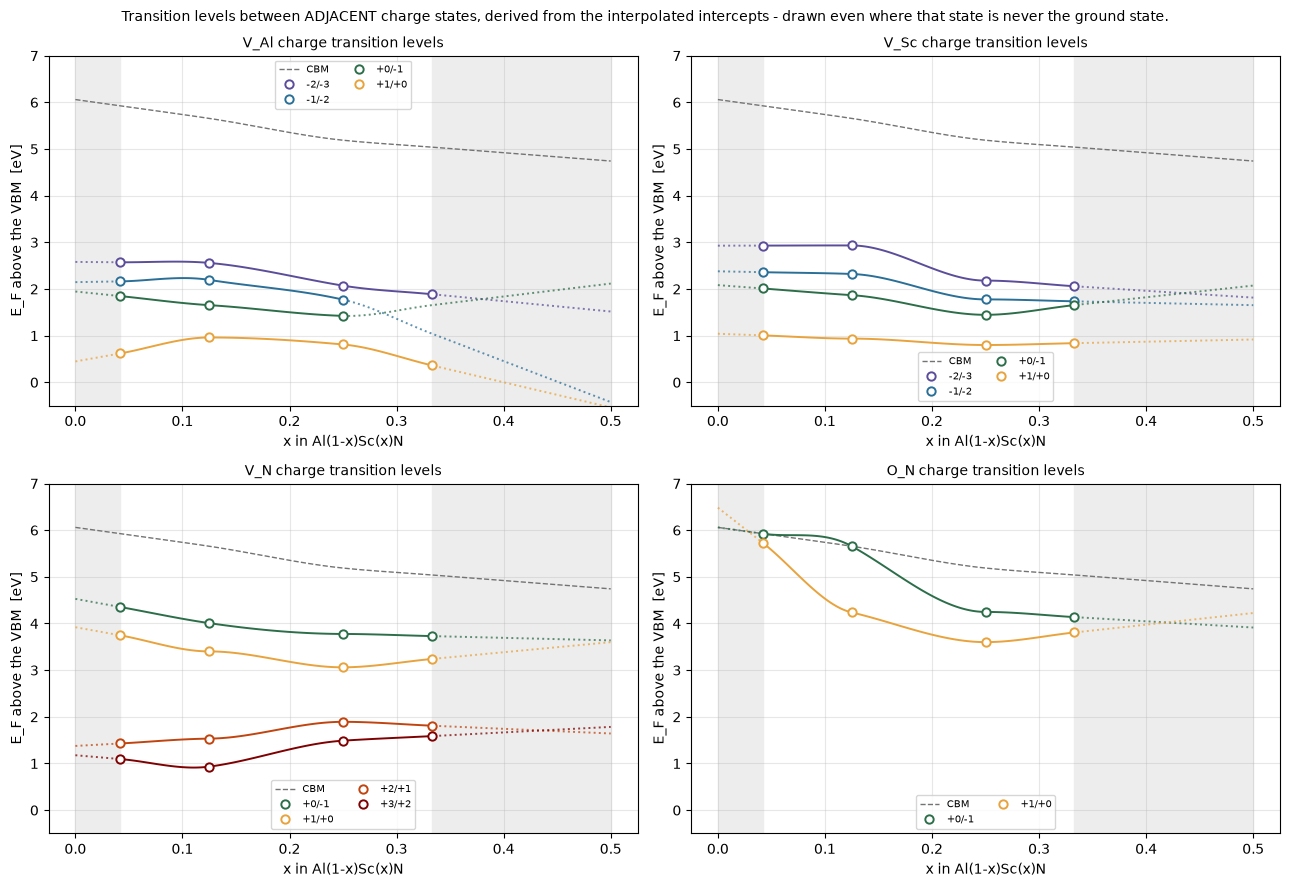

In [30]:
try:
    import matplotlib.pyplot as plt
    HAVE_MATPLOTLIB = True
except ImportError:
    HAVE_MATPLOTLIB = False
    print("matplotlib not installed -- skipping the interpolant plots.")

if HAVE_MATPLOTLIB:
    PLOT_GRID = [i / 400.0 for i in range(0, 201)]   # 0 to 0.50; wurtzite ends near here
    CHARGE_COLOURS = {3: "#7f0000", 2: "#c1440e", 1: "#e8a33d", 0: "#2c6e49",
                      -1: "#2a6f97", -2: "#5c4d9a", -3: "#8e4585"}

    def draw_series(axis, interpolant, colour, label, marker):
        """Solid where it interpolates, dotted where it extrapolates, symbols at nodes."""
        low, high = interpolant.grid[0], interpolant.grid[-1]
        inside = [x for x in PLOT_GRID if low <= x <= high]
        axis.plot(inside, [interpolant(x) for x in inside], "-",
                  color=colour, linewidth=1.4, zorder=2)
        for tail in ([x for x in PLOT_GRID if x <= low],
                     [x for x in PLOT_GRID if x >= high]):
            if len(tail) > 1:
                axis.plot(tail, [interpolant(x) for x in tail], ":",
                          color=colour, linewidth=1.4, alpha=0.75, zorder=2)
        axis.plot(interpolant.grid, interpolant.values, marker, color=colour, markersize=6,
                  markerfacecolor="white", markeredgewidth=1.4, linestyle="none",
                  label=label, zorder=3)

    def shade_extrapolation(axis, interpolant):
        """Grey the regions where the curve is a linear continuation rather than interpolation."""
        low, high = min(PLOT_GRID), max(PLOT_GRID)
        axis.axvspan(low, interpolant.grid[0], color="0.93", zorder=0)
        axis.axvspan(interpolant.grid[-1], high, color="0.93", zorder=0)

    # --- formation energies, one panel per defect --------------------------------------
    figure, axes = plt.subplots(2, 2, figsize=(13, 9))
    for axis, defect in zip(axes.flat, DEFECTS):
        charges = sorted((charge for name, charge in FORMATION_ENERGY_INTERPOLANT
                          if name == defect), reverse=True)
        shade_extrapolation(axis, FORMATION_ENERGY_INTERPOLANT[(defect, charges[0])])
        for charge in charges:
            draw_series(axis, FORMATION_ENERGY_INTERPOLANT[(defect, charge)],
                        CHARGE_COLOURS.get(charge, "0.3"), f"q = {charge:+d}", "o")
        axis.set_title(f"{defect}   dH at E_F = VBM, {REFERENCE_CONDITION}", fontsize=10)
        axis.set_xlabel("x in Al(1-x)Sc(x)N")
        axis.set_ylabel("dH(D, q; E_F = 0)  [eV]")
        axis.grid(alpha=0.3)
        axis.legend(fontsize=7, ncol=2)
    figure.suptitle("Formation energies vs composition.  Symbols: calculated.  Lines: "
                    "shape-preserving Hermite.  Dotted: extrapolation past that curve's nodes.", fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- band gap, masses, equilibrium Fermi level ------------------------------------
    figure, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    shade_extrapolation(axes[0], BAND_GAP_INTERPOLANT)
    draw_series(axes[0], BAND_GAP_INTERPOLANT, "#2c6e49", "GW-shifted gap", "o")
    axes[0].set_ylabel("band gap  [eV]")
    axes[0].set_title("Band gap (section 5)", fontsize=10)

    shade_extrapolation(axes[1], MASS_PERPENDICULAR_INTERPOLANT)
    draw_series(axes[1], MASS_PERPENDICULAR_INTERPOLANT, "#1b1b1b", "m_perp", "o")
    draw_series(axes[1], MASS_PARALLEL_INTERPOLANT, "#c1121f", "m_parallel", "s")
    axes[1].set_ylabel("electron effective mass  [m_0]")
    axes[1].set_ylim(0.0, 0.5)      # full scale: the whole variation is a 12 % band
    axes[1].set_title("Effective mass, Balestra Fig. 5 (PBE)", fontsize=10)

    shade_extrapolation(axes[2], EQUILIBRIUM_FERMI_INTERPOLANT)
    draw_series(axes[2], EQUILIBRIUM_FERMI_INTERPOLANT, "#2a6f97", "E_F,eq at 1000 K", "o")
    axes[2].plot(PLOT_GRID, [BAND_GAP_INTERPOLANT(x) for x in PLOT_GRID], "--",
                 color="0.45", linewidth=1.0, label="CBM")
    axes[2].set_ylabel("E_F above the VBM  [eV]")
    axes[2].set_title("Equilibrium Fermi level (secondary)", fontsize=10)
    for axis in axes:
        axis.set_xlabel("x in Al(1-x)Sc(x)N")
        axis.grid(alpha=0.3)
        axis.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # --- charge transition levels, one panel per defect --------------------------------
    figure, axes = plt.subplots(2, 2, figsize=(13, 9))
    for axis, defect in zip(axes.flat, DEFECTS):
        pairs = adjacent_charge_pairs(defect)
        reference = FORMATION_ENERGY_INTERPOLANT[(defect, pairs[0][0])]
        shade_extrapolation(axis, reference)
        axis.plot(PLOT_GRID, [BAND_GAP_INTERPOLANT(x) for x in PLOT_GRID], "--",
                  color="0.45", linewidth=1.0, label="CBM")
        for high, low in pairs:
            colour = CHARGE_COLOURS.get(high, "0.3")
            nodes = sorted(set(FORMATION_ENERGY_INTERPOLANT[(defect, high)].grid)
                           & set(FORMATION_ENERGY_INTERPOLANT[(defect, low)].grid))
            span = [x for x in PLOT_GRID if nodes[0] <= x <= nodes[-1]]
            axis.plot(span, [charge_transition_level(defect, high, low, x) for x in span],
                      "-", color=colour, linewidth=1.4, zorder=2)
            for tail in ([x for x in PLOT_GRID if x <= nodes[0]],
                         [x for x in PLOT_GRID if x >= nodes[-1]]):
                if len(tail) > 1:
                    axis.plot(tail,
                              [charge_transition_level(defect, high, low, x) for x in tail],
                              ":", color=colour, linewidth=1.4, alpha=0.75, zorder=2)
            axis.plot(nodes, [charge_transition_level(defect, high, low, x) for x in nodes],
                      "o", color=colour, markersize=6, markerfacecolor="white",
                      markeredgewidth=1.4, linestyle="none", label=f"{high:+d}/{low:+d}",
                      zorder=3)
        axis.set_title(f"{defect} charge transition levels", fontsize=10)
        axis.set_xlabel("x in Al(1-x)Sc(x)N")
        axis.set_ylabel("E_F above the VBM  [eV]")
        axis.set_ylim(-0.5, 7.0)
        axis.grid(alpha=0.3)
        axis.legend(fontsize=7, ncol=2)
    figure.suptitle("Transition levels between ADJACENT charge states, derived from the "
                    "interpolated intercepts - drawn even where that state is never the "
                    "ground state.", fontsize=10)
    plt.tight_layout()
    plt.show()


## 15. Plots (optional - needs matplotlib)  ·  PRESENTATION


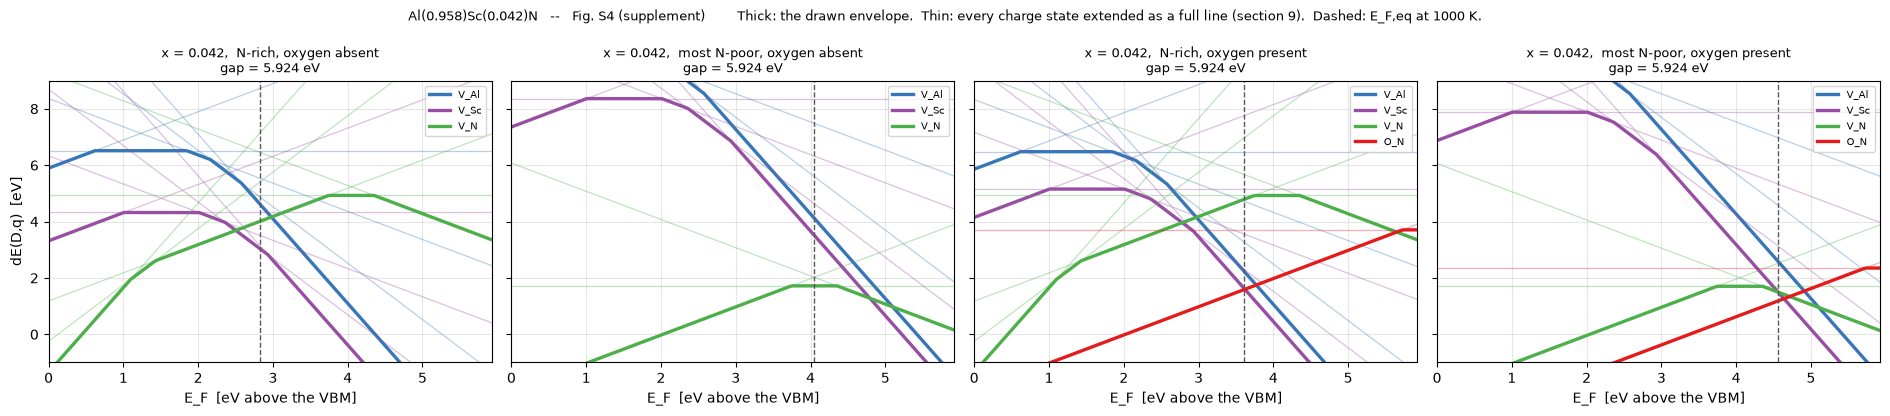

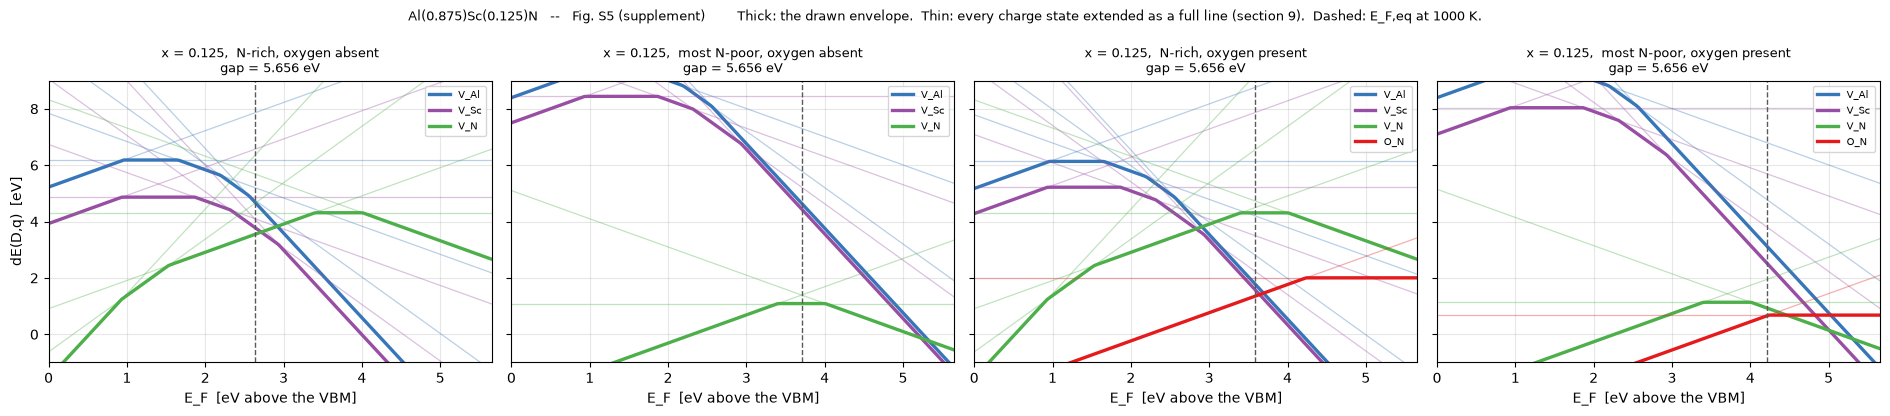

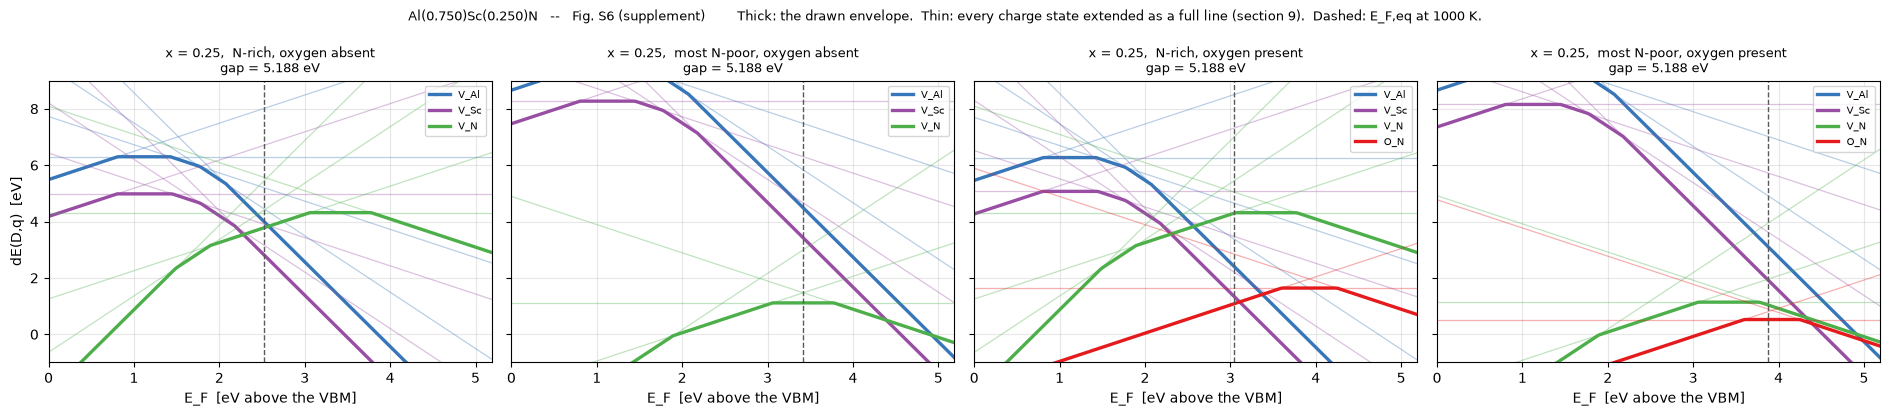

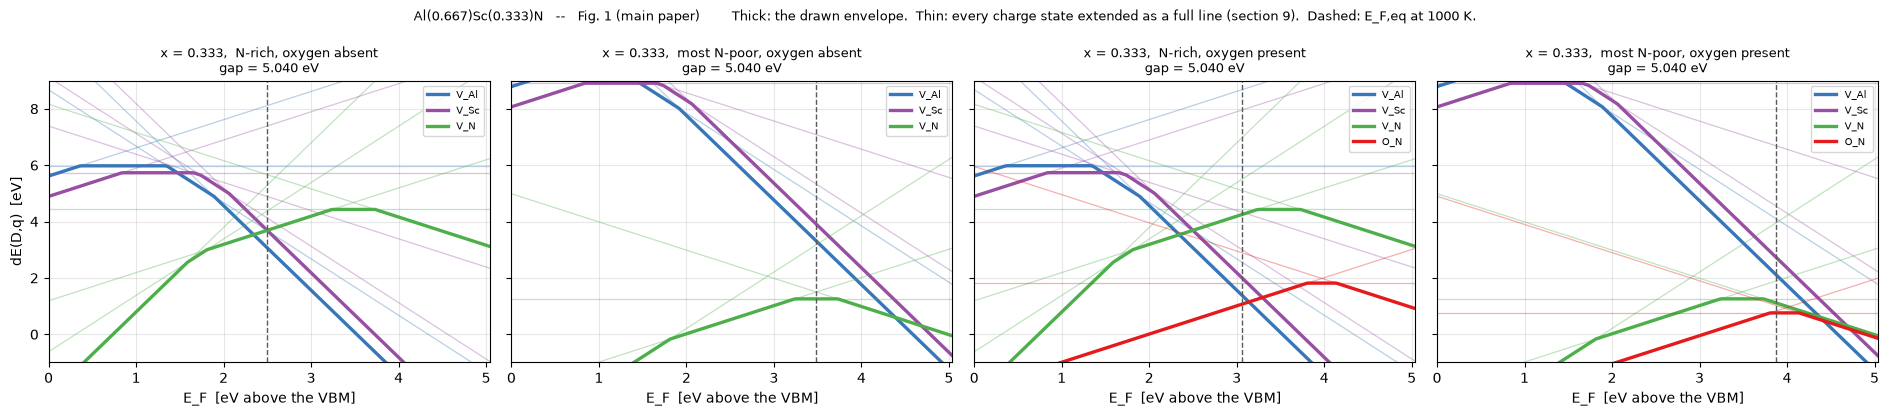

In [31]:
# ===== PRESENTATION =====
try:
    import matplotlib.pyplot as plt
    HAVE_MATPLOTLIB = True
except ImportError:
    HAVE_MATPLOTLIB = False
    print("matplotlib not installed -- skipping plots. "
          "The numerical results above are unaffected.")

DEFECT_COLOURS = {"V_Al": "#3776b8", "V_Sc": "#984ea3", "V_N": "#4daf4a", "O_N": "#e41a1c"}

PANEL_CONDITIONS = ("N-rich, oxygen absent", "most N-poor, oxygen absent",
                    "N-rich, oxygen present", "most N-poor, oxygen present")

SOURCE_FIGURE = {0.333: "Fig. 1 (main paper)", 0.042: "Fig. S4 (supplement)",
                 0.125: "Fig. S5 (supplement)", 0.250: "Fig. S6 (supplement)"}


def plot_formation_energy_panels(composition, axis_row=None):
    """One row of four panels (a)-(d) for a single composition, as laid out in the papers."""
    gap = BAND_GAP[composition]
    created = axis_row is None
    if created:
        _, axis_row = plt.subplots(1, 4, figsize=(19, 4.2), sharey=True)
    for axis, condition in zip(axis_row, PANEL_CONDITIONS):
        panel = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM.get((composition, condition))
        if panel is None:
            axis.set_visible(False)
            continue
        for defect in DEFECTS:
            if defect not in panel:
                continue
            fermi_energies, lines = charge_state_lines(composition, condition, defect)
            for charge, values in sorted(lines.items(), reverse=True):
                axis.plot(fermi_energies, values, color=DEFECT_COLOURS[defect],
                          alpha=0.35, linewidth=0.9)
            envelope = [lower_envelope_energy(panel[defect], value) for value in fermi_energies]
            axis.plot(fermi_energies, envelope, color=DEFECT_COLOURS[defect],
                      linewidth=2.4, label=defect)
        marker = EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN.get((composition, condition))
        if marker is not None:
            axis.axvline(marker, color="0.35", linestyle="--", linewidth=1.0)
        axis.set_xlim(0, gap)
        axis.set_ylim(-1, 9)
        axis.set_xlabel("E_F  [eV above the VBM]")
        axis.set_title(f"x = {composition},  {condition}\ngap = {gap:.3f} eV", fontsize=9)
        axis.grid(alpha=0.3)
        axis.legend(fontsize=7.5, loc="upper right")
    axis_row[0].set_ylabel("dE(D,q)  [eV]")
    return axis_row


if HAVE_MATPLOTLIB:
    # One figure per composition, mirroring the papers' own layout: each source figure
    # carries the four (a)-(d) chemical-potential panels for a single composition.
    for composition in sorted(BAND_GAP):
        figure, axis_row = plt.subplots(1, 4, figsize=(19, 4.2), sharey=True)
        plot_formation_energy_panels(composition, axis_row)
        figure.suptitle(
            f"Al({1-composition:.3f})Sc({composition:.3f})N   --   {SOURCE_FIGURE[composition]}"
            "        Thick: the drawn envelope.  Thin: every charge state extended as a full "
            "line (section 9).  Dashed: E_F,eq at 1000 K.", fontsize=9)
        plt.tight_layout()
        plt.show()

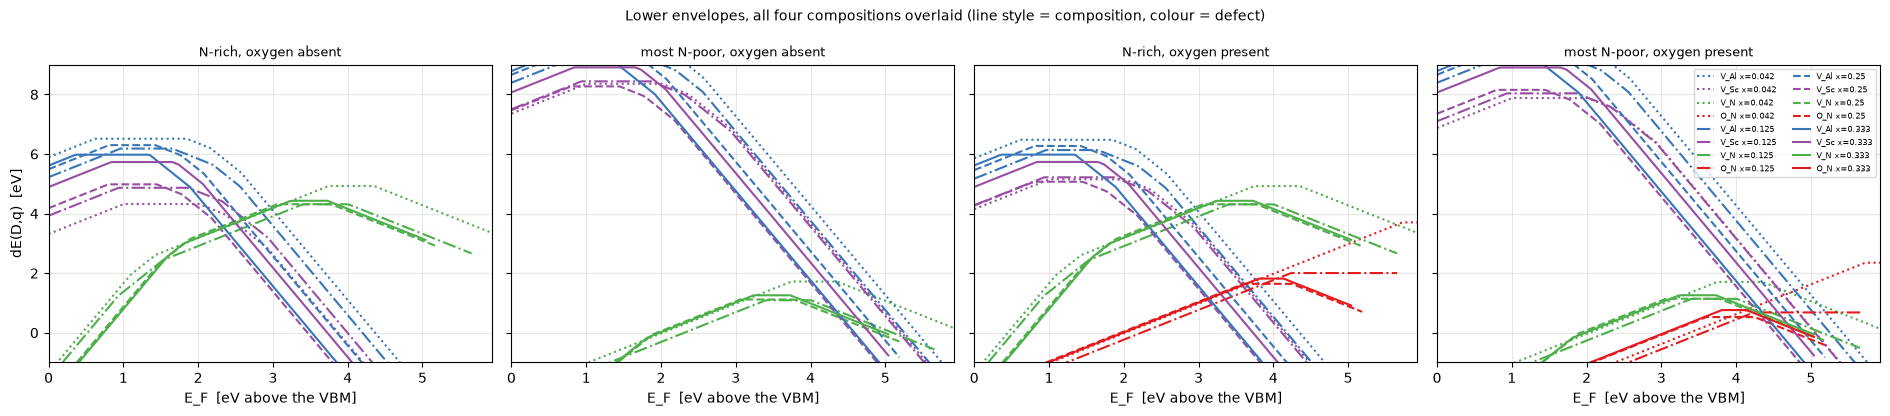

In [32]:
if HAVE_MATPLOTLIB:
    # Compact overview: the lower envelopes for every composition on one axis per condition,
    # so the composition trend is visible directly.
    figure, axes = plt.subplots(1, 4, figsize=(19, 4.2), sharey=True)
    composition_styles = {0.042: ":", 0.125: "-.", 0.250: "--", 0.333: "-"}
    for axis, condition in zip(axes, PANEL_CONDITIONS):
        for composition in sorted(BAND_GAP):
            panel = FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM.get((composition, condition))
            if panel is None:
                continue
            for defect in DEFECTS:
                if defect not in panel:
                    continue
                fermi_energies, _ = charge_state_lines(composition, condition, defect)
                envelope = [lower_envelope_energy(panel[defect], value)
                            for value in fermi_energies]
                axis.plot(fermi_energies, envelope, composition_styles[composition],
                          color=DEFECT_COLOURS[defect], linewidth=1.5,
                          label=f"{defect} x={composition}")
        axis.set_xlim(0, max(BAND_GAP.values()))
        axis.set_ylim(-1, 9)
        axis.set_xlabel("E_F  [eV above the VBM]")
        axis.set_title(condition, fontsize=9)
        axis.grid(alpha=0.3)
    axes[0].set_ylabel("dE(D,q)  [eV]")
    axes[-1].legend(fontsize=6, ncol=2, loc="upper right")
    figure.suptitle("Lower envelopes, all four compositions overlaid "
                    "(line style = composition, colour = defect)", fontsize=10)
    plt.tight_layout()
    plt.show()

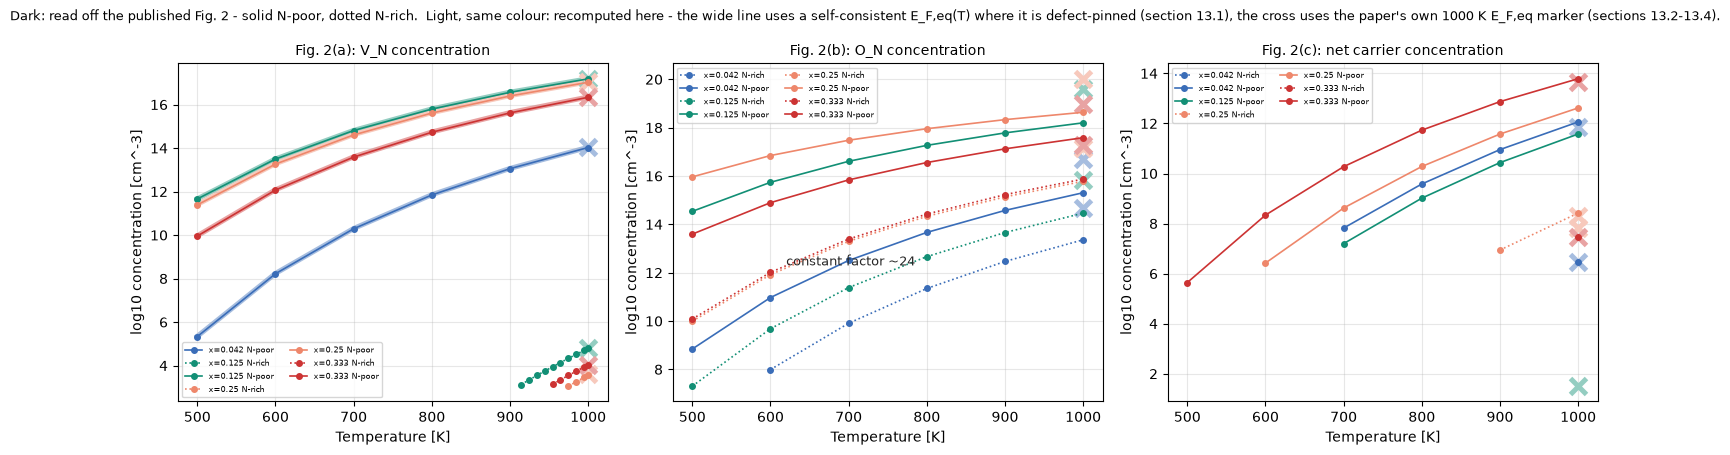

In [33]:
if HAVE_MATPLOTLIB:
    PUBLISHED_LINEWIDTH = 1.2
    BACKGROUND_WIDTH_FACTOR = 3.0

    def lighten_colour(hex_colour, amount=0.55):
        """
        Blend a #rrggbb colour towards white. amount=0 leaves it alone, amount=1 is white.
        """
        channels = (int(hex_colour[index:index + 2], 16) / 255.0 for index in (1, 3, 5))
        return tuple(channel + (1.0 - channel) * amount for channel in channels)

    figure, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    composition_colours = {0.042: "#3a6db8", 0.125: "#128f75",
                           0.25: "#ee876b", 0.333: "#cc3333"}
    panels = [(FIGURE_2_NITROGEN_VACANCY, "V_N", "Fig. 2(a): V_N concentration"),
              (FIGURE_2_OXYGEN_ON_NITROGEN, "O_N", "Fig. 2(b): O_N concentration"),
              (FIGURE_2_NET_CARRIER, "net", "Fig. 2(c): net carrier concentration")]
    for axis, (table, quantity, title) in zip(axes, panels):
        for (composition, condition), plotted in sorted(table.items()):
            dense = (FIGURE_2_NITROGEN_VACANCY_HIGH_TEMPERATURE.get((composition, condition))
                     if quantity == "V_N" else None)
            if dense:
                temperatures = [point[0] for point in dense]
                values = [point[1] for point in dense]
            else:
                if all(value is None for value in plotted):
                    continue
                temperatures = [t for t, v in zip(FIGURE_2_TEMPERATURES, plotted)
                                if v is not None]
                values = [v for v in plotted if v is not None]
            dark = composition_colours[composition]
            light = lighten_colour(dark)
            is_nitrogen_poor = condition.startswith("most")

            # Background, three times as wide and in the light tint, so that where it coincides
            # with the published curve drawn on top both remain visible: our own recomputation
            # with a self-consistent E_F,eq(T), only where E_F is defect-pinned (section 13.1).
            if quantity == "V_N" and is_nitrogen_poor:
                recomputed = [math.log10(concentration_at(
                    composition, condition, quantity,
                    solve_equilibrium_fermi_energy(composition, condition, temperature),
                    temperature)) for temperature in temperatures]
                axis.plot(temperatures, recomputed, "-", color=light,
                          linewidth=PUBLISHED_LINEWIDTH * BACKGROUND_WIDTH_FACTOR, zorder=1)

            # Cross, same light tint: recomputed at the paper's own 1000 K E_F,eq marker.
            fermi_energy = EQUILIBRIUM_FERMI_ENERGY_AT_1000_KELVIN[(composition, condition)]
            axis.plot([REFERENCE_TEMPERATURE_KELVIN],
                      [math.log10(concentration_at(composition, condition, quantity,
                                                   fermi_energy,
                                                   REFERENCE_TEMPERATURE_KELVIN))],
                      "x", color=light, markersize=11,
                      markeredgewidth=PUBLISHED_LINEWIDTH * BACKGROUND_WIDTH_FACTOR, zorder=2)

            # Foreground: the curve read off the published figure.
            axis.plot(temperatures, values, "-" if is_nitrogen_poor else ":", color=dark,
                      marker="o", markersize=4, linewidth=PUBLISHED_LINEWIDTH, zorder=3,
                      label=f"x={composition} {'N-poor' if is_nitrogen_poor else 'N-rich'}")
        axis.set_xlabel("Temperature [K]")
        axis.set_ylabel("log10 concentration [cm^-3]")
        axis.set_title(title, fontsize=10)
        axis.grid(alpha=0.3)
        axis.legend(fontsize=6, ncol=2)
    axes[1].annotate("constant factor ~24", xy=(620, 12.3), fontsize=9, color="0.15")
    figure.suptitle(
        "Dark: read off the published Fig. 2 - solid N-poor, dotted N-rich.  Light, same "
        "colour: recomputed here - the wide line uses a self-consistent E_F,eq(T) where it is "
        "defect-pinned (section 13.1), the cross uses the paper's own 1000 K E_F,eq marker "
        "(sections 13.2-13.4).", fontsize=9)
    plt.tight_layout()
    plt.show()


### 15a. Alloy free energy and the tieline  ·  PRESENTATION

G_f(alloy, x) from section 8b, the four points it interpolates, and the AlN-ScN tieline. The right panel magnifies the difference, because that difference divided by x is exactly how far apart the AlN-facing and ScN-facing closures put Delta mu_Sc.

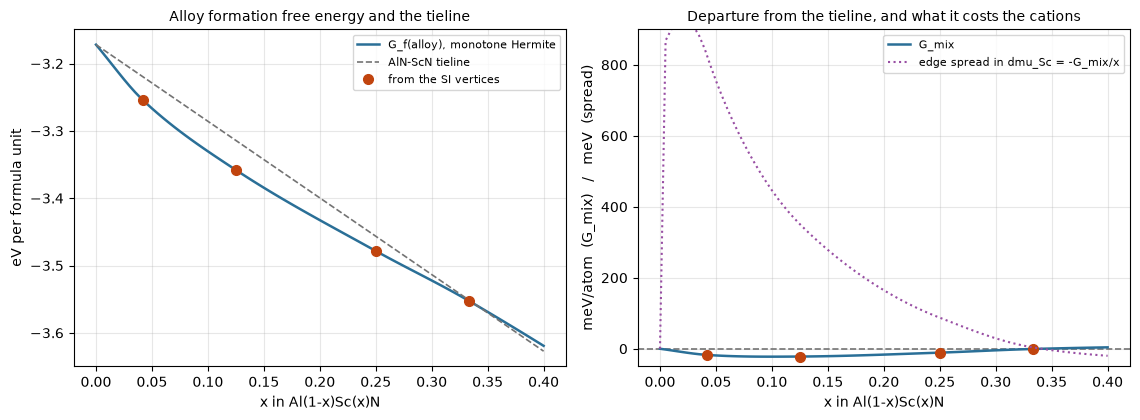

G_mix < 0 at every x, so the alloy sits below the tieline on Lee's 3000 K free-energy
hull. Adding back T_eff*S_ideal makes the ENTHALPY of mixing positive everywhere
(+5 to +82 meV/atom), which is what Fig. S1 plots and what agrees with Hirata.


In [34]:
# ===== PRESENTATION =====
if HAVE_MATPLOTLIB:
    _grid = [0.005 * i for i in range(81)]
    _figure, _axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

    _axes[0].plot(_grid, [ALLOY_FREE_ENERGY_INTERPOLANT(x) for x in _grid], "-",
                  color="#2a6f97", linewidth=1.8, label="G_f(alloy), monotone Hermite")
    _axes[0].plot(_grid, [(1 - x) * BINARY_FORMATION_ENTHALPY["AlN"]
                          + x * BINARY_FORMATION_ENTHALPY["ScN"] for x in _grid], "--",
                  color="0.45", linewidth=1.2, label="AlN-ScN tieline")
    _axes[0].plot(COMPOSITIONS, [ALLOY_FORMATION_FREE_ENERGY[c] for c in COMPOSITIONS], "o",
                  color="#c1440e", markersize=7, label="from the SI vertices")
    _axes[0].set_xlabel("x in Al(1-x)Sc(x)N")
    _axes[0].set_ylabel("eV per formula unit")
    _axes[0].set_title("Alloy formation free energy and the tieline", fontsize=10)
    _axes[0].legend(fontsize=8)

    # The distance from the tieline is what the closures disagree about, so show it magnified.
    _axes[1].axhline(0.0, linestyle="--", color="0.45", linewidth=1.2)
    _axes[1].plot(_grid, [(ALLOY_FREE_ENERGY_INTERPOLANT(x)
                           - ((1 - x) * BINARY_FORMATION_ENTHALPY["AlN"]
                              + x * BINARY_FORMATION_ENTHALPY["ScN"])) * 500 for x in _grid],
                  "-", color="#2a6f97", linewidth=1.8, label="G_mix")
    _axes[1].plot(COMPOSITIONS,
                  [(ALLOY_FORMATION_FREE_ENERGY[c]
                    - ((1 - c) * BINARY_FORMATION_ENTHALPY["AlN"]
                       + c * BINARY_FORMATION_ENTHALPY["ScN"])) * 500 for c in COMPOSITIONS],
                  "o", color="#c1440e", markersize=7)
    _axes[1].plot(_grid, [-(ALLOY_FREE_ENERGY_INTERPOLANT(x)
                            - ((1 - x) * BINARY_FORMATION_ENTHALPY["AlN"]
                               + x * BINARY_FORMATION_ENTHALPY["ScN"])) / max(x, 1e-3) * 1000
                          for x in _grid], ":", color="#984ea3", linewidth=1.5,
                  label="edge spread in dmu_Sc = -G_mix/x")
    _axes[1].set_xlabel("x in Al(1-x)Sc(x)N")
    _axes[1].set_ylabel("meV/atom  (G_mix)   /   meV  (spread)")
    _axes[1].set_title("Departure from the tieline, and what it costs the cations", fontsize=10)
    _axes[1].legend(fontsize=8)
    _axes[1].set_ylim(-50, 900)

    for _axis in _axes:
        _axis.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("G_mix < 0 at every x, so the alloy sits below the tieline on Lee's 3000 K free-energy")
    print("hull. Adding back T_eff*S_ideal makes the ENTHALPY of mixing positive everywhere")
    print("(+5 to +82 meV/atom), which is what Fig. S1 plots and what agrees with Hirata.")


## 16. Forward look - what this machinery does NOT capture  ·  NARRATIVE

*This section states a limitation and leaves a hook. No model is developed here.*

Everything above is **bulk equilibrium**. It answers "what defect population would Al(1-x)Sc(x)N carry
if it were held at temperature T until it stopped changing, in contact with reservoirs at the
tabulated chemical potentials". That is the right question for the paper's purpose and the wrong
question for a **sputtered film**, for three reasons that compound.

**1. The equilibrium answer is too small to matter.** Section 13 reproduces the paper: even at the
most N-poor chemical potential that does not decompose the nitride, `[V_N]` at 1000 K is ~1e16-1e17
cm^-3, and at a realistic 400 C growth temperature it is far lower still. Reported V_N levels in
sputtered AlScN are orders of magnitude above that. Whatever sputtered films carry, **it is not
equilibrium V_N at any accessible mu_N**.

**2. Bulk V_N cannot move at growth temperature, so nothing equilibrates after burial.** The
climbing-image NEB migration barrier for V_N in Al(1-x)Sc(x)N is **2.46 eV at -4 % strain to 2.71 eV
at +4 %** (*ACS Appl. Mater. Interfaces* **16** (2024), doi:10.1021/acsami.4c03442). With an attempt
frequency of 1e13 s^-1 that is under **one hop per vacancy over an entire ten-minute deposition** at
every usable growth temperature - roughly 2e-3 hops at 400 C, 4e-2 at 450 C. There is no bulk
equilibration and no freeze-out *depth* in the diffusion sense: the configuration present at the
instant of burial is the configuration that survives, permanently.

**3. The relevant formation energy is therefore the sub-surface one, not the bulk one.** With a
residence time per monolayer of ~0.75 s at 20 nm/min, the top one to two monolayers do locally
equilibrate if the surface barrier is <~1.5 eV, while everything below is frozen absolutely; the
transition is only ~1-2 monolayers wide because the rate is exponential in the barrier. So the
quantity a growth model needs is `dH(V_N)` **as a function of depth below the growth front**, at the
freeze-out plane, for both Al-polar and N-polar (0001) - a slab calculation, not the bulk supercell
calculation reproduced here.

**The hook.** The machinery in sections 9-13 is reusable as-is for that model: replace
`FORMATION_ENERGY_AT_VALENCE_BAND_MAXIMUM` with depth-resolved sub-surface values, replace the
tabulated `Delta-mu_N` with an effective `mu_N` set by the plasma, and solve the same charge
neutrality locally at the freeze-out plane and growth temperature. What must be added on top and is
absent here: an **athermal** channel for displacement damage from energetic-neutral and negative-ion
bombardment, and the strain dependence of `dH(V_N)` (formation energy falls under compression), since
N2 flow moves the nitrogen supply and the film stress state through the same knob. See
`agents/workdir/reusable/scratch_VN_kinetics_modeling.md`.


## 17. Check summary  ·  CODE


In [35]:
summarise_checks()



52/52 checks behaved as expected.
ALL AS EXPECTED (including the 5 deliberate failures of section 14).
